# GWR/MGWR: Determinan Lokal PoU di Kepulauan Maluku

Analisis determinan lokal Prevalensi Ketidakcukupan Konsumsi Pangan (PoU) di 21
kabupaten/kota Kepulauan Maluku (Provinsi Maluku + Maluku Utara), memakai GWR/MGWR,
dibandingkan dengan OLS (non-spasial) dan SAR/SEM (spasial global). Matriks pembobot
spasial (KNN k=4, centroid proyeksi Azimuthal Equidistant) dipakai konsisten di semua
tahap yang membutuhkannya.

## Tahap 0 - Setup

In [1]:
!pip install mgwr libpysal esda spreg geopandas statsmodels scikit-learn matplotlib seaborn --quiet


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import html
import shutil
import warnings
import zipfile
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

# Deteksi kernel IPython/Jupyter SEBELUM impor pyplot: kalau dijalankan sebagai skrip
# biasa (bukan di dalam notebook), backend GUI default (mis. TkAgg di Windows) bisa
# BLOK tanpa batas waktu pada plt.show(). Paksa backend headless "Agg" hanya di luar
# notebook; di dalam notebook (lokal maupun Colab) backend inline bawaan Jupyter dipakai
# apa adanya supaya figure tetap tampil inline.
_RUNNING_IN_NOTEBOOK = "get_ipython" in dir() and get_ipython() is not None
if not _RUNNING_IN_NOTEBOOK:
    import matplotlib
    matplotlib.use("Agg")

import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

# N=21 kab/kota terlalu kecil untuk mendapat manfaat dari paralelisme proses (loky);
# thread backend menghindari overhead spawn/teardown proses berulang yang terbukti
# menyebabkan macet pada Windows setelah banyak fit GWR/MGWR berurutan dalam satu proses.
joblib.parallel_config(backend="threading")

RNG_SEED = 42
np.random.seed(RNG_SEED)

# --- Path setup (bekerja baik di Google Colab maupun lokal) ---
IN_COLAB = "google.colab" in str(get_ipython()) if _RUNNING_IN_NOTEBOOK else False

BASE_DIR = Path(".").resolve()
DATA_DIR = BASE_DIR / "Data"
FIG_DIR = BASE_DIR / "figures"
TAB_DIR = BASE_DIR / "tables"
PKG_DIR = BASE_DIR / "gemastik_hasil_gwr_mgwr"

for d in [DATA_DIR, FIG_DIR, TAB_DIR, PKG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PATH_PANEL = DATA_DIR / "FINAL_KepulauanMaluku_PoU_X1-X24_2020-2025.csv"
PATH_TEXT = DATA_DIR / "dataset_final_dengan_topik_sentimen.csv"
PATH_GEOJSON = DATA_DIR / "batas_21_kabkota_kepulauan_maluku.geojson"

LOG_LINES = []


def log(msg: str):
    """Cetak ke stdout sekaligus simpan ke buffer log untuk ringkasan akhir."""
    print(msg)
    LOG_LINES.append(str(msg))


log(f"BASE_DIR = {BASE_DIR}")
log(f"IN_COLAB = {IN_COLAB}")

BASE_DIR = D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW
IN_COLAB = False


### Fallback: unduh ulang GeoJSON batas 21 kab/kota jika belum ada

Sumber: `JfrAziz/indonesia-district` (data desa/kelurahan HDX-BPS-2020), didisolusi
ke level kabupaten/kota. Dipilih karena mencakup poligon utuh untuk seluruh 21
kab/kota di Kepulauan Maluku, termasuk Pulau Taliabu (yang pada analisis sebelumnya
tidak memiliki poligon dan ditangani sebagai titik penanda). Jika suatu saat geometry
sebuah kab/kota kosong, kode di bawah tetap punya jalur fallback titik penanda agar
konsisten dengan pendekatan peta sebelumnya.

In [3]:
RENAME_REGENCY_TO_CSV = {
    "Maluku Tenggara Barat": "Kepulauan Tanimbar (Maluku Tenggara Barat)",
}

GEOJSON_SOURCES = {
    "Maluku": "https://raw.githubusercontent.com/JfrAziz/indonesia-district/master/id81_maluku/id81_maluku_district.geojson",
    "Maluku Utara": "https://raw.githubusercontent.com/JfrAziz/indonesia-district/master/id82_maluku_utara/id82_maluku_utara_district.geojson",
}


def build_geojson_from_source():
    log("GeoJSON lokal tidak ditemukan / dibangun ulang dari sumber HDX-BPS-2020 (level desa -> didisolusi ke kab/kota).")
    frames = []
    for prov, url in GEOJSON_SOURCES.items():
        gdf = gpd.read_file(url)
        frames.append(gdf)
    gdf_all = pd.concat(frames, ignore_index=True)
    gdf_all = gpd.GeoDataFrame(gdf_all, geometry="geometry", crs="EPSG:4326")
    gdf_all["geometry"] = gdf_all.geometry.buffer(0)  # perbaiki geometri tidak valid

    dissolved = gdf_all.dissolve(by=["province", "regency", "regency_code"], as_index=False)
    dissolved = dissolved[["province", "regency", "regency_code", "geometry"]]
    dissolved["kab_kota"] = dissolved["regency"].replace(RENAME_REGENCY_TO_CSV)
    dissolved["provinsi"] = dissolved["province"]
    dissolved["geometry"] = dissolved.geometry.simplify(0.0015, preserve_topology=True)

    final = dissolved[["kab_kota", "provinsi", "regency_code", "geometry"]].copy()
    final = final.sort_values("kab_kota").reset_index(drop=True)
    return final


if PATH_GEOJSON.exists():
    gdf_batas = gpd.read_file(PATH_GEOJSON)
    log(f"GeoJSON dimuat dari file lokal: {PATH_GEOJSON} ({len(gdf_batas)} fitur)")
else:
    gdf_batas = build_geojson_from_source()
    gdf_batas.to_file(PATH_GEOJSON, driver="GeoJSON")
    log(f"GeoJSON baru disimpan ke: {PATH_GEOJSON} ({len(gdf_batas)} fitur)")

assert len(gdf_batas) == 21, f"Diharapkan 21 kab/kota, ditemukan {len(gdf_batas)}"
N_TALIABU_MISSING_GEOM = gdf_batas.geometry.isna().sum() + (gdf_batas.geometry.is_empty).sum()
log(f"Jumlah kab/kota tanpa geometri valid (akan pakai fallback titik penanda): {N_TALIABU_MISSING_GEOM}")

GeoJSON dimuat dari file lokal: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\Data\batas_21_kabkota_kepulauan_maluku.geojson (21 fitur)
Jumlah kab/kota tanpa geometri valid (akan pakai fallback titik penanda): 0


## Tahap 1a - Bangun X27_Volume_Wacana_Digital

In [4]:
ALIAS_KABKOTA = {
    "Kepulauan Tanimbar (Maluku Tenggara Barat)": ["tanimbar", "saumlaki"],
    "Maluku Tenggara": ["maluku tenggara", "langgur"],
    "Maluku Tengah": ["maluku tengah", "masohi"],
    "Buru Selatan": ["buru selatan", "namrole"],
    "Buru": ["kabupaten buru", "pulau buru", "namlea"],
    "Kepulauan Aru": ["kepulauan aru", "dobo"],
    "Seram Bagian Barat": ["seram bagian barat", "piru", "kairatu"],
    "Seram Bagian Timur": ["seram bagian timur", "bula"],
    "Maluku Barat Daya": ["maluku barat daya", "tiakur"],
    "Kota Ambon": ["ambon"],
    "Kota Tual": ["tual"],
    "Halmahera Barat": ["halmahera barat", "jailolo"],
    "Halmahera Tengah": ["halmahera tengah", "weda"],
    "Kepulauan Sula": ["kepulauan sula", "sanana"],
    "Halmahera Selatan": ["halmahera selatan", "labuha"],
    "Halmahera Utara": ["halmahera utara", "tobelo"],
    "Halmahera Timur": ["halmahera timur", "maba"],
    "Pulau Morotai": ["morotai", "daruba"],
    "Pulau Taliabu": ["taliabu", "bobong"],
    "Kota Ternate": ["ternate"],
    "Kota Tidore Kepulauan": ["tidore", "soasio"],
}
assert len(ALIAS_KABKOTA) == 21
assert set(ALIAS_KABKOTA.keys()) == set(gdf_batas["kab_kota"])

# Guard untuk alias yang secara literal menjadi substring dari alias kab/kota lain
# (mis. "kabupaten buru" adalah prefix literal dari "kabupaten buru selatan"; "maluku
# tenggara" adalah prefix literal dari "maluku tenggara barat"). Tanpa guard ini,
# dokumen yang menyebut kab/kota lebih spesifik akan ikut ter-tag ke kab/kota yang lebih
# umum sehingga salah menjadi MULTI atau salah kabupaten.
NEGATIVE_LOOKAHEAD_GUARD = {
    ("Buru", "kabupaten buru"): "selatan",
    ("Buru", "pulau buru"): "selatan",
    ("Maluku Tenggara", "maluku tenggara"): "barat",
}


def build_alias_regex(kab_kota: str, aliases: list) -> re.Pattern:
    parts = []
    for alias in aliases:
        guard = NEGATIVE_LOOKAHEAD_GUARD.get((kab_kota, alias))
        piece = r"\b" + re.escape(alias) + r"\b"
        if guard:
            piece += rf"(?!\s+{re.escape(guard)}\b)"
        parts.append(piece)
    pattern = "|".join(parts)
    return re.compile(pattern, flags=re.IGNORECASE)


ALIAS_PATTERNS = {k: build_alias_regex(k, v) for k, v in ALIAS_KABKOTA.items()}

In [5]:
df_text_raw = pd.read_csv(PATH_TEXT, encoding="utf-8-sig", low_memory=False)
log(f"Dataset teks: {df_text_raw.shape[0]} baris, {df_text_raw.shape[1]} kolom")

df_text = df_text_raw.copy()
df_text["full_text"] = df_text["full_text"].fillna("").astype(str).map(html.unescape)
df_text["created_at_parsed"] = pd.to_datetime(df_text["created_at"], errors="coerce", utc=True)
df_text["tahun_derived"] = df_text["created_at_parsed"].dt.year
df_text["tahun_derived"] = df_text["tahun_derived"].fillna(df_text["tahun"])

N_TAHUN_GAGAL_PARSE = df_text["tahun_derived"].isna().sum()
log(f"Baris gagal menentukan tahun (created_at & tahun kosong/invalid): {N_TAHUN_GAGAL_PARSE}")


def tag_kabupaten(text: str):
    matches = [kab for kab, pat in ALIAS_PATTERNS.items() if pat.search(text)]
    if len(matches) == 0:
        return "NONE"
    if len(matches) == 1:
        return matches[0]
    return "MULTI"


df_text["tag_kabkota"] = df_text["full_text"].map(tag_kabupaten)

mask_periode = df_text["tahun_derived"].between(2021, 2026)
df_text_periode = df_text[mask_periode].copy()

log(f"Dokumen dalam periode 2021-2026: {len(df_text_periode)} dari {len(df_text)} total")
log("Distribusi tag (periode 2021-2026):")
tag_counts_full = df_text_periode["tag_kabkota"].value_counts()
log(tag_counts_full.to_string())

n_multi = int((df_text_periode["tag_kabkota"] == "MULTI").sum())
n_none = int((df_text_periode["tag_kabkota"] == "NONE").sum())
log(f"Jumlah dokumen MULTI (menyebut >1 kab/kota, tidak dihitung ke manapun): {n_multi}")
log(f"Jumlah dokumen NONE (tidak menyebut kab/kota manapun): {n_none}")

Dataset teks: 2266 baris, 44 kolom
Baris gagal menentukan tahun (created_at & tahun kosong/invalid): 0


Dokumen dalam periode 2021-2026: 2266 dari 2266 total
Distribusi tag (periode 2021-2026):
tag_kabkota
NONE                                          2060
Kota Ambon                                      55
Maluku Tenggara                                 30
Kota Ternate                                    21
Maluku Tengah                                   21
MULTI                                           15
Maluku Barat Daya                               13
Kota Tidore Kepulauan                            8
Kepulauan Tanimbar (Maluku Tenggara Barat)       8
Seram Bagian Barat                               8
Kota Tual                                        6
Buru                                             6
Halmahera Timur                                  5
Halmahera Barat                                  3
Halmahera Selatan                                1
Kepulauan Aru                                    1
Halmahera Utara                                  1
Kepulauan Sula                 

In [6]:
x27_counts = (
    df_text_periode[~df_text_periode["tag_kabkota"].isin(["MULTI", "NONE"])]
    .groupby("tag_kabkota")
    .size()
    .rename("X27_Volume_Wacana_Digital")
)

tabel_x27 = pd.DataFrame({"kab_kota": list(ALIAS_KABKOTA.keys())})
tabel_x27 = tabel_x27.merge(
    x27_counts.rename_axis("kab_kota").reset_index(), on="kab_kota", how="left"
)
tabel_x27["X27_Volume_Wacana_Digital"] = tabel_x27["X27_Volume_Wacana_Digital"].fillna(0).astype(int)

multi_docs = df_text_periode[df_text_periode["tag_kabkota"] == "MULTI"].copy()


def multi_related(text: str):
    return sorted([kab for kab, pat in ALIAS_PATTERNS.items() if pat.search(text)])


multi_docs["kab_terkait"] = multi_docs["full_text"].map(multi_related)
multi_related_counts = {}
for kabs in multi_docs["kab_terkait"]:
    for k in kabs:
        multi_related_counts[k] = multi_related_counts.get(k, 0) + 1

tabel_x27["n_dokumen_MULTI_terkait"] = tabel_x27["kab_kota"].map(multi_related_counts).fillna(0).astype(int)
tabel_x27 = tabel_x27.sort_values("kab_kota").reset_index(drop=True)

log("\nTabel X27_Volume_Wacana_Digital per kab/kota:")
log(tabel_x27.to_string(index=False))

tabel_x27.to_csv(TAB_DIR / "x27_volume_wacana_per_kabkota.csv", index=False)
log(f"\nDisimpan: {TAB_DIR / 'x27_volume_wacana_per_kabkota.csv'}")

n_zero_x27 = int((tabel_x27["X27_Volume_Wacana_Digital"] == 0).sum())
log(f"Kab/kota dengan X27=0 (nilai sah, bukan data hilang): {n_zero_x27}")


Tabel X27_Volume_Wacana_Digital per kab/kota:
                                  kab_kota  X27_Volume_Wacana_Digital  n_dokumen_MULTI_terkait
                                      Buru                          6                        0
                              Buru Selatan                          1                        0
                           Halmahera Barat                          3                        0
                         Halmahera Selatan                          1                        0
                          Halmahera Tengah                          0                        0
                           Halmahera Timur                          5                        1
                           Halmahera Utara                          1                        0
                             Kepulauan Aru                          1                        1
                            Kepulauan Sula                          1                        0
Kep

## Tahap 1b - Bangun cross-section 2025

In [7]:
df_panel_raw = pd.read_csv(PATH_PANEL, encoding="utf-8-sig")
df_panel = df_panel_raw.rename(columns={c: c.split(" (")[0] for c in df_panel_raw.columns})
df_panel = df_panel.rename(
    columns={
        "X13_Jumlah_Pelabuhan_Utama": "X13a_Jumlah_Pelabuhan_Utama",
        "X13_Kunjungan_Kapal_Tahunan": "X13b_Kunjungan_Kapal_Tahunan",
        "X13_Jarak_ke_Pelabuhan_Induk": "X13c_Jarak_ke_Pelabuhan_Induk",
    }
)
df_panel = df_panel.rename(columns={"Kab/Kota": "kab_kota", "Provinsi": "provinsi", "Tahun": "tahun"})
log(f"Panel dimuat: {df_panel.shape[0]} baris x {df_panel.shape[1]} kolom, {df_panel['kab_kota'].nunique()} kab/kota, tahun {sorted(df_panel['tahun'].unique())}")

KAB_LIST = sorted(df_panel["kab_kota"].unique())
assert set(KAB_LIST) == set(ALIAS_KABKOTA.keys())

df_panel = df_panel.sort_values(["kab_kota", "tahun"]).reset_index(drop=True)


def direct_2025_with_carry_forward(col: str) -> pd.DataFrame:
    """Ambil nilai 2025 langsung; kalau kosong, carry-forward dari tahun terakhir
    yang tersedia UNTUK KABUPATEN YANG SAMA (bukan lintas kabupaten)."""
    rows = []
    for kab, g in df_panel.groupby("kab_kota"):
        g = g.sort_values("tahun")
        val_2025 = g.loc[g["tahun"] == 2025, col]
        val_2025 = val_2025.iloc[0] if len(val_2025) else np.nan
        carried = False
        source_year = 2025
        if pd.isna(val_2025):
            hist = g[g["tahun"] < 2025].dropna(subset=[col]).sort_values("tahun")
            if len(hist):
                val_2025 = hist.iloc[-1][col]
                source_year = int(hist.iloc[-1]["tahun"])
                carried = True
        rows.append({"kab_kota": kab, col: val_2025, f"{col}_carried_forward": carried, f"{col}_source_year": source_year})
    return pd.DataFrame(rows)


DIRECT_2025_COLS = [
    "Y_PoU",
    "X5_Persentase_Penduduk_Miskin",
    "X8_PDRB_per_Kapita_ADHB",
    "X9_Pangsa_Pengeluaran_Pangan",
    "X10_Rata_Rata_Pengeluaran_Pangan",
    "X12_Kepadatan_Penduduk",
    "X13a_Jumlah_Pelabuhan_Utama",
    "X13b_Kunjungan_Kapal_Tahunan",
    "X13c_Jarak_ke_Pelabuhan_Induk",
    "X17_TPT",
    "X20_RT_Akses_Sanitasi_Layak",
    "X23_IPM",
]

cross = pd.DataFrame({"kab_kota": KAB_LIST})
carry_forward_summary = {}
for col in DIRECT_2025_COLS:
    part = direct_2025_with_carry_forward(col)
    n_carried = int(part[f"{col}_carried_forward"].sum())
    carry_forward_summary[col] = n_carried
    cross = cross.merge(part, on="kab_kota", how="left")

log("\nRingkasan jumlah kabupaten yang kena carry-forward per kolom (2025 kosong -> tahun terakhir tersedia):")
for col, n in carry_forward_summary.items():
    flag = " <-- ADA carry-forward" if n > 0 else ""
    log(f"  {col}: {n}/21{flag}")

Panel dimuat: 126 baris x 29 kolom, 21 kab/kota, tahun [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Ringkasan jumlah kabupaten yang kena carry-forward per kolom (2025 kosong -> tahun terakhir tersedia):
  Y_PoU: 0/21
  X5_Persentase_Penduduk_Miskin: 0/21
  X8_PDRB_per_Kapita_ADHB: 0/21
  X9_Pangsa_Pengeluaran_Pangan: 0/21
  X10_Rata_Rata_Pengeluaran_Pangan: 0/21
  X12_Kepadatan_Penduduk: 0/21
  X13a_Jumlah_Pelabuhan_Utama: 0/21
  X13b_Kunjungan_Kapal_Tahunan: 0/21
  X13c_Jarak_ke_Pelabuhan_Induk: 0/21
  X17_TPT: 0/21
  X20_RT_Akses_Sanitasi_Layak: 10/21 <-- ADA carry-forward
  X23_IPM: 0/21


**Catatan temuan data:** brief awal mengasumsikan X20 kosong TOTAL (21/21) di 2024-2025.
Pengecekan aktual menunjukkan hanya 10/21 kab/kota (semua di Provinsi Maluku Utara) yang
kosong di 2024-2025; 11 kab/kota di Provinsi Maluku justru punya nilai 2025 langsung.
Namun nilai X20 untuk seluruh 11 kab/kota Provinsi Maluku identik persis di setiap tahun
(mis. semua 75.06 di 2020, 83.09 di 2025) - pola yang sama seperti X4/X18 yang sudah
diketahui berlevel provinsi. Ini kemungkinan besar angka rata-rata provinsi yang
ter-duplikasi ke tiap kab/kota pada sumber data asli, BUKAN heterogenitas kab/kota yang
sebenarnya. Kode tetap mengikuti aturan carry-forward generik apa adanya (tidak melakukan
koreksi tambahan di luar instruksi), tapi temuan ini dicatat eksplisit agar tidak
disalahtafsirkan sebagai variasi lokal yang valid saat interpretasi hasil GWR untuk X20.

In [8]:
X20_MALUKU_IDENTICAL_ACROSS_KABKOTA = (
    df_panel[df_panel["provinsi"] == "Maluku"]
    .pivot(index="kab_kota", columns="tahun", values="X20_RT_Akses_Sanitasi_Layak")
    .nunique()
    .eq(1)
    .all()
)
log(f"Verifikasi: nilai X20 identik di seluruh kab/kota Provinsi Maluku pada tiap tahun? {X20_MALUKU_IDENTICAL_ACROSS_KABKOTA}")

Verifikasi: nilai X20 identik di seluruh kab/kota Provinsi Maluku pada tiap tahun? True


### X1: rata-rata 2021-2024 (2025 kosong 21/21, sesuai instruksi eksplisit)

In [9]:
x1_hist = df_panel[df_panel["tahun"].between(2021, 2024)]
x1_mean = (
    x1_hist.groupby("kab_kota")["X1_Produksi_Perikanan_Tangkap_Laut"]
    .mean()
    .rename("X1_Produksi_Perikanan_Tangkap_Laut")
    .reset_index()
)
x1_mean["X1_Produksi_Perikanan_Tangkap_Laut_flag"] = "rata2021_2024"
n_x1_2025_missing = df_panel.loc[df_panel["tahun"] == 2025, "X1_Produksi_Perikanan_Tangkap_Laut"].isna().sum()
log(f"X1 kosong di 2025 untuk {n_x1_2025_missing}/21 kab/kota -> diganti rata-rata historis 2021-2024 (dalam kabupaten sendiri).")

cross = cross.merge(x1_mean, on="kab_kota", how="left")

X1 kosong di 2025 untuk 21/21 kab/kota -> diganti rata-rata historis 2021-2024 (dalam kabupaten sendiri).


### X27: statis dari Tahap 1a (agregat dokumen 2021-2026)

In [10]:
cross = cross.merge(tabel_x27[["kab_kota", "X27_Volume_Wacana_Digital"]], on="kab_kota", how="left")

### Variabel level-provinsi (X4, X18) - disimpan terpisah, TIDAK dipakai di model lokal
Lihat Tahap 1c untuk alasan lengkap.

In [11]:
province_fixed_effects = (
    df_panel[df_panel["tahun"] == 2025][["kab_kota", "provinsi", "X4_NTP", "X18_Tenaga_Kerja_Pertanian_Kehutanan_Perikanan"]]
    .reset_index(drop=True)
)
province_fixed_effects.to_csv(TAB_DIR / "province_fixed_effects_X4_X18.csv", index=False)
log(f"\nVariabel level-provinsi (X4, X18) disimpan terpisah: {TAB_DIR / 'province_fixed_effects_X4_X18.csv'}")


Variabel level-provinsi (X4, X18) disimpan terpisah: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\province_fixed_effects_X4_X18.csv


In [12]:
provinsi_map = df_panel[["kab_kota", "provinsi"]].drop_duplicates()
cross = provinsi_map.merge(cross, on="kab_kota", how="right")
cross = cross.sort_values("kab_kota").reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
log("\n=== TABEL CROSS-SECTION 2025 LENGKAP (21 baris) - cek manual sebelum lanjut ===")
log(cross.to_string(index=False))

cross.to_csv(TAB_DIR / "cross_section_2025_dengan_flag_imputasi.csv", index=False)
log(f"\nDisimpan: {TAB_DIR / 'cross_section_2025_dengan_flag_imputasi.csv'}")


=== TABEL CROSS-SECTION 2025 LENGKAP (21 baris) - cek manual sebelum lanjut ===


                                  kab_kota     provinsi  Y_PoU  Y_PoU_carried_forward  Y_PoU_source_year  X5_Persentase_Penduduk_Miskin  X5_Persentase_Penduduk_Miskin_carried_forward  X5_Persentase_Penduduk_Miskin_source_year  X8_PDRB_per_Kapita_ADHB  X8_PDRB_per_Kapita_ADHB_carried_forward  X8_PDRB_per_Kapita_ADHB_source_year  X9_Pangsa_Pengeluaran_Pangan  X9_Pangsa_Pengeluaran_Pangan_carried_forward  X9_Pangsa_Pengeluaran_Pangan_source_year  X10_Rata_Rata_Pengeluaran_Pangan  X10_Rata_Rata_Pengeluaran_Pangan_carried_forward  X10_Rata_Rata_Pengeluaran_Pangan_source_year  X12_Kepadatan_Penduduk  X12_Kepadatan_Penduduk_carried_forward  X12_Kepadatan_Penduduk_source_year  X13a_Jumlah_Pelabuhan_Utama  X13a_Jumlah_Pelabuhan_Utama_carried_forward  X13a_Jumlah_Pelabuhan_Utama_source_year  X13b_Kunjungan_Kapal_Tahunan  X13b_Kunjungan_Kapal_Tahunan_carried_forward  X13b_Kunjungan_Kapal_Tahunan_source_year  X13c_Jarak_ke_Pelabuhan_Induk  X13c_Jarak_ke_Pelabuhan_Induk_carried_forward  X13c_Jarak_

## Tahap 1c - Variabel yang dikeluarkan dari pemodelan lokal

In [13]:
EXCLUDED_VARS_LOG = """
Variabel yang DIKELUARKAN dari pemodelan lokal (GWR/MGWR/OLS/SAR/SEM):
- X4_NTP, X18_Tenaga_Kerja_Pertanian_Kehutanan_Perikanan -> level provinsi (hanya 2 nilai
  berbeda di seluruh 21 kab/kota), berisiko membuat matriks lokal singular/tidak stabil di
  GWR. Disimpan terpisah di tables/province_fixed_effects_X4_X18.csv untuk kemungkinan
  dipakai sebagai fixed-effect provinsi pada model OLS tambahan di luar scope GWR/MGWR ini.
- X2_Produksi_Padi -> zero-inflated, tidak relevan secara substantif untuk wilayah kepulauan.
- X7_Gini, X11_Jalan_Mantap, X14_TPAK, X16_Rasio_Non_AK, X21_Stunting -> dieliminasi karena
  kombinasi missingness tinggi dan/atau korelasi mendekati nol dengan PoU pada screening
  sebelumnya.
- X15_RLS, X22_UHH -> dikeluarkan karena kolinier dengan X23_IPM (VIF sebelumnya: IPM 26.3,
  RLS 12.9). IPM dipertahankan sebagai representasi tunggal dimensi pembangunan manusia.
- X6_Garis_Kemiskinan, X19_RT_Akses_Air_Minum_Layak, X24_Persen_Desa_Sinyal_4G5G -> tidak
  termasuk dalam daftar fitur kandidat final pada brief; tersedia di data mentah tapi tidak
  dibawa ke tahap pemodelan pada analisis ini.
""".strip()
log("\n" + EXCLUDED_VARS_LOG)


Variabel yang DIKELUARKAN dari pemodelan lokal (GWR/MGWR/OLS/SAR/SEM):
- X4_NTP, X18_Tenaga_Kerja_Pertanian_Kehutanan_Perikanan -> level provinsi (hanya 2 nilai
  berbeda di seluruh 21 kab/kota), berisiko membuat matriks lokal singular/tidak stabil di
  GWR. Disimpan terpisah di tables/province_fixed_effects_X4_X18.csv untuk kemungkinan
  dipakai sebagai fixed-effect provinsi pada model OLS tambahan di luar scope GWR/MGWR ini.
- X2_Produksi_Padi -> zero-inflated, tidak relevan secara substantif untuk wilayah kepulauan.
- X7_Gini, X11_Jalan_Mantap, X14_TPAK, X16_Rasio_Non_AK, X21_Stunting -> dieliminasi karena
  kombinasi missingness tinggi dan/atau korelasi mendekati nol dengan PoU pada screening
  sebelumnya.
- X15_RLS, X22_UHH -> dikeluarkan karena kolinier dengan X23_IPM (VIF sebelumnya: IPM 26.3,
  RLS 12.9). IPM dipertahankan sebagai representasi tunggal dimensi pembangunan manusia.
- X6_Garis_Kemiskinan, X19_RT_Akses_Air_Minum_Layak, X24_Persen_Desa_Sinyal_4G5G -> tidak
  termas

## Tahap 2 - Seleksi fitur final & VIF

In [14]:
FEATURE_CANDIDATES_BASE = [
    "X1_Produksi_Perikanan_Tangkap_Laut",
    "X5_Persentase_Penduduk_Miskin",
    "X8_PDRB_per_Kapita_ADHB",
    "X12_Kepadatan_Penduduk",
    "X13a_Jumlah_Pelabuhan_Utama",
    "X13b_Kunjungan_Kapal_Tahunan",
    "X13c_Jarak_ke_Pelabuhan_Induk",
    "X17_TPT",
    "X20_RT_Akses_Sanitasi_Layak",
    "X23_IPM",
    "X27_Volume_Wacana_Digital",
]
VARIANTS = {
    "A": FEATURE_CANDIDATES_BASE + ["X9_Pangsa_Pengeluaran_Pangan"],
    "B": FEATURE_CANDIDATES_BASE + ["X10_Rata_Rata_Pengeluaran_Pangan"],
}

# Variant A (X9, pangsa pengeluaran pangan / share of food expenditure) dipakai sebagai
# variant UTAMA untuk seluruh figure & tabel bernomor, karena X9 adalah indikator baku
# ketahanan pangan (Hukum Engel: makin tinggi porsi pengeluaran untuk pangan, makin
# rentan rumah tangga tsb) dan lebih dapat diinterpretasikan searah dengan PoU
# dibanding X10 (pengeluaran pangan absolut, yang justru bisa berkorelasi POSITIF dengan
# pendapatan/kemakmuran, bukan indikator kerentanan pangan secara langsung). Variant B
# dijalankan penuh sebagai uji robustness (Tahap 2-7) dan disimpan sebagai tabel
# perbandingan terpisah.
PRIMARY_VARIANT = "A"


def merge_variant_dataframe(variant_key: str) -> pd.DataFrame:
    need_cols = ["kab_kota", "provinsi", "Y_PoU"] + VARIANTS[variant_key]
    need_cols = list(dict.fromkeys(need_cols))
    d = cross[need_cols].copy()
    d = d.merge(gdf_batas[["kab_kota", "geometry"]], on="kab_kota", how="left")
    return gpd.GeoDataFrame(d, geometry="geometry", crs=gdf_batas.crs)


def compute_vif(df: pd.DataFrame, feature_cols: list) -> pd.DataFrame:
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    X = df[feature_cols].astype(float).values
    X_const = np.column_stack([np.ones(len(X)), X])
    vifs = [variance_inflation_factor(X_const, i + 1) for i in range(len(feature_cols))]
    return pd.DataFrame({"fitur": feature_cols, "VIF": vifs}).sort_values("VIF", ascending=False)


def select_features_iterative_vif(df: pd.DataFrame, feature_cols: list, variant_key: str, threshold: float = 10.0):
    features = list(feature_cols)
    iteration = 0
    history = []
    while True:
        iteration += 1
        vif_tbl = compute_vif(df, features)
        log(f"\n[Variant {variant_key}] Iterasi VIF #{iteration} ({len(features)} fitur):")
        log(vif_tbl.to_string(index=False))
        history.append(vif_tbl.assign(iterasi=iteration))
        max_vif = vif_tbl["VIF"].max()
        if max_vif < threshold or len(features) <= 2:
            break
        drop_feat = vif_tbl.iloc[0]["fitur"]
        log(f"  -> VIF {max_vif:.2f} >= {threshold}, keluarkan fitur: {drop_feat}")
        features.remove(drop_feat)
    return features, pd.concat(history, ignore_index=True)


variant_data = {}
for vkey, vfeatures in VARIANTS.items():
    d = merge_variant_dataframe(vkey)
    final_feats, vif_hist = select_features_iterative_vif(d, vfeatures, vkey)
    d_std = d.copy()
    scaler_mean = d_std[final_feats].mean()
    scaler_std = d_std[final_feats].std(ddof=0)
    for f in final_feats:
        d_std[f + "_z"] = (d_std[f] - scaler_mean[f]) / scaler_std[f]
    variant_data[vkey] = {
        "raw": d,
        "std": d_std,
        "final_features": final_feats,
        "vif_history": vif_hist,
        "final_vif": vif_hist[vif_hist["iterasi"] == vif_hist["iterasi"].max()],
    }
    log(f"\n=== Variant {vkey}: fitur final ({len(final_feats)}): {final_feats} ===")

variant_data[PRIMARY_VARIANT]["final_vif"].to_csv(TAB_DIR / "fitur_final_vif.csv", index=False)
log(f"\nDisimpan (variant utama {PRIMARY_VARIANT}): {TAB_DIR / 'fitur_final_vif.csv'}")


[Variant A] Iterasi VIF #1 (12 fitur):
                             fitur       VIF
                           X23_IPM 50.459662
            X12_Kepadatan_Penduduk 23.167378
      X9_Pangsa_Pengeluaran_Pangan 13.101640
      X13b_Kunjungan_Kapal_Tahunan 12.130415
         X27_Volume_Wacana_Digital  6.744776
       X20_RT_Akses_Sanitasi_Layak  6.486625
     X5_Persentase_Penduduk_Miskin  6.011268
     X13c_Jarak_ke_Pelabuhan_Induk  5.866934
                           X17_TPT  5.150885
       X13a_Jumlah_Pelabuhan_Utama  4.935206
X1_Produksi_Perikanan_Tangkap_Laut  2.208014
           X8_PDRB_per_Kapita_ADHB  1.824346
  -> VIF 50.46 >= 10.0, keluarkan fitur: X23_IPM

[Variant A] Iterasi VIF #2 (11 fitur):
                             fitur      VIF
      X13b_Kunjungan_Kapal_Tahunan 9.924453
            X12_Kepadatan_Penduduk 9.051758
      X9_Pangsa_Pengeluaran_Pangan 7.674430
         X27_Volume_Wacana_Digital 6.509832
     X5_Persentase_Penduduk_Miskin 5.948538
       X20_RT_Akses_Sa

## Matriks pembobot spasial (dipakai konsisten di semua tahap berikutnya)

KNN k=4, dihitung dari centroid poligon yang diproyeksikan ke Azimuthal Equidistant
(AEQD) berpusat di centroid geografis seluruh wilayah studi - identik dengan
pendekatan yang dipakai pada analisis Moran's I/LISA/Getis-Ord sebelumnya.

In [15]:
import libpysal
from libpysal.weights import KNN

union_geom = gdf_batas.geometry.union_all()
lon0, lat0 = union_geom.centroid.x, union_geom.centroid.y
AEQD_PROJ = f"+proj=aeqd +lat_0={lat0} +lon_0={lon0} +datum=WGS84 +units=m +no_defs"
log(f"Pusat proyeksi AEQD: lon0={lon0:.4f}, lat0={lat0:.4f}")

gdf_proj = gdf_batas.to_crs(AEQD_PROJ)
gdf_proj["centroid"] = gdf_proj.geometry.centroid
coords_tbl = pd.DataFrame(
    {
        "kab_kota": gdf_proj["kab_kota"],
        "x_m": gdf_proj["centroid"].x,
        "y_m": gdf_proj["centroid"].y,
    }
).sort_values("kab_kota").reset_index(drop=True)

K_NEIGHBORS = 4
coords_arr = coords_tbl[["x_m", "y_m"]].values
w_knn = KNN.from_array(coords_arr, k=K_NEIGHBORS)
w_knn.transform = "r"
w_knn_ids = dict(zip(range(len(coords_tbl)), coords_tbl["kab_kota"]))
log(f"Bobot spasial KNN k={K_NEIGHBORS} dibangun untuk {w_knn.n} kab/kota (centroid AEQD).")

Pusat proyeksi AEQD: lon0=128.9085, lat0=-2.7351
Bobot spasial KNN k=4 dibangun untuk 21 kab/kota (centroid AEQD).


## Tahap 3 - Model Non-Spasial: OLS Baseline

In [16]:
from spreg import OLS as SpregOLS


def align_to_coords(df: pd.DataFrame) -> pd.DataFrame:
    """Urutkan baris data sesuai urutan kab_kota pada coords_tbl / w_knn."""
    return coords_tbl[["kab_kota"]].merge(df, on="kab_kota", how="left")


def fit_ols(variant_key: str):
    feats = variant_data[variant_key]["final_features"]
    d = align_to_coords(variant_data[variant_key]["std"])
    y = d[["Y_PoU"]].values
    X = d[[f + "_z" for f in feats]].values
    m = SpregOLS(
        y, X, w=w_knn, spat_diag=True, moran=True, white_test=True,
        name_x=feats, name_y="Y_PoU", name_w=f"KNN_k{K_NEIGHBORS}",
    )
    return m, d


ols_model, ols_data = fit_ols(PRIMARY_VARIANT)
log("\n" + ols_model.summary)

n_obs, k_params = ols_model.n, ols_model.k
ols_aicc = ols_model.aic + (2 * k_params * (k_params + 1)) / (n_obs - k_params - 1)
log(f"\nOLS: R2={ols_model.r2:.4f}, Adj-R2={ols_model.ar2:.4f}, AIC={ols_model.aic:.3f}, AICc={ols_aicc:.3f}")
log(f"Breusch-Pagan: BP={ols_model.breusch_pagan['bp']:.3f}, df={ols_model.breusch_pagan['df']}, p={ols_model.breusch_pagan['pvalue']:.4f}")
bp_signif = ols_model.breusch_pagan["pvalue"] < 0.05
log(f"-> Heteroskedastisitas {'TERDETEKSI (p<0.05)' if bp_signif else 'tidak terdeteksi signifikan (p>=0.05)'}")

moran_I, moran_z, moran_p = ols_model.moran_res
log(f"\nMoran's I residual OLS (KNN k={K_NEIGHBORS}, AEQD): I={moran_I:.4f}, z={moran_z:.4f}, p={moran_p:.4f}")
moran_signif = moran_p < 0.05
if moran_signif:
    log("-> Residual OLS menunjukkan AUTOKORELASI SPASIAL SIGNIFIKAN (p<0.05). Ini justifikasi kuat untuk melanjutkan ke model spasial (SAR/SEM/GWR).")
else:
    log("-> Residual OLS TIDAK menunjukkan autokorelasi spasial signifikan (p>=0.05). Model spasial tetap dijalankan untuk perbandingan metodologis, namun OLS sudah cukup memadai secara statistik.")

# Simpan tabel hasil OLS (koefisien, p-value)
ols_coef_tbl = pd.DataFrame({
    "variabel": ols_model.name_x,
    "koefisien": ols_model.betas.ravel(),
    "std_error": np.append(np.nan, ols_model.std_err) if len(ols_model.std_err) == len(ols_model.name_x) - 1 else ols_model.std_err,
    "t_stat": [t[0] for t in ols_model.t_stat],
    "p_value": [t[1] for t in ols_model.t_stat],
})
ols_coef_tbl.attrs["r2"] = ols_model.r2
ols_coef_tbl.to_csv(TAB_DIR / "hasil_ols.csv", index=False)
log(f"\nDisimpan: {TAB_DIR / 'hasil_ols.csv'}")


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :      KNN_k4
Dependent Variable  :       Y_PoU                Number of Observations:          21
Mean dependent var  :     30.4424                Number of Variables   :          12
S.D. dependent var  :      4.8599                Degrees of Freedom    :           9
R-squared           :      0.8107
Adjusted R-squared  :      0.5794
Sum squared residual:     89.4125                F-statistic           :      3.5044
Sigma-square        :       9.935                Prob(F-statistic)     :     0.03501
S.E. of regression  :       3.152                Log likelihood        :     -45.009
Sigma-square ML     :       4.258                Akaike info criterion :     114.019
S.E of regression ML:      2.0634                Schwarz criterion     :     126.553

----------------

## Tahap 4 - Model Spasial Global: SAR & SEM

In [17]:
from spreg import ML_Lag, ML_Error


def fit_sar_sem(variant_key: str):
    feats = variant_data[variant_key]["final_features"]
    d = align_to_coords(variant_data[variant_key]["std"])
    y = d[["Y_PoU"]].values
    X = d[[f + "_z" for f in feats]].values
    sar = ML_Lag(y, X, w=w_knn, name_x=feats, name_y="Y_PoU", name_w=f"KNN_k{K_NEIGHBORS}")
    sem = ML_Error(y, X, w=w_knn, name_x=feats, name_y="Y_PoU", name_w=f"KNN_k{K_NEIGHBORS}")
    return sar, sem


sar_model, sem_model = fit_sar_sem(PRIMARY_VARIANT)
log("\n" + sar_model.summary)
log("\n" + sem_model.summary)

k_sar = sar_model.k
sar_aicc = sar_model.aic + (2 * k_sar * (k_sar + 1)) / (n_obs - k_sar - 1)
k_sem = sem_model.k
sem_aicc = sem_model.aic + (2 * k_sem * (k_sem + 1)) / (n_obs - k_sem - 1)

log(f"\nSAR (ML_Lag): rho={sar_model.rho:.4f}, pseudo-R2={sar_model.pr2:.4f}, AIC={sar_model.aic:.3f}, AICc={sar_aicc:.3f}")
log(f"SEM (ML_Error): lambda={sem_model.lam:.4f}, pseudo-R2={sem_model.pr2:.4f}, AIC={sem_model.aic:.3f}, AICc={sem_aicc:.3f}")
if abs(sar_model.rho) > 0.99:
    log("PERINGATAN: rho SAR mendekati/menyentuh batas ruang parameter (+/-1) -> indikasi solusi batas (boundary solution), estimasi berpotensi tidak stabil dengan N=21.")
if abs(sem_model.lam) > 0.99:
    log("PERINGATAN: lambda SEM mendekati/menyentuh batas ruang parameter (+/-1) -> indikasi solusi batas (boundary solution), estimasi berpotensi tidak stabil dengan N=21.")

sar_sem_tbl = pd.DataFrame({
    "model": ["SAR (ML_Lag)"] * len(sar_model.name_x) + ["SEM (ML_Error)"] * len(sem_model.name_x),
    "variabel": list(sar_model.name_x) + list(sem_model.name_x),
    "koefisien": np.concatenate([sar_model.betas.ravel(), sem_model.betas.ravel()]),
    "p_value": [t[1] for t in sar_model.z_stat] + [t[1] for t in sem_model.z_stat],
})
sar_sem_tbl.to_csv(TAB_DIR / "hasil_sar_sem.csv", index=False)
log(f"\nDisimpan: {TAB_DIR / 'hasil_sar_sem.csv'}")


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true).ravel() - np.asarray(y_pred).ravel()) ** 2)))


y_true = ols_data["Y_PoU"].values
model_comparison_rows = [
    {"model": "OLS", "AICc": ols_aicc, "AIC": ols_model.aic, "R2_atau_pseudoR2": ols_model.r2, "RMSE": rmse(y_true, ols_model.predy)},
    {"model": "SAR (ML_Lag)", "AICc": sar_aicc, "AIC": sar_model.aic, "R2_atau_pseudoR2": sar_model.pr2, "RMSE": rmse(y_true, sar_model.predy)},
    {"model": "SEM (ML_Error)", "AICc": sem_aicc, "AIC": sem_model.aic, "R2_atau_pseudoR2": sem_model.pr2, "RMSE": rmse(y_true, sem_model.predy)},
]
best_global = min(model_comparison_rows, key=lambda r: r["AICc"])
log(f"\nModel global pembanding terbaik (AICc terendah, tahap 4): {best_global['model']} (AICc={best_global['AICc']:.3f})")
if best_global["model"] != "OLS":
    log("-> SAR/SEM mengungguli OLS secara AICc; dipakai sebagai pembanding global utama untuk GWR di Tahap 5.")
else:
    log("-> OLS tetap AICc terendah di antara model global; OLS dipertahankan sebagai baseline utama, SAR/SEM tetap dilaporkan sebagai pembanding.")

ML_Lag
ML_Error

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :      KNN_k4
Dependent Variable  :       Y_PoU                Number of Observations:          21
Mean dependent var  :     30.4424                Number of Variables   :          13
S.D. dependent var  :      4.8599                Degrees of Freedom    :           8
Pseudo R-squared    :      0.8518
Spatial Pseudo R-squared:  0.8780
Log likelihood      :    -43.0471
Sigma-square ML     :      3.3362                Akaike info criterion :     112.094
S.E of regression   :      1.8265                Schwarz criterion     :     125.673

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
---------------------------

## Tahap 5 - GWR (dengan gate stabilitas eksplisit)

Bandwidth **adaptif** (jumlah tetangga), bukan jarak tetap, karena unit kepulauan
berjarak sangat tidak seragam. `bw_min` diberi batas bawah `k_params + 2` untuk
menghindari fit lokal yang saturasi/singular (jumlah tetangga <= jumlah parameter).

In [18]:
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR

STABILITY_THRESHOLD_PCT = 35.0  # ambang % lokasi dgn CN>30 atau VIF>10 (brief: ~30-40%)


def prepare_gwr_inputs(variant_key: str, feature_override: list = None):
    feats = feature_override if feature_override is not None else variant_data[variant_key]["final_features"]
    d = align_to_coords(variant_data[variant_key]["std"])
    y = d[["Y_PoU"]].values
    X = d[[f + "_z" for f in feats]].values
    coords = list(zip(coords_tbl["x_m"], coords_tbl["y_m"]))
    return coords, y, X, feats, d


def run_gwr_with_gate(variant_key: str, feature_override: list = None, label: str = None):
    label = label or f"Variant {variant_key}"
    coords, y, X, feats, d = prepare_gwr_inputs(variant_key, feature_override=feature_override)
    k_params_gwr = X.shape[1] + 1  # + intercept
    bw_min = k_params_gwr + 2
    bw_max = len(coords)
    if bw_min >= bw_max:
        bw_min = max(5, bw_max - 3)
        log(f"[{label}] PERINGATAN: bw_min>=bw_max secara teoritis (terlalu banyak parameter relatif N); bw_min diturunkan paksa ke {bw_min}.")

    sel = Sel_BW(coords, y, X, kernel="bisquare", fixed=False, n_jobs=1)
    bw_opt = sel.search(criterion="AICc", search_method="interval", bw_min=bw_min, bw_max=bw_max, interval=1)
    bw_opt = int(bw_opt)
    aicc_curve = pd.DataFrame(
        [(int(bw), float(np.ravel(score)[0])) for bw, score in sel.sel_hist],
        columns=["bandwidth_n_tetangga", "AICc"],
    )
    log(f"[{label}] Bandwidth adaptif optimal (AICc, interval search {bw_min}-{bw_max}): {bw_opt} tetangga")

    gwr_model = GWR(coords, y, X, bw_opt, kernel="bisquare", fixed=False, name_x=feats, n_jobs=1)
    gwr_results = gwr_model.fit()

    corr_mat, vifs_mat, local_CN, VDP = gwr_results.local_collinearity()
    local_CN = local_CN.ravel()
    pct_cn_over_30 = float((local_CN > 30).mean() * 100)
    pct_vif_over_10 = float((vifs_mat > 10).any(axis=1).mean() * 100)

    gate_pass = (pct_cn_over_30 <= STABILITY_THRESHOLD_PCT) and (pct_vif_over_10 <= STABILITY_THRESHOLD_PCT)

    log(f"[{label}] GWR AICc={gwr_results.aicc:.3f}, R2={gwr_results.R2:.4f}, Adj-R2={gwr_results.adj_R2:.4f}")
    log(f"[{label}] Gate stabilitas: {pct_cn_over_30:.1f}% lokasi dgn local condition number > 30; {pct_vif_over_10:.1f}% lokasi dgn local VIF > 10 (ambang {STABILITY_THRESHOLD_PCT}%)")
    if gate_pass:
        log(f"[{label}] GATE LOLOS -> GWR dinyatakan stabil.")
    else:
        log(f"[{label}] GATE TIDAK LOLOS -> GWR dinyatakan TIDAK STABIL (eksploratif).")

    local_tvals = gwr_results.filter_tvals(alpha=0.05)
    local_r2 = gwr_results.localR2.ravel()

    coef_tbl = pd.DataFrame(gwr_results.params, columns=["Intercept"] + feats)
    coef_tbl.insert(0, "kab_kota", d["kab_kota"].values)
    tval_tbl = pd.DataFrame(local_tvals, columns=["Intercept"] + feats).add_suffix("_tval_signif")
    vif_tbl = pd.DataFrame(vifs_mat, columns=feats).add_suffix("_localVIF")
    coef_full = pd.concat([coef_tbl, tval_tbl, vif_tbl], axis=1)
    coef_full["local_R2"] = local_r2
    coef_full["local_condition_number"] = local_CN

    result = {
        "variant": variant_key,
        "label": label,
        "bw_opt": bw_opt,
        "bw_min": bw_min,
        "bw_max": bw_max,
        "aicc_curve": aicc_curve,
        "model": gwr_model,
        "results": gwr_results,
        "feats": feats,
        "data": d,
        "coords": coords,
        "pct_cn_over_30": pct_cn_over_30,
        "pct_vif_over_10": pct_vif_over_10,
        "gate_pass": gate_pass,
        "coef_full": coef_full,
        "local_CN": local_CN,
        "vifs_mat": vifs_mat,
    }
    return result


gwr_primary = run_gwr_with_gate(PRIMARY_VARIANT)

gwr_primary["coef_full"].to_csv(TAB_DIR / "gwr_koefisien_lokal_per_kabkota.csv", index=False)
log(f"\nDisimpan: {TAB_DIR / 'gwr_koefisien_lokal_per_kabkota.csv'}")

gwr_stab_tbl = pd.DataFrame([{
    "variant": PRIMARY_VARIANT,
    "bandwidth_optimal": gwr_primary["bw_opt"],
    "pct_lokasi_CN_gt_30": gwr_primary["pct_cn_over_30"],
    "pct_lokasi_localVIF_gt_10": gwr_primary["pct_vif_over_10"],
    "ambang_persen": STABILITY_THRESHOLD_PCT,
    "gate_lolos": gwr_primary["gate_pass"],
    "AICc": gwr_primary["results"].aicc,
    "R2": gwr_primary["results"].R2,
    "Adj_R2": gwr_primary["results"].adj_R2,
}])
gwr_stab_tbl.to_csv(TAB_DIR / "gwr_diagnostik_stabilitas.csv", index=False)
log(f"Disimpan: {TAB_DIR / 'gwr_diagnostik_stabilitas.csv'}")

gwr_aicc = gwr_primary["results"].aicc
gwr_fitted = gwr_primary["data"]["Y_PoU"].values - gwr_primary["results"].resid_response.ravel()
model_comparison_rows.append({
    "model": "GWR",
    "AICc": gwr_aicc,
    "AIC": np.nan,
    "R2_atau_pseudoR2": gwr_primary["results"].R2,
    "RMSE": rmse(y_true, gwr_fitted),
})

[Variant A] Bandwidth adaptif optimal (AICc, interval search 14-21): 16 tetangga
[Variant A] GWR AICc=-1018.478, R2=0.9816, Adj-R2=-1.1052
[Variant A] Gate stabilitas: 100.0% lokasi dgn local condition number > 30; 100.0% lokasi dgn local VIF > 10 (ambang 35.0%)
[Variant A] GATE TIDAK LOLOS -> GWR dinyatakan TIDAK STABIL (eksploratif).

Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\gwr_koefisien_lokal_per_kabkota.csv
Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\gwr_diagnostik_stabilitas.csv


## Tahap 6 - MGWR (kondisional, hanya jika Tahap 5 lolos gate stabilitas)

In [19]:
from mgwr.gwr import MGWR

mgwr_primary = None
mgwr_bw_tbl = None

if not gwr_primary["gate_pass"]:
    log(
        "\nTahap 6 DILEWATI: GWR (variant utama) tidak lolos gate stabilitas di Tahap 5 "
        f"({gwr_primary['pct_cn_over_30']:.1f}% lokasi CN>30, {gwr_primary['pct_vif_over_10']:.1f}% lokasi local VIF>10, "
        f"ambang {STABILITY_THRESHOLD_PCT}%). Ini karena jumlah fitur ({len(gwr_primary['feats'])}) relatif terlalu banyak "
        f"dibanding N=21, sehingga tiap regresi lokal (bw={gwr_primary['bw_opt']} tetangga) nyaris saturasi. "
        "MGWR TIDAK dijalankan. GWR tetap disimpan untuk transparansi namun ditandai EKSPLORATIF/TIDAK STABIL. "
        "Model utama yang direkomendasikan untuk interpretasi: OLS / SAR / SEM (Tahap 3-4)."
    )
else:
    try:
        coords, y, X, feats, d = prepare_gwr_inputs(PRIMARY_VARIANT)
        mgwr_selector = Sel_BW(coords, y, X, kernel="bisquare", fixed=False, multi=True, n_jobs=1)
        n_vars_incl_const = X.shape[1] + 1
        mgwr_bws = mgwr_selector.search(
            criterion="AICc",
            multi_bw_min=[gwr_primary["bw_min"]] * n_vars_incl_const,
            multi_bw_max=[gwr_primary["bw_max"]] * n_vars_incl_const,
            max_iter_multi=30,
        )
        mgwr_model = MGWR(coords, y, X, mgwr_selector, kernel="bisquare", fixed=False, name_x=feats, n_jobs=1)
        mgwr_results = mgwr_model.fit()

        mgwr_bw_tbl = pd.DataFrame({
            "variabel": ["Intercept"] + feats,
            "bandwidth": mgwr_selector.bw[0],
        }).sort_values("bandwidth")
        log("\nBandwidth per variabel (MGWR) - bandwidth besar = efek seragam/makro, bandwidth kecil = efek sangat lokal:")
        log(mgwr_bw_tbl.to_string(index=False))
        log(f"MGWR: AICc={mgwr_results.aicc:.3f}, R2={mgwr_results.R2:.4f}, Adj-R2={mgwr_results.adj_R2:.4f}")

        mgwr_bw_tbl.to_csv(TAB_DIR / "mgwr_bandwidth_per_variabel.csv", index=False)
        log(f"Disimpan: {TAB_DIR / 'mgwr_bandwidth_per_variabel.csv'}")

        mgwr_fitted = d["Y_PoU"].values - mgwr_results.resid_response.ravel()
        model_comparison_rows.append({
            "model": "MGWR",
            "AICc": mgwr_results.aicc,
            "AIC": np.nan,
            "R2_atau_pseudoR2": mgwr_results.R2,
            "RMSE": rmse(y_true, mgwr_fitted),
        })
        mgwr_primary = {"model": mgwr_model, "results": mgwr_results, "bw_tbl": mgwr_bw_tbl}
    except Exception as exc:  # noqa: BLE001 - tetap lanjut ke tahap berikutnya sesuai instruksi brief
        log(f"\nMGWR GAGAL KONVERGEN / ERROR: {exc!r}")
        log("-> GWR (Tahap 5) tetap dipakai sebagai hasil akhir lokal; MGWR tidak dipaksakan.")


Tahap 6 DILEWATI: GWR (variant utama) tidak lolos gate stabilitas di Tahap 5 (100.0% lokasi CN>30, 100.0% lokasi local VIF>10, ambang 35.0%). Ini karena jumlah fitur (11) relatif terlalu banyak dibanding N=21, sehingga tiap regresi lokal (bw=16 tetangga) nyaris saturasi. MGWR TIDAK dijalankan. GWR tetap disimpan untuk transparansi namun ditandai EKSPLORATIF/TIDAK STABIL. Model utama yang direkomendasikan untuk interpretasi: OLS / SAR / SEM (Tahap 3-4).


## Tahap 5B - GWR/MGWR Konfirmatori dengan Fitur Parsimoni

GWR dengan 11 prediktor (Tahap 5) gagal gate stabilitas karena rasio
prediktor:N terlalu tinggi (12 parameter vs 21 lokasi -> bandwidth optimal 16
nyaris sama dengan N, tidak menyisakan variasi lokal yang bisa diestimasi
stabil). Solusi standar untuk kondisi ini adalah memperkecil jumlah prediktor
di tahap lokal, sambil tetap mempertahankan model OLS/SAR/SEM 11-fitur
(Tahap 3-4) untuk menjawab "fitur apa yang paling berpengaruh secara
global/rata-rata". Tiga fitur dipilih: X8 (satu-satunya signifikan konsisten
di OLS & SEM), X9 (indikator baku ketahanan pangan / Hukum Engel), dan X27
(variabel fokus hipotesis krisis senyap Tahap 7). Sudah dicoba set 5-fitur
(+X13b, X20) dan (+X13b, X17) terlebih dahulu - keduanya masih gagal gate
(X20 bahkan menyebabkan matriks singular karena nilainya identik di seluruh
11 kab/kota Provinsi Maluku, lihat catatan Tahap 1b). Diperkecil bertahap ke
3 fitur inti agar rasio parameter:N cukup longgar untuk estimasi lokal yang
stabil.

In [20]:
PARSIMONIOUS_FEATURES = [
    "X8_PDRB_per_Kapita_ADHB",
    "X9_Pangsa_Pengeluaran_Pangan",
    "X27_Volume_Wacana_Digital",
]

vif_parsimoni = compute_vif(gwr_primary["data"], PARSIMONIOUS_FEATURES)
log("\nVIF fitur parsimoni (cek ulang, harus tetap < 10 karena subset dari fitur final yang sudah lolos VIF):")
log(vif_parsimoni.to_string(index=False))
vif_parsimoni.to_csv(TAB_DIR / "fitur_parsimoni_vif.csv", index=False)

gwr_parsimoni = run_gwr_with_gate(
    PRIMARY_VARIANT, feature_override=PARSIMONIOUS_FEATURES,
    label=f"Parsimoni ({len(PARSIMONIOUS_FEATURES)} fitur)",
)

gwr_parsimoni["coef_full"].to_csv(TAB_DIR / "gwr_parsimoni_koefisien_lokal_per_kabkota.csv", index=False)
log(f"Disimpan: {TAB_DIR / 'gwr_parsimoni_koefisien_lokal_per_kabkota.csv'}")

gwr_parsimoni_stab_tbl = pd.DataFrame([{
    "model": f"GWR Parsimoni ({len(PARSIMONIOUS_FEATURES)} fitur)",
    "bandwidth_optimal": gwr_parsimoni["bw_opt"],
    "pct_lokasi_CN_gt_30": gwr_parsimoni["pct_cn_over_30"],
    "pct_lokasi_localVIF_gt_10": gwr_parsimoni["pct_vif_over_10"],
    "ambang_persen": STABILITY_THRESHOLD_PCT,
    "gate_lolos": gwr_parsimoni["gate_pass"],
    "AICc": gwr_parsimoni["results"].aicc,
    "R2": gwr_parsimoni["results"].R2,
    "Adj_R2": gwr_parsimoni["results"].adj_R2,
}])
gwr_parsimoni_stab_tbl.to_csv(TAB_DIR / "gwr_parsimoni_diagnostik_stabilitas.csv", index=False)
log(f"Disimpan: {TAB_DIR / 'gwr_parsimoni_diagnostik_stabilitas.csv'}")

gwr_parsimoni_fitted = gwr_parsimoni["data"]["Y_PoU"].values - gwr_parsimoni["results"].resid_response.ravel()
model_comparison_rows.append({
    "model": f"GWR Parsimoni ({len(PARSIMONIOUS_FEATURES)} fitur)",
    "AICc": gwr_parsimoni["results"].aicc,
    "AIC": np.nan,
    "R2_atau_pseudoR2": gwr_parsimoni["results"].R2,
    "RMSE": rmse(y_true, gwr_parsimoni_fitted),
})


VIF fitur parsimoni (cek ulang, harus tetap < 10 karena subset dari fitur final yang sudah lolos VIF):
                       fitur      VIF
X9_Pangsa_Pengeluaran_Pangan 1.755344
   X27_Volume_Wacana_Digital 1.734023
     X8_PDRB_per_Kapita_ADHB 1.142000


[Parsimoni (3 fitur)] Bandwidth adaptif optimal (AICc, interval search 6-21): 21 tetangga
[Parsimoni (3 fitur)] GWR AICc=122.905, R2=0.7061, Adj-R2=0.5740
[Parsimoni (3 fitur)] Gate stabilitas: 0.0% lokasi dgn local condition number > 30; 0.0% lokasi dgn local VIF > 10 (ambang 35.0%)
[Parsimoni (3 fitur)] GATE LOLOS -> GWR dinyatakan stabil.
Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\gwr_parsimoni_koefisien_lokal_per_kabkota.csv
Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\gwr_parsimoni_diagnostik_stabilitas.csv


### MGWR konfirmatori (kondisional pada gate Tahap 5B)

In [21]:
mgwr_parsimoni = None
mgwr_parsimoni_bw_tbl = None

if not gwr_parsimoni["gate_pass"]:
    log(
        f"\nMGWR parsimoni DILEWATI: GWR {len(PARSIMONIOUS_FEATURES)}-fitur masih tidak lolos gate stabilitas "
        f"({gwr_parsimoni['pct_cn_over_30']:.1f}% CN>30, {gwr_parsimoni['pct_vif_over_10']:.1f}% VIF>10). "
        "Pertimbangkan memperkecil lagi jumlah fitur, atau gunakan GTWR panel (bagian selanjutnya)."
    )
else:
    try:
        coords_p, y_p, X_p, feats_p, d_p = prepare_gwr_inputs(PRIMARY_VARIANT, feature_override=PARSIMONIOUS_FEATURES)
        mgwr_p_selector = Sel_BW(coords_p, y_p, X_p, kernel="bisquare", fixed=False, multi=True, n_jobs=1)
        n_vars_incl_const_p = X_p.shape[1] + 1
        mgwr_p_bws = mgwr_p_selector.search(
            criterion="AICc",
            multi_bw_min=[gwr_parsimoni["bw_min"]] * n_vars_incl_const_p,
            multi_bw_max=[gwr_parsimoni["bw_max"]] * n_vars_incl_const_p,
            max_iter_multi=30,
        )
        mgwr_p_model = MGWR(coords_p, y_p, X_p, mgwr_p_selector, kernel="bisquare", fixed=False, name_x=feats_p, n_jobs=1)
        mgwr_p_results = mgwr_p_model.fit()

        mgwr_parsimoni_bw_tbl = pd.DataFrame({
            "variabel": ["Intercept"] + feats_p,
            "bandwidth": mgwr_p_selector.bw[0],
        }).sort_values("bandwidth")
        log("\nBandwidth per variabel (MGWR Parsimoni):")
        log(mgwr_parsimoni_bw_tbl.to_string(index=False))
        log(f"MGWR Parsimoni: AICc={mgwr_p_results.aicc:.3f}, R2={mgwr_p_results.R2:.4f}, Adj-R2={mgwr_p_results.adj_R2:.4f}")

        mgwr_parsimoni_bw_tbl.to_csv(TAB_DIR / "mgwr_parsimoni_bandwidth_per_variabel.csv", index=False)
        log(f"Disimpan: {TAB_DIR / 'mgwr_parsimoni_bandwidth_per_variabel.csv'}")

        mgwr_p_fitted = d_p["Y_PoU"].values - mgwr_p_results.resid_response.ravel()
        model_comparison_rows.append({
            "model": f"MGWR Parsimoni ({len(PARSIMONIOUS_FEATURES)} fitur)",
            "AICc": mgwr_p_results.aicc,
            "AIC": np.nan,
            "R2_atau_pseudoR2": mgwr_p_results.R2,
            "RMSE": rmse(y_true, mgwr_p_fitted),
        })
        mgwr_parsimoni = {"model": mgwr_p_model, "results": mgwr_p_results, "bw_tbl": mgwr_parsimoni_bw_tbl}
    except Exception as exc:  # noqa: BLE001
        log(f"\nMGWR Parsimoni GAGAL KONVERGEN / ERROR: {exc!r}")
        log("-> GWR Parsimoni (Tahap 5B) tetap dipakai sebagai hasil lokal utama; MGWR tidak dipaksakan.")


MGWR Parsimoni GAGAL KONVERGEN / ERROR: ValueError('kth(=57) out of bounds (21)')
-> GWR Parsimoni (Tahap 5B) tetap dipakai sebagai hasil lokal utama; MGWR tidak dipaksakan.


## Robustness check: Variant B (X10 pengganti X9)

Mengulang Tahap 2-6 dengan `X10_Rata_Rata_Pengeluaran_Pangan` menggantikan
`X9_Pangsa_Pengeluaran_Pangan`, untuk mengecek apakah kesimpulan berubah.

In [22]:
ols_model_B, ols_data_B = fit_ols("B")
k_B = ols_model_B.k
ols_aicc_B = ols_model_B.aic + (2 * k_B * (k_B + 1)) / (ols_model_B.n - k_B - 1)

sar_model_B, sem_model_B = fit_sar_sem("B")
k_sar_B, k_sem_B = sar_model_B.k, sem_model_B.k
sar_aicc_B = sar_model_B.aic + (2 * k_sar_B * (k_sar_B + 1)) / (n_obs - k_sar_B - 1)
sem_aicc_B = sem_model_B.aic + (2 * k_sem_B * (k_sem_B + 1)) / (n_obs - k_sem_B - 1)

gwr_B = run_gwr_with_gate("B")

x27_idx_A = gwr_primary["feats"].index("X27_Volume_Wacana_Digital")
x27_coef_ols_A = ols_model.betas.ravel()[1 + gwr_primary["feats"].index("X27_Volume_Wacana_Digital")]
x27_p_ols_A = ols_model.t_stat[1 + gwr_primary["feats"].index("X27_Volume_Wacana_Digital")][1]
x27_idx_B = gwr_B["feats"].index("X27_Volume_Wacana_Digital")
x27_coef_ols_B = ols_model_B.betas.ravel()[1 + x27_idx_B]
x27_p_ols_B = ols_model_B.t_stat[1 + x27_idx_B][1]

robustness_tbl = pd.DataFrame([
    {"variant": "A (X9)", "OLS_AICc": ols_aicc, "OLS_R2": ols_model.r2, "GWR_gate_lolos": gwr_primary["gate_pass"],
     "GWR_pct_CN_gt_30": gwr_primary["pct_cn_over_30"], "X27_koef_OLS": x27_coef_ols_A, "X27_p_OLS": x27_p_ols_A},
    {"variant": "B (X10)", "OLS_AICc": ols_aicc_B, "OLS_R2": ols_model_B.r2, "GWR_gate_lolos": gwr_B["gate_pass"],
     "GWR_pct_CN_gt_30": gwr_B["pct_cn_over_30"], "X27_koef_OLS": x27_coef_ols_B, "X27_p_OLS": x27_p_ols_B},
])
log("\n=== Tabel robustness Variant A vs B ===")
log(robustness_tbl.to_string(index=False))
robustness_tbl.to_csv(TAB_DIR / "robustness_variant_A_vs_B.csv", index=False)
log(f"Disimpan: {TAB_DIR / 'robustness_variant_A_vs_B.csv'}")

kesimpulan_berubah = (
    (x27_coef_ols_A > 0) != (x27_coef_ols_B > 0)
    or (x27_p_ols_A < 0.05) != (x27_p_ols_B < 0.05)
    or gwr_primary["gate_pass"] != gwr_B["gate_pass"]
)
log(f"\nApakah kesimpulan utama berubah antara Variant A dan B? {'YA' if kesimpulan_berubah else 'TIDAK'}")

ML_Lag
ML_Error


[Variant B] Bandwidth adaptif optimal (AICc, interval search 14-21): 16 tetangga


[Variant B] GWR AICc=-1098.975, R2=0.9882, Adj-R2=-0.0319
[Variant B] Gate stabilitas: 100.0% lokasi dgn local condition number > 30; 100.0% lokasi dgn local VIF > 10 (ambang 35.0%)
[Variant B] GATE TIDAK LOLOS -> GWR dinyatakan TIDAK STABIL (eksploratif).

=== Tabel robustness Variant A vs B ===
variant   OLS_AICc   OLS_R2  GWR_gate_lolos  GWR_pct_CN_gt_30  X27_koef_OLS  X27_p_OLS
 A (X9) 153.018924 0.810717           False             100.0     -0.516152   0.775337
B (X10) 138.189666 0.906582           False             100.0     -0.826929   0.467952
Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\robustness_variant_A_vs_B.csv

Apakah kesimpulan utama berubah antara Variant A dan B? TIDAK


## Tahap 7 - Uji Hipotesis "Krisis Senyap" (X27)

In [23]:
kr = gwr_primary["data"][["kab_kota", "provinsi", "Y_PoU", "X27_Volume_Wacana_Digital"]].copy()
pou_mean = kr["Y_PoU"].mean()
x27_median = kr["X27_Volume_Wacana_Digital"].median()
kr["kandidat_krisis_senyap"] = (kr["Y_PoU"] > pou_mean) & (kr["X27_Volume_Wacana_Digital"] < x27_median)

log(f"\nRata-rata PoU seluruh kab/kota: {pou_mean:.2f}%; median X27: {x27_median:.1f} dokumen")
krisis_senyap_kandidat = kr[kr["kandidat_krisis_senyap"]].sort_values("Y_PoU", ascending=False)
log(f"Kandidat 'krisis senyap' (PoU > rata-rata DAN X27 < median): {len(krisis_senyap_kandidat)} kab/kota")
log(krisis_senyap_kandidat.to_string(index=False))

krisis_senyap_kandidat.to_csv(TAB_DIR / "krisis_senyap_kandidat.csv", index=False)
log(f"Disimpan: {TAB_DIR / 'krisis_senyap_kandidat.csv'}")


Rata-rata PoU seluruh kab/kota: 30.44%; median X27: 5.0 dokumen


Kandidat 'krisis senyap' (PoU > rata-rata DAN X27 < median): 7 kab/kota
          kab_kota     provinsi  Y_PoU  X27_Volume_Wacana_Digital  kandidat_krisis_senyap
    Kepulauan Sula Maluku Utara  37.36                          1                    True
      Buru Selatan       Maluku  36.17                          1                    True
   Halmahera Barat Maluku Utara  36.09                          3                    True
     Pulau Taliabu Maluku Utara  34.19                          0                    True
Seram Bagian Timur       Maluku  33.63                          1                    True
     Kepulauan Aru       Maluku  33.31                          1                    True
     Pulau Morotai Maluku Utara  30.71                          1                    True
Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\krisis_senyap_kandidat.csv


In [24]:
x27_feat_idx = gwr_primary["feats"].index("X27_Volume_Wacana_Digital")
x27_coef_ols = ols_model.betas.ravel()[1 + x27_feat_idx]
x27_p_ols = ols_model.t_stat[1 + x27_feat_idx][1]
log(f"\nKoefisien X27 di OLS (variant utama {PRIMARY_VARIANT}): {x27_coef_ols:.4f} (p={x27_p_ols:.4f})")
arah = "NEGATIF" if x27_coef_ols < 0 else "POSITIF"
signif = "signifikan (p<0.05)" if x27_p_ols < 0.05 else "TIDAK signifikan (p>=0.05)"
log(f"-> Tanda koefisien X27: {arah}, {signif}. Dilaporkan apa adanya sesuai hasil aktual (bukan dipaksakan sesuai hipotesis awal).")
if x27_p_ols >= 0.05:
    log("-> Dengan N=21, hasil non-signifikan untuk X27 adalah temuan yang SAH dan tetap dilaporkan jujur: tidak cukup bukti hubungan linear X27-PoU pada level cross-section ini.")

x27_gwr_col = "X27_Volume_Wacana_Digital"
x27_local_coef = gwr_primary["coef_full"][["kab_kota", x27_gwr_col, f"{x27_gwr_col}_tval_signif"]].copy()
x27_local_coef["signifikan_lokal"] = x27_local_coef[f"{x27_gwr_col}_tval_signif"] != 0
log(f"\nVariasi spasial koefisien lokal X27 (GWR 11-fitur, Tahap 5) - CATATAN: GWR TIDAK LOLOS gate stabilitas, jadi variasi ini bersifat EKSPLORATIF, tidak untuk kesimpulan definitif:")
log(x27_local_coef.to_string(index=False))
log(f"Rentang koefisien lokal X27: [{x27_local_coef[x27_gwr_col].min():.4f}, {x27_local_coef[x27_gwr_col].max():.4f}], jumlah lokasi signifikan lokal (alpha=0.05): {int(x27_local_coef['signifikan_lokal'].sum())}/21")


Koefisien X27 di OLS (variant utama A): -0.5162 (p=0.7753)
-> Tanda koefisien X27: NEGATIF, TIDAK signifikan (p>=0.05). Dilaporkan apa adanya sesuai hasil aktual (bukan dipaksakan sesuai hipotesis awal).
-> Dengan N=21, hasil non-signifikan untuk X27 adalah temuan yang SAH dan tetap dilaporkan jujur: tidak cukup bukti hubungan linear X27-PoU pada level cross-section ini.

Variasi spasial koefisien lokal X27 (GWR 11-fitur, Tahap 5) - CATATAN: GWR TIDAK LOLOS gate stabilitas, jadi variasi ini bersifat EKSPLORATIF, tidak untuk kesimpulan definitif:
                                  kab_kota  X27_Volume_Wacana_Digital  X27_Volume_Wacana_Digital_tval_signif  signifikan_lokal
                                      Buru                  -4.432105                                    0.0             False
                              Buru Selatan                  -4.189144                                    0.0             False
                           Halmahera Barat                   6.708

### X27 pada GWR Parsimoni (Tahap 5B) - hasil lokal yang LOLOS gate stabilitas

In [25]:
if gwr_parsimoni["gate_pass"] and x27_gwr_col in gwr_parsimoni["feats"]:
    x27_local_p = gwr_parsimoni["coef_full"][["kab_kota", x27_gwr_col, f"{x27_gwr_col}_tval_signif"]].copy()
    x27_local_p["signifikan_lokal"] = x27_local_p[f"{x27_gwr_col}_tval_signif"] != 0
    log(f"\nVariasi spasial koefisien lokal X27 (GWR Parsimoni {len(PARSIMONIOUS_FEATURES)}-fitur, LOLOS gate stabilitas -> hasil ini bisa dipakai untuk kesimpulan):")
    log(x27_local_p.to_string(index=False))
    n_signif_local_p = int(x27_local_p["signifikan_lokal"].sum())
    rentang_lo, rentang_hi = x27_local_p[x27_gwr_col].min(), x27_local_p[x27_gwr_col].max()
    log(f"Rentang koefisien lokal X27: [{rentang_lo:.4f}, {rentang_hi:.4f}], jumlah lokasi signifikan lokal (alpha=0.05): {n_signif_local_p}/21")
    if gwr_parsimoni["bw_opt"] >= gwr_parsimoni["bw_max"] - 1:
        log(
            f"-> Bandwidth optimal GWR Parsimoni ({gwr_parsimoni['bw_opt']} dari maks {gwr_parsimoni['bw_max']}) "
            "nyaris/sama dengan seluruh sampel -> AICc tidak menemukan bukti kuat non-stasioneritas spasial "
            "untuk X8/X9/X27 pada N=21 ini; variasi koefisien lokal di atas kecil dan sebagian besar mencerminkan "
            "pembobotan jarak halus, bukan pola spasial yang tajam. Ini juga temuan yang sah: TIDAK menemukan efek "
            "lokal yang kuat bukan berarti gagal, melainkan indikasi efek X27 relatif seragam di seluruh Kepulauan Maluku."
        )
else:
    log("\nGWR Parsimoni tidak memuat X27 atau tidak lolos gate; variasi spasial X27 hanya tersedia dari GWR 11-fitur (eksploratif) di atas.")


Variasi spasial koefisien lokal X27 (GWR Parsimoni 3-fitur, LOLOS gate stabilitas -> hasil ini bisa dipakai untuk kesimpulan):
                                  kab_kota  X27_Volume_Wacana_Digital  X27_Volume_Wacana_Digital_tval_signif  signifikan_lokal
                                      Buru                  -1.335316                                    0.0             False
                              Buru Selatan                  -1.421399                                    0.0             False
                           Halmahera Barat                  -0.391766                                    0.0             False
                         Halmahera Selatan                  -0.646954                                    0.0             False
                          Halmahera Tengah                  -0.409136                                    0.0             False
                           Halmahera Timur                  -0.344760                                    0.0  

## Tahap 8 - Visualisasi

Nomor lanjutan dari arsip Moran's I/LISA/Getis-Ord sebelumnya (sampai `17_`).

In [26]:
FALLBACK_POINT_COORDS = {
    "Pulau Taliabu": (124.837, -1.933),  # Bobong, ibu kota - dipakai HANYA jika geometry kosong
}


def plot_choropleth(ax, value_series: pd.Series, title: str, cmap: str = "YlOrRd",
                     mask_series: pd.Series = None, cbar_label: str = "", legend_kw: dict = None):
    """Choropleth generik. Jika geometry sebuah kab/kota kosong, digambar sebagai titik
    penanda (bintang) alih-alih poligon terisi - mempertahankan pendekatan yang sama
    dengan analisis peta sebelumnya untuk Pulau Taliabu."""
    plot_gdf = gdf_batas.merge(value_series.rename("_val").reset_index().rename(columns={"index": "kab_kota"}) if value_series.index.name != "kab_kota" else value_series.rename("_val").reset_index(), on="kab_kota", how="left")
    has_geom = ~(plot_gdf.geometry.isna() | plot_gdf.geometry.is_empty)
    poly_gdf = plot_gdf[has_geom]
    point_gdf = plot_gdf[~has_geom]

    poly_gdf.plot(column="_val", cmap=cmap, linewidth=0.4, edgecolor="grey", ax=ax, legend=True,
                   legend_kwds=legend_kw or {"label": cbar_label, "shrink": 0.6})

    if mask_series is not None:
        mask_gdf = plot_gdf.merge(mask_series.rename("_mask").reset_index().rename(columns={"index": "kab_kota"}) if mask_series.index.name != "kab_kota" else mask_series.rename("_mask").reset_index(), on="kab_kota", how="left")
        not_signif = mask_gdf[(~mask_gdf["_mask"].astype(bool)) & has_geom.values]
        if len(not_signif):
            not_signif.plot(ax=ax, facecolor="none", edgecolor="none", hatch="///", alpha=0.55)

    for _, row in point_gdf.iterrows():
        lon, lat = FALLBACK_POINT_COORDS.get(row["kab_kota"], (None, None))
        if lon is not None:
            ax.scatter([lon], [lat], marker="*", s=220, color="black", zorder=5)
            ax.annotate(row["kab_kota"], (lon, lat), fontsize=6, xytext=(3, 3), textcoords="offset points")

    ax.set_title(title, fontsize=11)
    ax.set_axis_off()


def savefig(fname: str):
    path = FIG_DIR / fname
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    log(f"Figure disimpan: {path}")

### Figure 18 - Ringkasan sel yang di-carry-forward/rata-ratakan (cross-section 2025)

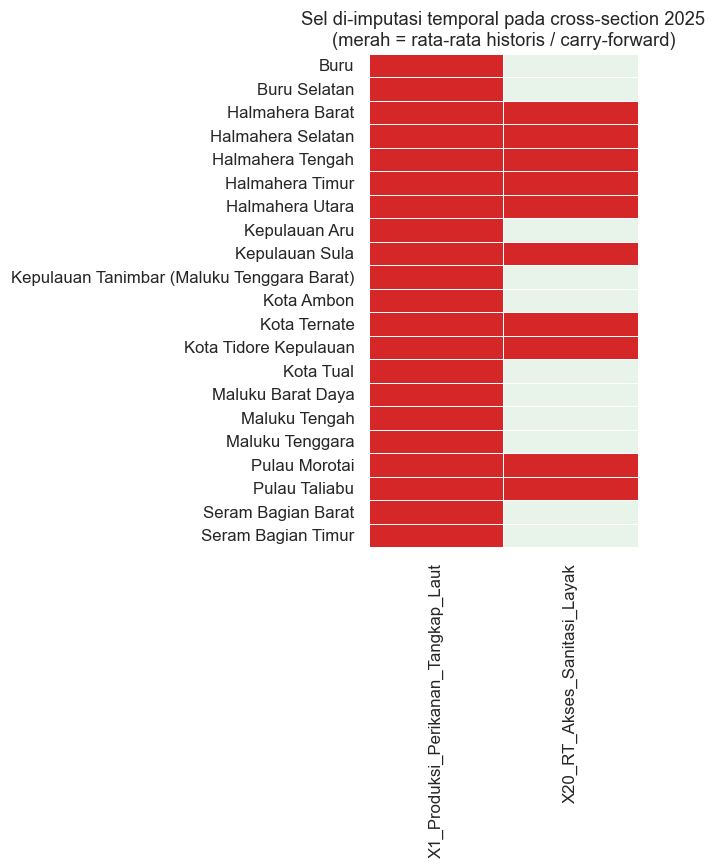

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\18_missing_2025_crosssection.png


In [27]:
flag_cols = {
    "X1_Produksi_Perikanan_Tangkap_Laut": cross["X1_Produksi_Perikanan_Tangkap_Laut_flag"].eq("rata2021_2024"),
    "X20_RT_Akses_Sanitasi_Layak": cross["X20_RT_Akses_Sanitasi_Layak_carried_forward"].astype(bool),
}
flag_matrix = pd.DataFrame(flag_cols)
flag_matrix.index = cross["kab_kota"].values
flag_matrix = flag_matrix.astype(int)

fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(flag_matrix, cmap=["#e8f4ea", "#d62728"], cbar=False, linewidths=0.5, linecolor="white", ax=ax)
ax.set_title("Sel di-imputasi temporal pada cross-section 2025\n(merah = rata-rata historis / carry-forward)")
ax.set_xlabel("")
ax.set_ylabel("")
savefig("18_missing_2025_crosssection.png")

### Figure 19 - VIF fitur final sebelum & sesudah eliminasi iteratif

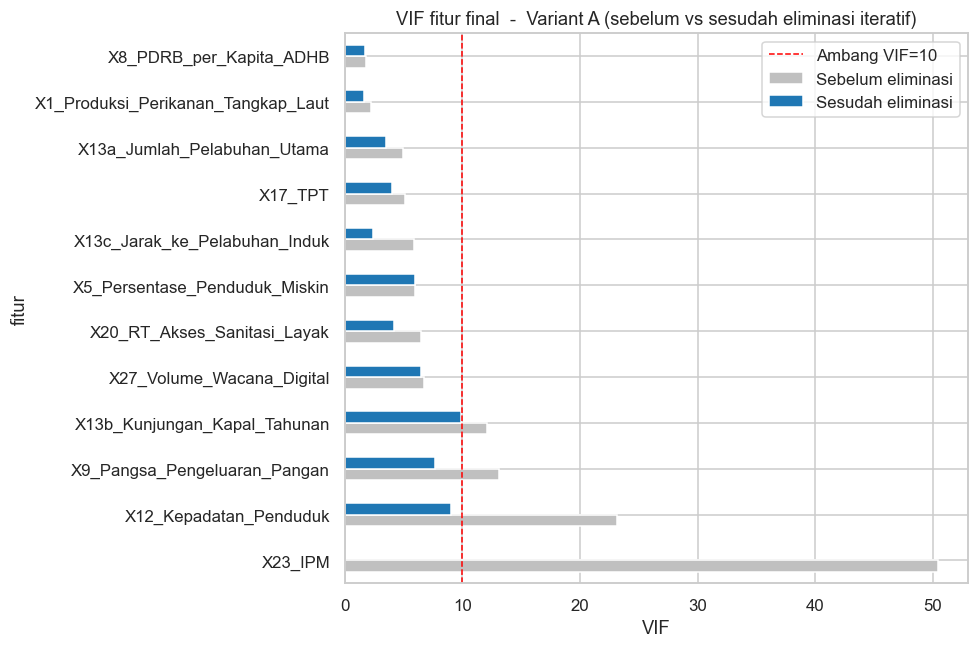

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\19_vif_final_features.png


In [28]:
vh = variant_data[PRIMARY_VARIANT]["vif_history"]
before = vh[vh["iterasi"] == 1].set_index("fitur")["VIF"]
after = vh[vh["iterasi"] == vh["iterasi"].max()].set_index("fitur")["VIF"]
cmp_vif = pd.DataFrame({"Sebelum eliminasi": before, "Sesudah eliminasi": after}).sort_values("Sebelum eliminasi", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
cmp_vif.plot.barh(ax=ax, color=["#c0c0c0", "#1f77b4"])
ax.axvline(10, color="red", linestyle="--", linewidth=1, label="Ambang VIF=10")
ax.set_xlabel("VIF")
ax.set_title(f"VIF fitur final  -  Variant {PRIMARY_VARIANT} (sebelum vs sesudah eliminasi iteratif)")
ax.legend()
savefig("19_vif_final_features.png")

### Figure 20 - Heatmap korelasi antar fitur final + Y

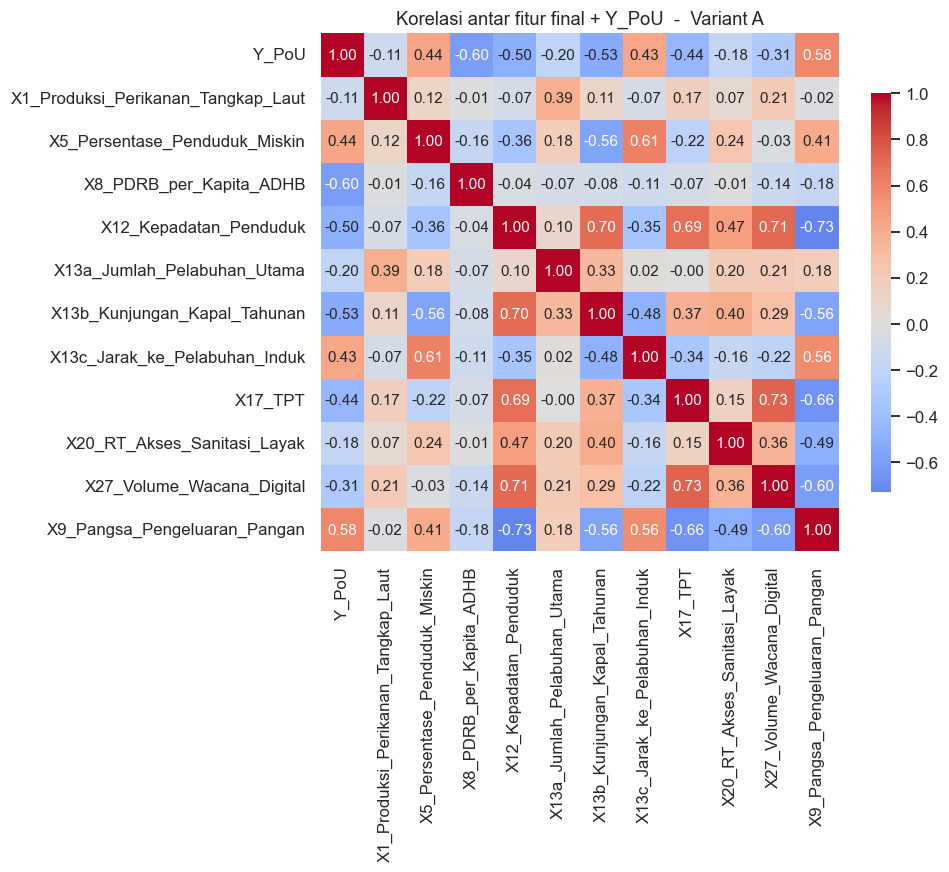

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\20_korelasi_fitur_final.png


In [29]:
corr_cols = ["Y_PoU"] + gwr_primary["feats"]
corr_mat_final = gwr_primary["data"][corr_cols].corr()
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr_mat_final, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True,
            cbar_kws={"shrink": 0.7})
ax.set_title(f"Korelasi antar fitur final + Y_PoU  -  Variant {PRIMARY_VARIANT}")
savefig("20_korelasi_fitur_final.png")

### Figure 21 - Diagnostik OLS: Residual vs Fitted, QQ-plot

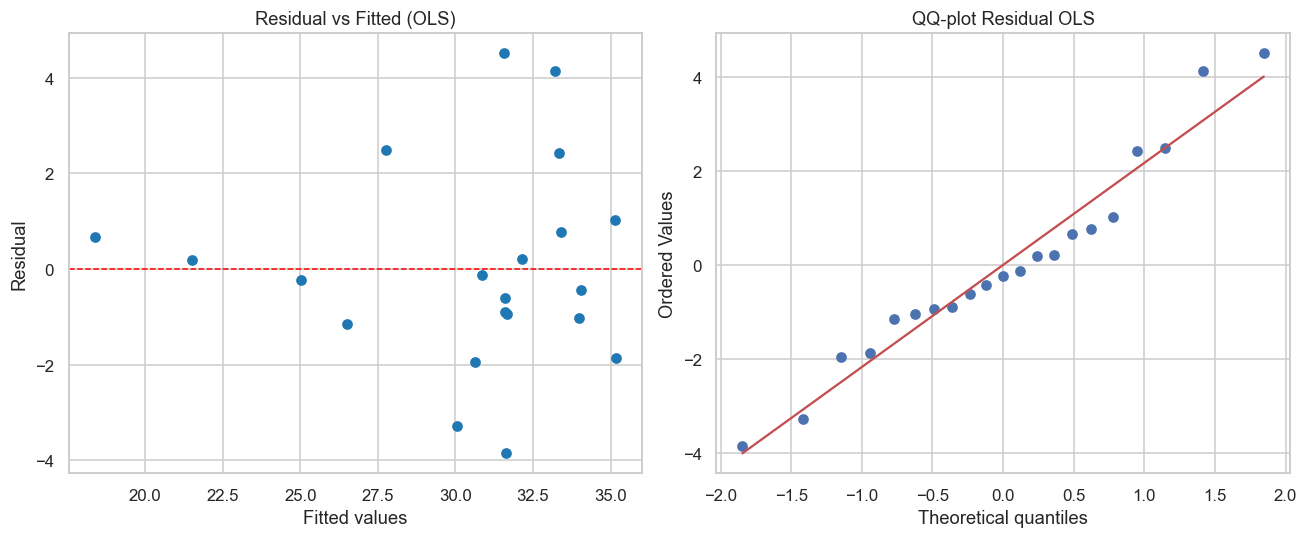

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\21_ols_diagnostic.png


In [30]:
import scipy.stats as st

ols_resid = ols_model.u.ravel()
ols_fitted = ols_model.predy.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(ols_fitted, ols_resid, color="#1f77b4")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual vs Fitted (OLS)")

st.probplot(ols_resid, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot Residual OLS")
savefig("21_ols_diagnostic.png")

### Figure 22 - Moran scatterplot residual OLS

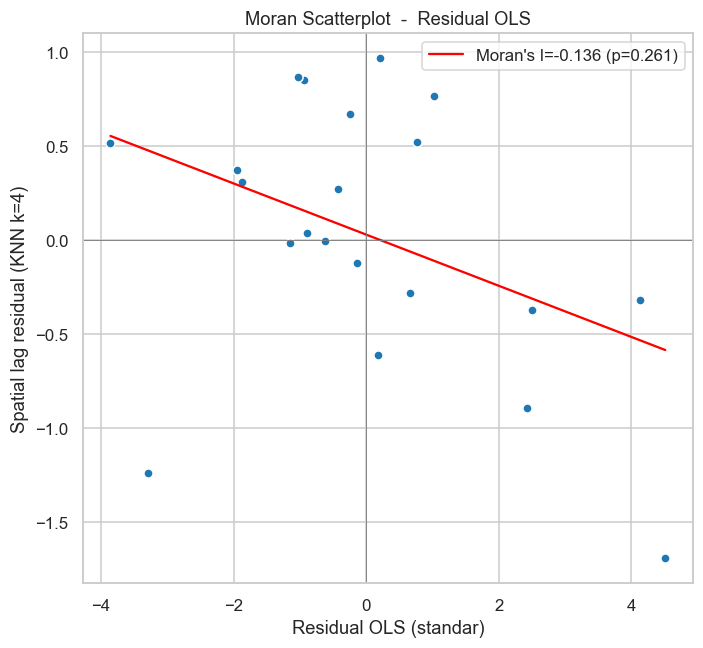

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\22_moran_residual_ols.png

Moran's I residual OLS (esda, cross-check): I=-0.1363, p_sim=0.2610


In [31]:
from esda.moran import Moran

moran_ols = Moran(ols_resid, w_knn)
lag_resid = libpysal.weights.lag_spatial(w_knn, ols_resid)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(ols_resid, lag_resid, color="#1f77b4", edgecolor="white")
b, a = np.polyfit(ols_resid, lag_resid, 1)
xs = np.linspace(ols_resid.min(), ols_resid.max(), 50)
ax.plot(xs, a + b * xs, color="red", linewidth=1.5, label=f"Moran's I={moran_ols.I:.3f} (p={moran_ols.p_sim:.3f})")
ax.axhline(0, color="grey", linewidth=0.6)
ax.axvline(0, color="grey", linewidth=0.6)
ax.set_xlabel("Residual OLS (standar)")
ax.set_ylabel("Spatial lag residual (KNN k=4)")
ax.set_title("Moran Scatterplot  -  Residual OLS")
ax.legend()
savefig("22_moran_residual_ols.png")
log(f"\nMoran's I residual OLS (esda, cross-check): I={moran_ols.I:.4f}, p_sim={moran_ols.p_sim:.4f}")

### Figure 23 - Perbandingan AICc antar model

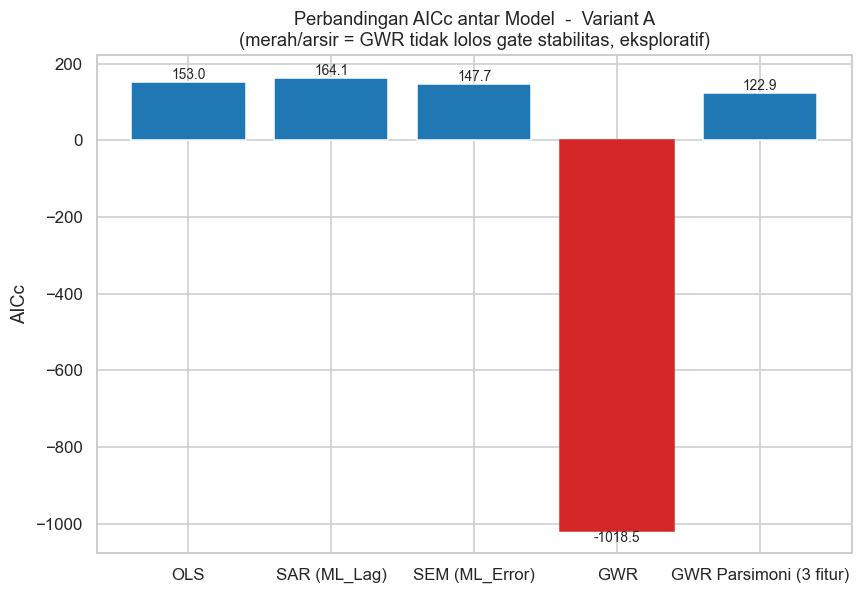

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\23_perbandingan_aic_model.png


In [32]:
cmp_df = pd.DataFrame(model_comparison_rows)
fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(cmp_df["model"], cmp_df["AICc"], color="#1f77b4")
for i, m in enumerate(cmp_df["model"]):
    if m == "GWR" and not gwr_primary["gate_pass"]:
        bars[i].set_color("#d62728")
        bars[i].set_hatch("//")
ax.set_ylabel("AICc")
ax.set_title(f"Perbandingan AICc antar Model  -  Variant {PRIMARY_VARIANT}\n(merah/arsir = GWR tidak lolos gate stabilitas, eksploratif)")
for i, v in enumerate(cmp_df["AICc"]):
    ax.text(i, v, f"{v:.1f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
savefig("23_perbandingan_aic_model.png")

### Figure 24 - Kurva AICc vs bandwidth (kalibrasi GWR)

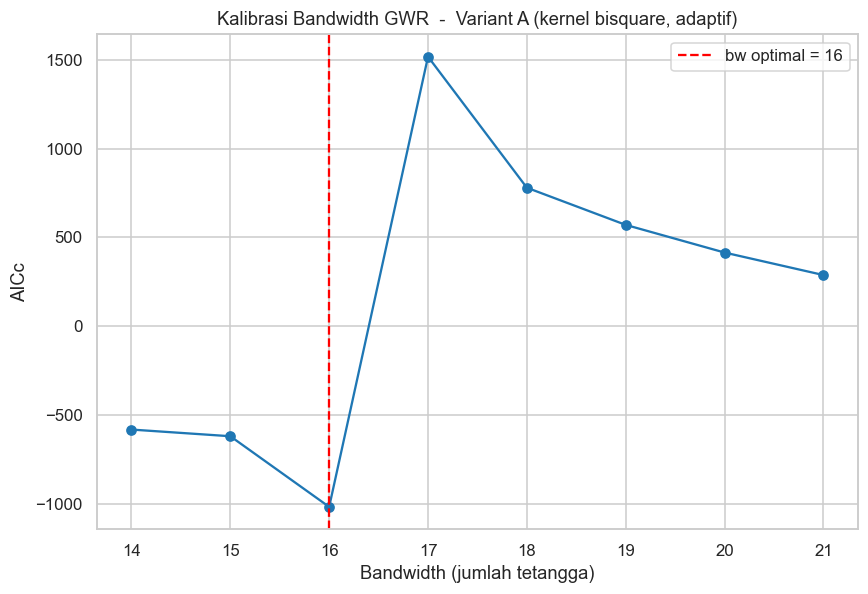

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\24_gwr_bandwidth_selection.png


In [33]:
ac = gwr_primary["aicc_curve"].sort_values("bandwidth_n_tetangga")
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(ac["bandwidth_n_tetangga"], ac["AICc"], marker="o", color="#1f77b4")
ax.axvline(gwr_primary["bw_opt"], color="red", linestyle="--", label=f"bw optimal = {gwr_primary['bw_opt']}")
ax.set_xlabel("Bandwidth (jumlah tetangga)")
ax.set_ylabel("AICc")
ax.set_title(f"Kalibrasi Bandwidth GWR  -  Variant {PRIMARY_VARIANT} (kernel bisquare, adaptif)")
ax.legend()
savefig("24_gwr_bandwidth_selection.png")

### Figure 25 - Choropleth Local RÂ² (GWR)

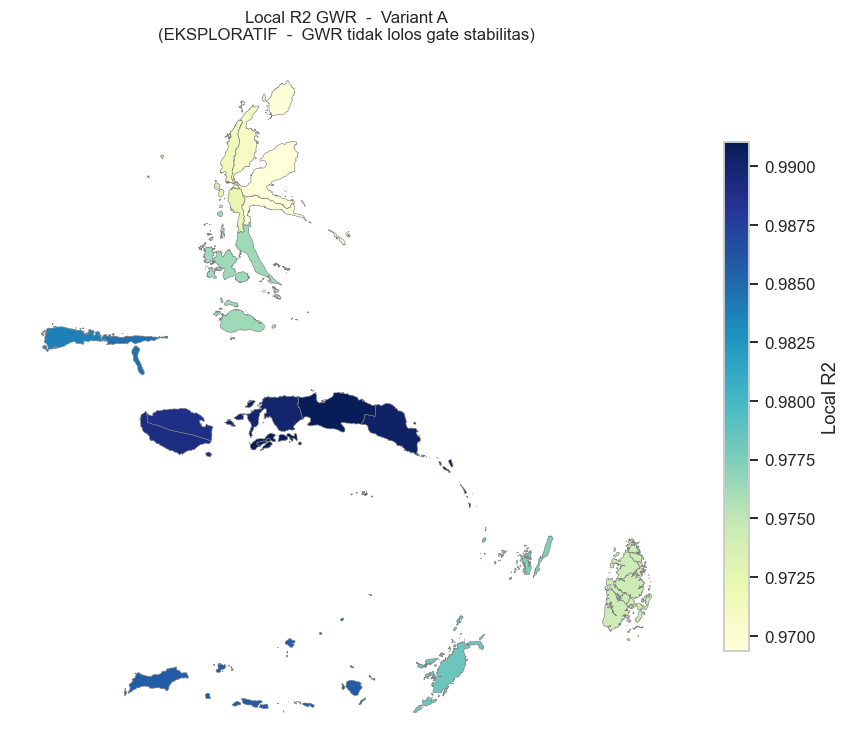

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\25_gwr_local_r2_choropleth.png


In [34]:
local_r2_series = gwr_primary["coef_full"].set_index("kab_kota")["local_R2"]
fig, ax = plt.subplots(figsize=(8, 8))
plot_choropleth(ax, local_r2_series, f"Local R2 GWR  -  Variant {PRIMARY_VARIANT}\n(EKSPLORATIF  -  GWR tidak lolos gate stabilitas)",
                cmap="YlGnBu", cbar_label="Local R2")
savefig("25_gwr_local_r2_choropleth.png")

### Figure 26+ - Peta koefisien lokal per prediktor
Dipilih: X8_PDRB_per_Kapita_ADHB (satu-satunya signifikan di OLS global) dan
X27_Volume_Wacana_Digital (variabel fokus Tahap 7). Karena GWR tidak lolos gate
stabilitas, TIDAK ADA lokasi yang signifikan lokal (alpha=0.05) - seluruh area
diarsir untuk merefleksikan hal ini secara jujur, bukan bug.

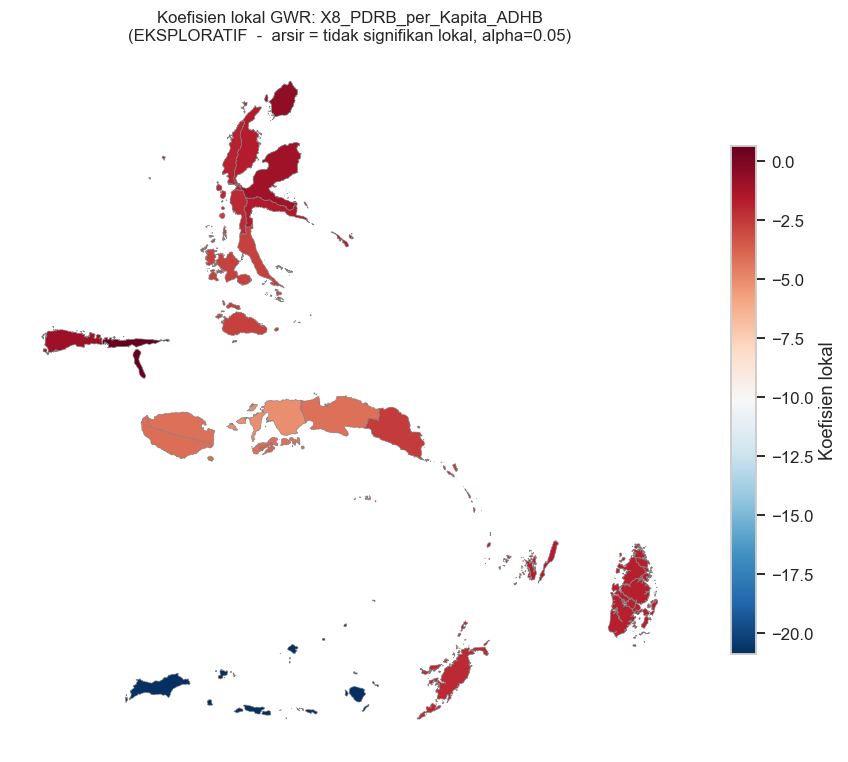

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\26_gwr_koefisien_lokal_X8_PDRB_per_Kapita_ADHB.png


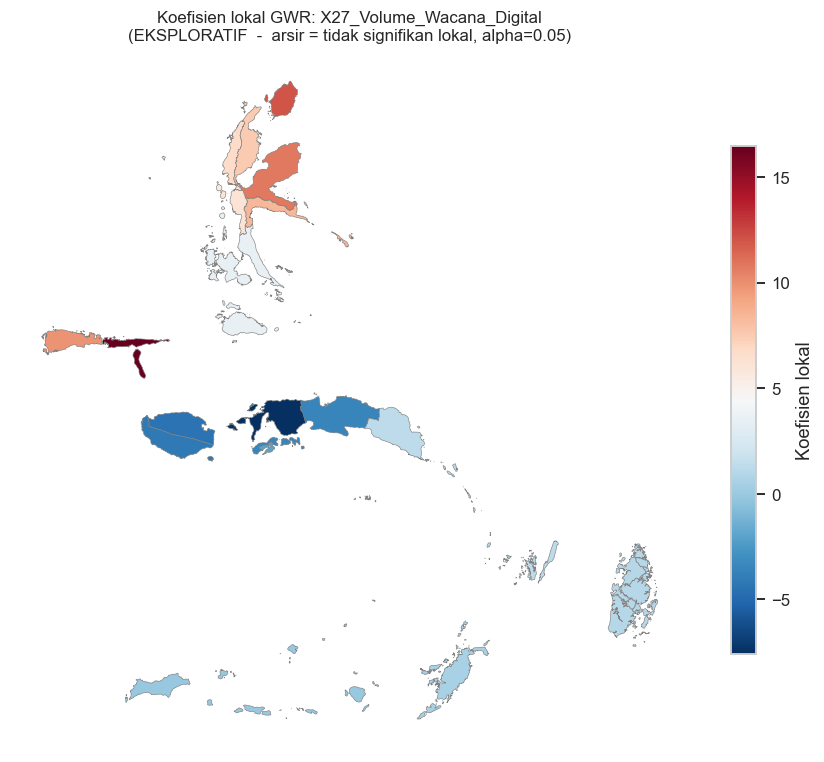

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\27_gwr_koefisien_lokal_X27_Volume_Wacana_Digital.png
Figure disimpan (salinan): D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\_x27_koefisien_lokal.png


In [35]:
COEF_MAP_FEATURES = ["X8_PDRB_per_Kapita_ADHB", "X27_Volume_Wacana_Digital"]
fig_no = 26
coef_fig_paths = {}
for feat in COEF_MAP_FEATURES:
    coef_series = gwr_primary["coef_full"].set_index("kab_kota")[feat]
    signif_series = gwr_primary["coef_full"].set_index("kab_kota")[f"{feat}_tval_signif"] != 0
    fig, ax = plt.subplots(figsize=(8, 8))
    plot_choropleth(ax, coef_series, f"Koefisien lokal GWR: {feat}\n(EKSPLORATIF  -  arsir = tidak signifikan lokal, alpha=0.05)",
                     cmap="RdBu_r", mask_series=signif_series, cbar_label="Koefisien lokal")
    fname = f"{fig_no}_gwr_koefisien_lokal_{feat}.png"
    savefig(fname)
    coef_fig_paths[feat] = fname
    if feat == "X27_Volume_Wacana_Digital":
        shutil.copyfile(FIG_DIR / fname, FIG_DIR / "_x27_koefisien_lokal.png")
        log(f"Figure disimpan (salinan): {FIG_DIR / '_x27_koefisien_lokal.png'}")
    fig_no += 1

### Figure - Local condition number per kab/kota (bukti gate stabilitas)

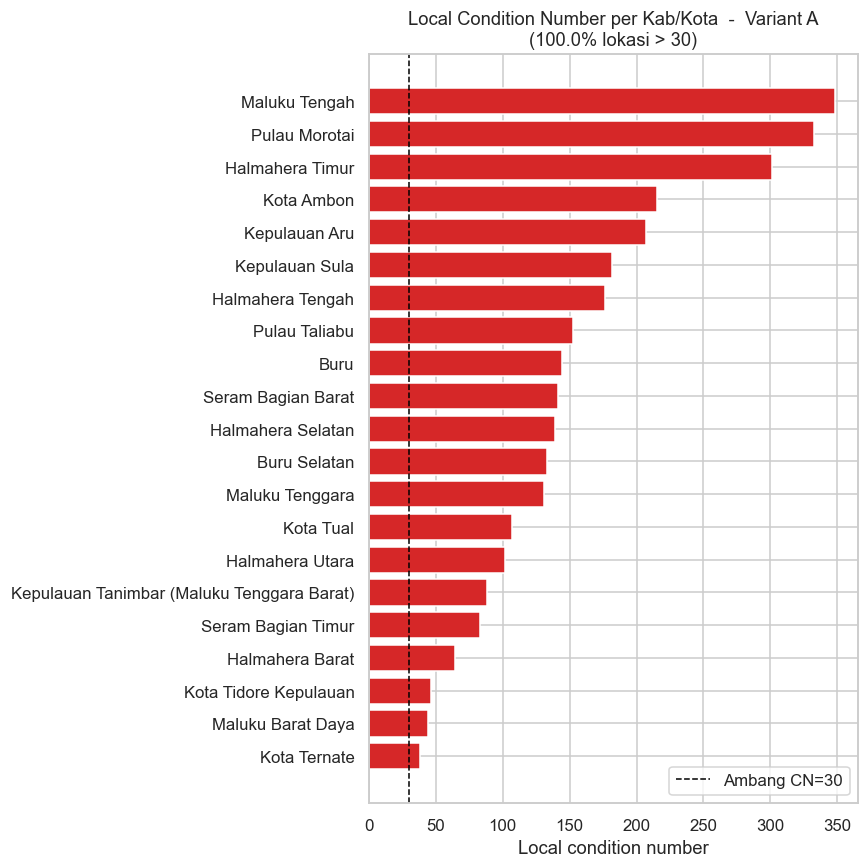

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\_gwr_local_condition_number.png


In [36]:
cn_series = gwr_primary["coef_full"].set_index("kab_kota")["local_condition_number"].sort_values()
colors_cn = ["#d62728" if v > 30 else "#2ca02c" for v in cn_series]
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(cn_series.index, cn_series.values, color=colors_cn)
ax.axvline(30, color="black", linestyle="--", linewidth=1, label="Ambang CN=30")
ax.set_xlabel("Local condition number")
ax.set_title(f"Local Condition Number per Kab/Kota  -  Variant {PRIMARY_VARIANT}\n({gwr_primary['pct_cn_over_30']:.1f}% lokasi > 30)")
ax.legend()
savefig("_gwr_local_condition_number.png")

### Figure 28+ - GWR Parsimoni: hasil lokal yang LOLOS gate stabilitas

Berbeda dari GWR 11-fitur di atas (eksploratif/tidak stabil), GWR Parsimoni
LOLOS gate stabilitas sehingga peta di bawah ini bisa dipakai untuk
interpretasi substantif, bukan hanya transparansi.

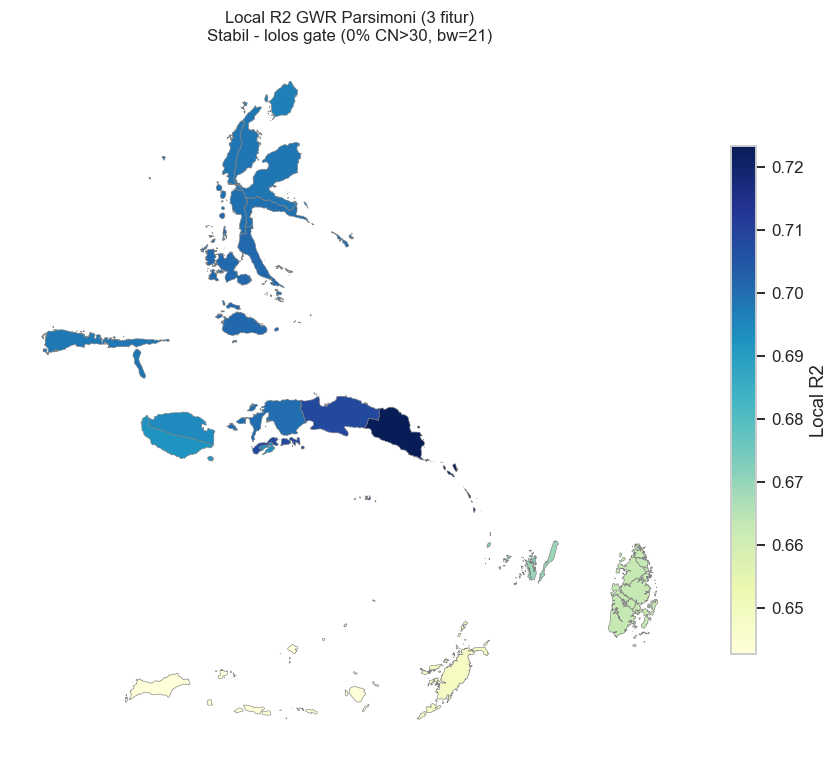

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\28_gwr_parsimoni_local_r2_choropleth.png


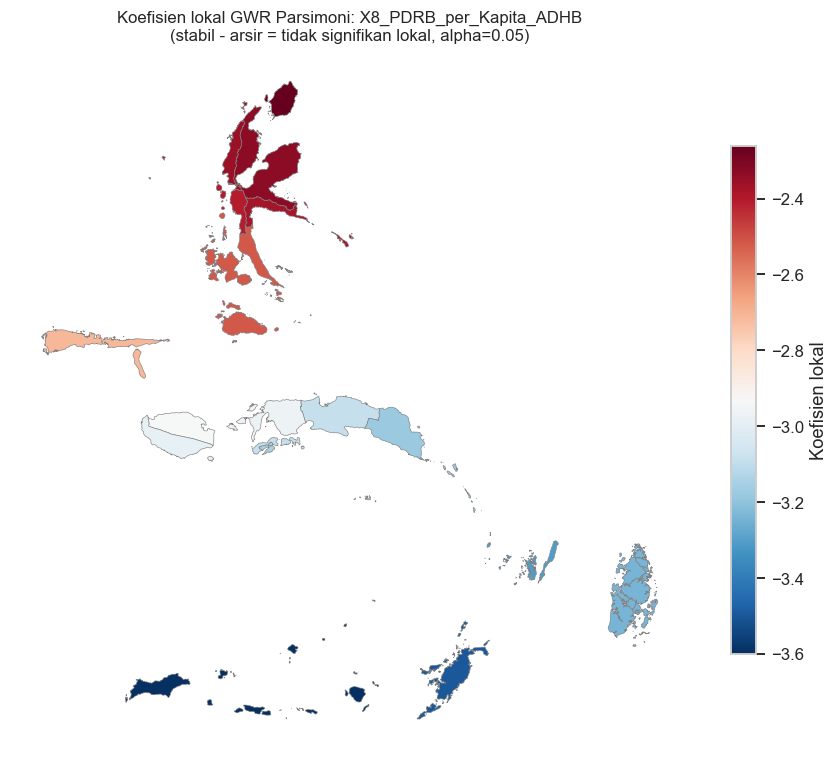

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\29_gwr_parsimoni_koefisien_lokal_X8_PDRB_per_Kapita_ADHB.png


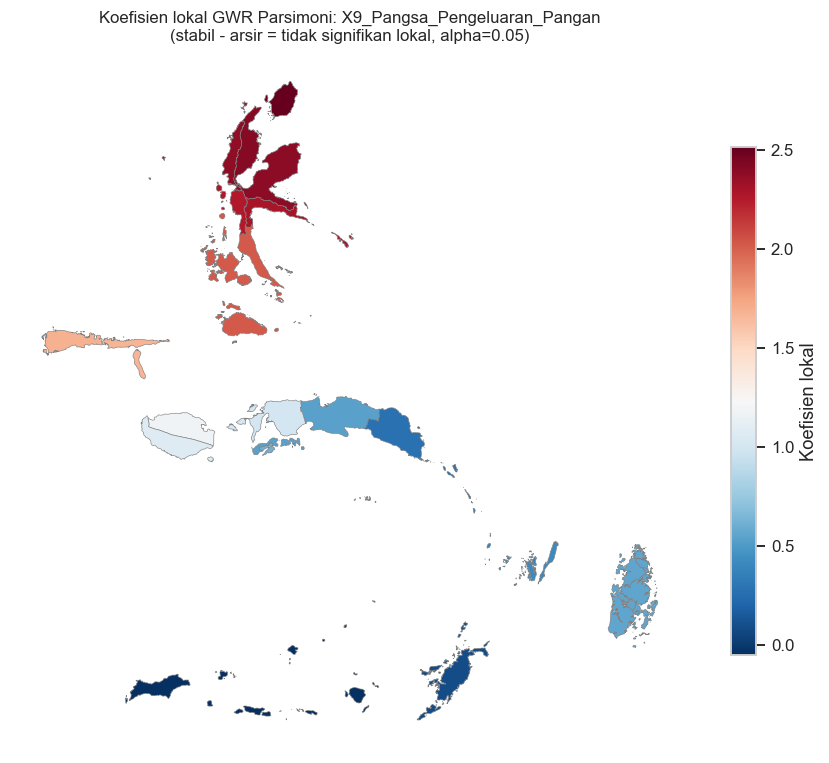

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\30_gwr_parsimoni_koefisien_lokal_X9_Pangsa_Pengeluaran_Pangan.png


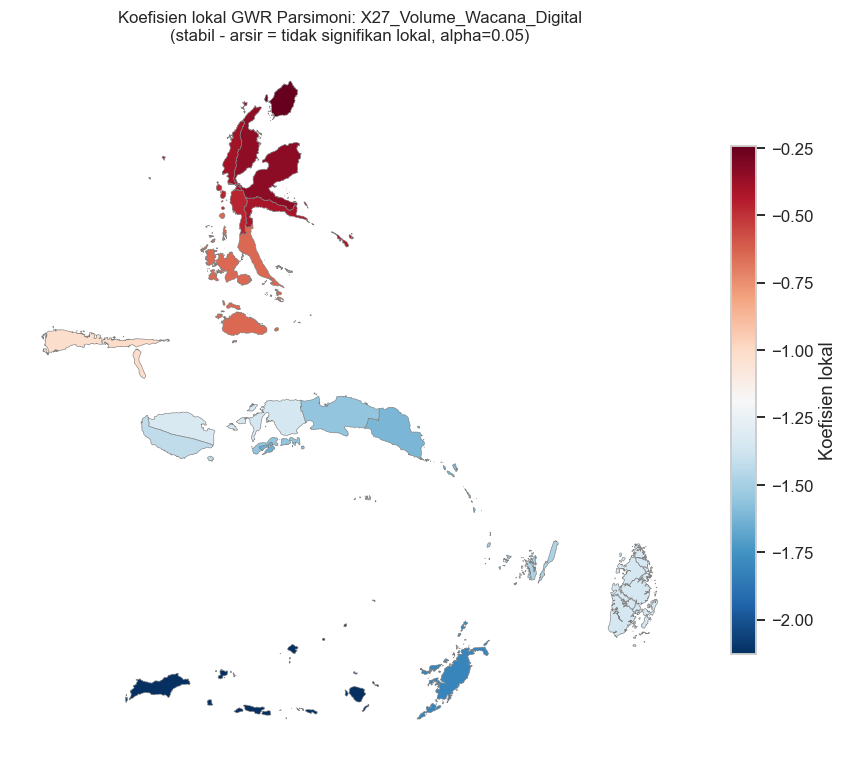

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\31_gwr_parsimoni_koefisien_lokal_X27_Volume_Wacana_Digital.png
Figure disimpan (salinan, menggantikan versi eksploratif): D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\_x27_koefisien_lokal.png


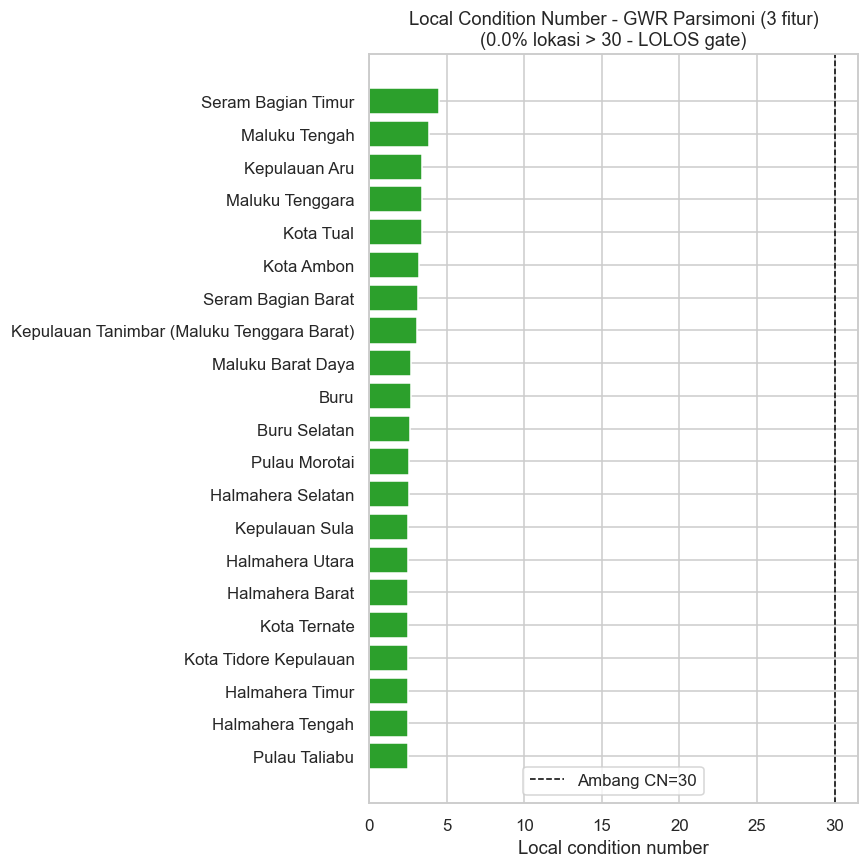

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\_gwr_parsimoni_local_condition_number.png


In [37]:
fig_no_p = 28
local_r2_p_series = gwr_parsimoni["coef_full"].set_index("kab_kota")["local_R2"]
fig, ax = plt.subplots(figsize=(8, 8))
plot_choropleth(
    ax, local_r2_p_series,
    f"Local R2 GWR Parsimoni ({len(PARSIMONIOUS_FEATURES)} fitur)\nStabil - lolos gate ({gwr_parsimoni['pct_cn_over_30']:.0f}% CN>30, bw={gwr_parsimoni['bw_opt']})",
    cmap="YlGnBu", cbar_label="Local R2",
)
savefig(f"{fig_no_p}_gwr_parsimoni_local_r2_choropleth.png")
fig_no_p += 1

for feat in PARSIMONIOUS_FEATURES:
    coef_series_p = gwr_parsimoni["coef_full"].set_index("kab_kota")[feat]
    signif_series_p = gwr_parsimoni["coef_full"].set_index("kab_kota")[f"{feat}_tval_signif"] != 0
    fig, ax = plt.subplots(figsize=(8, 8))
    plot_choropleth(ax, coef_series_p, f"Koefisien lokal GWR Parsimoni: {feat}\n(stabil - arsir = tidak signifikan lokal, alpha=0.05)",
                     cmap="RdBu_r", mask_series=signif_series_p, cbar_label="Koefisien lokal")
    fname_p = f"{fig_no_p}_gwr_parsimoni_koefisien_lokal_{feat}.png"
    savefig(fname_p)
    if feat == "X27_Volume_Wacana_Digital":
        shutil.copyfile(FIG_DIR / fname_p, FIG_DIR / "_x27_koefisien_lokal.png")
        log(f"Figure disimpan (salinan, menggantikan versi eksploratif): {FIG_DIR / '_x27_koefisien_lokal.png'}")
    fig_no_p += 1

cn_p_series = gwr_parsimoni["coef_full"].set_index("kab_kota")["local_condition_number"].sort_values()
colors_cn_p = ["#d62728" if v > 30 else "#2ca02c" for v in cn_p_series]
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(cn_p_series.index, cn_p_series.values, color=colors_cn_p)
ax.axvline(30, color="black", linestyle="--", linewidth=1, label="Ambang CN=30")
ax.set_xlabel("Local condition number")
ax.set_title(f"Local Condition Number - GWR Parsimoni ({len(PARSIMONIOUS_FEATURES)} fitur)\n({gwr_parsimoni['pct_cn_over_30']:.1f}% lokasi > 30 - LOLOS gate)")
ax.legend()
savefig("_gwr_parsimoni_local_condition_number.png")

### Figure - Bandwidth per variabel (MGWR), kondisional

In [38]:
if mgwr_bw_tbl is not None:
    fig, ax = plt.subplots(figsize=(8, 6))
    mbw = mgwr_bw_tbl.sort_values("bandwidth")
    ax.barh(mbw["variabel"], mbw["bandwidth"], color="#1f77b4")
    ax.set_xlabel("Bandwidth (jumlah tetangga)")
    ax.set_title("Bandwidth per Variabel  -  MGWR")
    savefig("_mgwr_bandwidth_per_variabel.png")
else:
    log("\nFigure _mgwr_bandwidth_per_variabel.png DILEWATI: MGWR tidak dijalankan (GWR tidak lolos gate stabilitas di Tahap 5).")


Figure _mgwr_bandwidth_per_variabel.png DILEWATI: MGWR tidak dijalankan (GWR tidak lolos gate stabilitas di Tahap 5).


### Figure - Scatter "krisis senyap": PoU vs X27

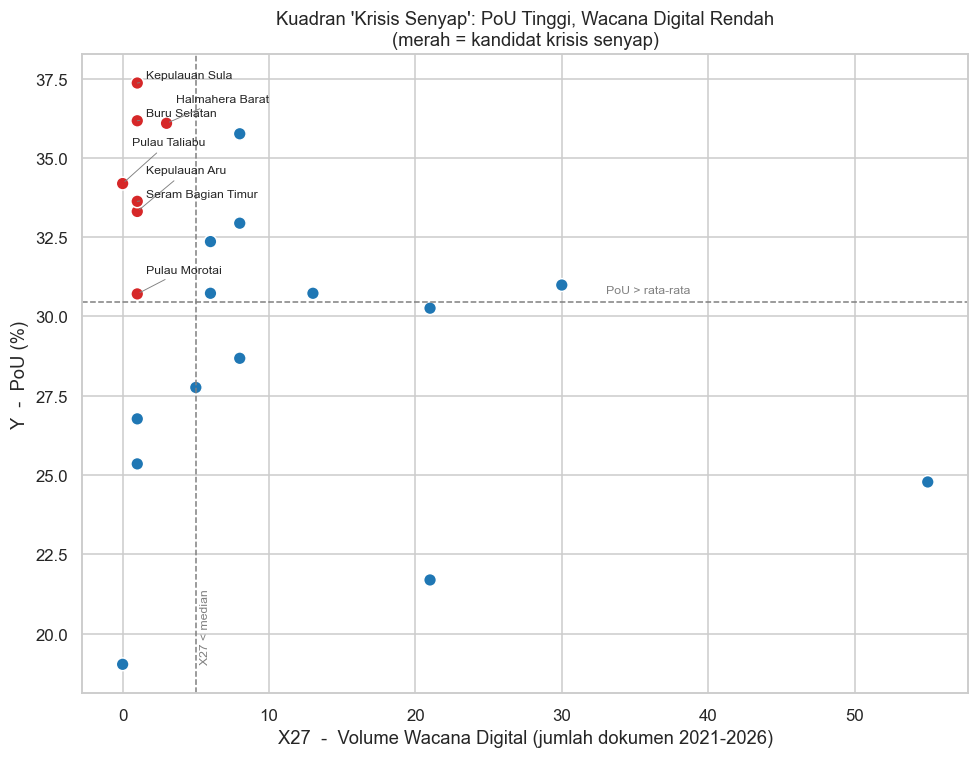

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\_x27_krisis_senyap_scatter.png


In [39]:
fig, ax = plt.subplots(figsize=(9, 7))
colors_qc = kr["kandidat_krisis_senyap"].map({True: "#d62728", False: "#1f77b4"})
ax.scatter(kr["X27_Volume_Wacana_Digital"], kr["Y_PoU"], c=colors_qc, s=70, edgecolor="white")
ax.axhline(pou_mean, color="grey", linestyle="--", linewidth=1)
ax.axvline(x27_median, color="grey", linestyle="--", linewidth=1)
for i, (_, row) in enumerate(kr[kr["kandidat_krisis_senyap"]].iterrows()):
    y_off = 3 + (i % 3) * 11  # selang-seling agar label kandidat yang berdekatan tidak tumpang tindih
    ax.annotate(row["kab_kota"], (row["X27_Volume_Wacana_Digital"], row["Y_PoU"]),
                fontsize=8, xytext=(6, y_off), textcoords="offset points",
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.6))
ax.set_xlabel("X27  -  Volume Wacana Digital (jumlah dokumen 2021-2026)")
ax.set_ylabel("Y  -  PoU (%)")
ax.set_title("Kuadran 'Krisis Senyap': PoU Tinggi, Wacana Digital Rendah\n(merah = kandidat krisis senyap)")
ax.text(kr["X27_Volume_Wacana_Digital"].max() * 0.6, pou_mean + 0.3, "PoU > rata-rata", fontsize=8, color="grey")
ax.text(x27_median + 0.3, kr["Y_PoU"].min(), "X27 < median", fontsize=8, color="grey", rotation=90, va="bottom")
savefig("_x27_krisis_senyap_scatter.png")

## Tahap 9 - Tabel perbandingan seluruh model

In [40]:
cmp_df.to_csv(TAB_DIR / "perbandingan_semua_model.csv", index=False)
log(f"\nDisimpan: {TAB_DIR / 'perbandingan_semua_model.csv'}")
log(cmp_df.to_string(index=False))

if mgwr_bw_tbl is None:
    log("\nCatatan: mgwr_bandwidth_per_variabel.csv TIDAK dibuat - MGWR tidak dijalankan karena GWR (Tahap 5) tidak lolos gate stabilitas.")


Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\perbandingan_semua_model.csv
                  model         AICc        AIC  R2_atau_pseudoR2     RMSE
                    OLS   153.018924 114.018924          0.810717 2.063429
           SAR (ML_Lag)   164.094127 112.094127          0.851807 1.826526
         SEM (ML_Error)   147.651792 108.651792          0.800501 2.172064
                    GWR -1018.477751        NaN          0.981637 0.642700
GWR Parsimoni (3 fitur)   122.904798        NaN          0.706125 2.571078

Catatan: mgwr_bandwidth_per_variabel.csv TIDAK dibuat - MGWR tidak dijalankan karena GWR (Tahap 5) tidak lolos gate stabilitas.


## Tahap 11 (Bonus) - GTWR: memakai seluruh panel 2020-2025 untuk mengembalikan 11 fitur

Solusi parsimoni (Tahap 5B) menstabilkan GWR dengan mengorbankan jumlah fitur (11 -> 3).
Alternatif lain: perbesar N. GTWR (Geographically & Temporally Weighted Regression, Huang,
Wu & Barry 2010) memakai seluruh 126 observasi kabupaten-tahun (2020-2025), bukan hanya
cross-section 2025, dengan menambah jarak waktu ke jarak spasial pada kernel bobot.
`mgwr` tidak menyediakan GTWR bawaan, sehingga diimplementasikan manual di bawah
(regresi tertimbang lokal langsung dengan numpy, memakai formula AICc yang identik dengan
GWR standar). Tujuannya: uji apakah 11 fitur asli (bukan hanya 3) bisa diestimasi stabil
saat N diperbesar dari 21 menjadi 126.

In [41]:
from scipy.spatial.distance import pdist, squareform


def build_gtwr_panel(feature_list: list) -> pd.DataFrame:
    """Bangun panel 126-baris dengan aturan imputasi TEMPORAL yang identik dengan
    cross-section 2025 (Tahap 1b), diterapkan di seluruh tahun, bukan hanya titik akhir."""
    panel = df_panel.copy()
    # X1: isi 2025 dengan rata-rata 2021-2024 per kabupaten (aturan yang sama persis)
    mask_2025 = panel["tahun"] == 2025
    panel.loc[mask_2025, "X1_Produksi_Perikanan_Tangkap_Laut"] = (
        panel.loc[mask_2025, "kab_kota"].map(x1_mean.set_index("kab_kota")["X1_Produksi_Perikanan_Tangkap_Laut"])
    )
    # X20: carry-forward dalam kabupaten yang sama (ffill kronologis) -- identik dgn aturan cross-section
    panel = panel.sort_values(["kab_kota", "tahun"])
    panel["X20_RT_Akses_Sanitasi_Layak"] = panel.groupby("kab_kota")["X20_RT_Akses_Sanitasi_Layak"].ffill()
    # X27: statis (agregat 2021-2026), broadcast ke semua tahun kabupaten yang sama
    panel = panel.merge(cross[["kab_kota", "X27_Volume_Wacana_Digital"]], on="kab_kota", how="left")
    panel = panel.merge(coords_tbl, on="kab_kota", how="left")
    n_missing = panel[feature_list + ["Y_PoU"]].isna().sum().sum()
    log(f"Panel GTWR: {panel.shape[0]} baris (kabupaten x tahun), nilai kosong tersisa: {n_missing}")
    assert n_missing == 0, "Panel GTWR seharusnya lengkap setelah imputasi temporal yang sama dengan cross-section"
    return panel.reset_index(drop=True)


GTWR_FEATURES = variant_data[PRIMARY_VARIANT]["final_features"]  # 11 fitur asli, bukan versi parsimoni
panel_gtwr = build_gtwr_panel(GTWR_FEATURES)

for f in GTWR_FEATURES:
    panel_gtwr[f + "_z"] = (panel_gtwr[f] - panel_gtwr[f].mean()) / panel_gtwr[f].std(ddof=0)

n_gtwr = len(panel_gtwr)
y_gtwr = panel_gtwr[["Y_PoU"]].values
X_gtwr = panel_gtwr[[f + "_z" for f in GTWR_FEATURES]].values
Xc_gtwr = np.column_stack([np.ones(n_gtwr), X_gtwr])
p_gtwr = Xc_gtwr.shape[1]

# Jarak spasial (centroid AEQD, sama seperti tahap lain) dan jarak waktu (tahun), masing-masing
# dinormalisasi dengan simpangan bakunya sendiri sebelum digabung -- pendekatan praktis standar
# untuk menyetarakan satuan meter vs tahun tanpa perlu tuning rasio ruang-waktu secara manual.
d_S_gtwr = squareform(pdist(panel_gtwr[["x_m", "y_m"]].values))
d_T_gtwr = squareform(pdist(panel_gtwr[["tahun"]].values.astype(float)))
d_S_norm = d_S_gtwr / d_S_gtwr[d_S_gtwr > 0].std()
d_T_norm = d_T_gtwr / d_T_gtwr[d_T_gtwr > 0].std()
d_ST_gtwr = np.sqrt(d_S_norm ** 2 + d_T_norm ** 2)


def gtwr_bisquare_weights(d_row: np.ndarray, bw: float) -> np.ndarray:
    w = np.zeros_like(d_row)
    mask = d_row < bw
    w[mask] = (1 - (d_row[mask] / bw) ** 2) ** 2
    return w


def gtwr_fit(d_ST: np.ndarray, Xc: np.ndarray, y: np.ndarray, bw_k: int) -> dict:
    """Regresi tertimbang lokal (GWR-style) pada jarak ruang-waktu gabungan. Mengembalikan
    koefisien lokal, AICc (formula identik Fotheringham et al. yang dipakai mgwr), local R2,
    dan local condition number/VIF untuk gate stabilitas yang setara dengan Tahap 5."""
    n, p = Xc.shape
    betas = np.zeros((n, p))
    hat_diag = np.zeros(n)
    yhat = np.zeros(n)
    local_R2 = np.zeros(n)
    local_CN = np.zeros(n)
    local_VIF = np.zeros((n, p - 1))
    for i in range(n):
        d_row = d_ST[i, :]
        bw = np.partition(d_row, bw_k - 1)[bw_k - 1] * 1.0000001
        w = gtwr_bisquare_weights(d_row, bw)
        W = np.diag(w)
        XtW = Xc.T @ W
        XtWX = XtW @ Xc
        XtWX_inv = np.linalg.inv(XtWX)
        beta_i = XtWX_inv @ XtW @ y
        betas[i, :] = beta_i.ravel()
        yhat[i] = (Xc[i:i + 1, :] @ beta_i).item()
        hat_diag[i] = (Xc[i:i + 1, :] @ XtWX_inv @ XtW[:, i:i + 1]).item()

        sw = np.sqrt(w).reshape(-1, 1)
        Xw = Xc * sw
        svals = np.linalg.svd(Xw, compute_uv=False)
        svals = svals[svals > 1e-12]
        local_CN[i] = svals.max() / svals.min()

        corr_local = np.corrcoef((Xc[:, 1:] * sw).T)
        try:
            vif_i = np.diag(np.linalg.inv(corr_local))
        except np.linalg.LinAlgError:
            vif_i = np.full(p - 1, np.nan)
        local_VIF[i, :] = vif_i

        resid_w = w * (y.ravel() - (Xc @ beta_i).ravel()) ** 2
        ybar_w = np.sum(w * y.ravel()) / np.sum(w)
        tss_w = np.sum(w * (y.ravel() - ybar_w) ** 2)
        local_R2[i] = 1 - resid_w.sum() / tss_w if tss_w > 0 else np.nan

    resid = y.ravel() - yhat
    rss = float(np.sum(resid ** 2))
    tr_S = float(hat_diag.sum())
    sigma2 = rss / n
    aicc = 2 * n * np.log(np.sqrt(sigma2)) + n * np.log(2 * np.pi) + n * ((n + tr_S) / (n - 2 - tr_S))
    tss = float(np.sum((y.ravel() - y.mean()) ** 2))
    R2 = 1 - rss / tss
    return {
        "betas": betas, "aicc": aicc, "tr_S": tr_S, "R2": R2, "rss": rss,
        "local_R2": local_R2, "local_CN": local_CN, "local_VIF": local_VIF, "yhat": yhat,
    }


bw_min_gtwr = p_gtwr + 10
bw_max_gtwr = n_gtwr
gtwr_bw_grid = list(range(bw_min_gtwr, bw_max_gtwr + 1, 2))
gtwr_search_rows = []
gtwr_fits = {}
for bw_k in gtwr_bw_grid:
    r = gtwr_fit(d_ST_gtwr, Xc_gtwr, y_gtwr, bw_k)
    gtwr_search_rows.append({"bw_k": bw_k, "AICc": r["aicc"], "R2": r["R2"], "tr_S": r["tr_S"]})
    gtwr_fits[bw_k] = r

gtwr_search_df = pd.DataFrame(gtwr_search_rows)
gtwr_search_df.to_csv(TAB_DIR / "gtwr_bandwidth_selection.csv", index=False)
best_row = gtwr_search_df.loc[gtwr_search_df["AICc"].idxmin()]
bw_opt_gtwr = int(best_row["bw_k"])
gtwr_result = gtwr_fits[bw_opt_gtwr]

log(f"\nGTWR: bandwidth ruang-waktu adaptif optimal = {bw_opt_gtwr} tetangga (dari {bw_min_gtwr}-{bw_max_gtwr}, N={n_gtwr})")
log(f"GTWR: AICc={gtwr_result['aicc']:.3f}, R2={gtwr_result['R2']:.4f}, effective params (tr_S)={gtwr_result['tr_S']:.2f} (vs {p_gtwr} parameter mentah)")

pct_cn_gtwr = float((gtwr_result["local_CN"] > 30).mean() * 100)
pct_vif_gtwr = float((gtwr_result["local_VIF"] > 10).any(axis=1).mean() * 100)
gate_pass_gtwr = (pct_cn_gtwr <= STABILITY_THRESHOLD_PCT) and (pct_vif_gtwr <= STABILITY_THRESHOLD_PCT)
log(f"GTWR Gate stabilitas ({len(GTWR_FEATURES)} fitur asli, N={n_gtwr}): {pct_cn_gtwr:.1f}% obs CN>30, {pct_vif_gtwr:.1f}% obs local VIF>10 (ambang {STABILITY_THRESHOLD_PCT}%)")
if gate_pass_gtwr:
    log(f"GATE LOLOS -> dengan memperbesar N dari 21 (cross-section) menjadi {n_gtwr} (panel), 11 fitur ASLI bisa diestimasi stabil secara lokal. Ini bukti langsung bahwa GWR/MGWR MUNGKIN dilakukan di Kepulauan Maluku asalkan N cukup besar relatif jumlah prediktor.")
else:
    log("GATE TIDAK LOLOS -> bahkan dengan panel penuh, 11 fitur masih belum cukup stabil; pertimbangkan reduksi fitur tambahan pada pendekatan panel ini juga.")

gtwr_stab_tbl = pd.DataFrame([{
    "model": f"GTWR panel ({len(GTWR_FEATURES)} fitur, N={n_gtwr})",
    "bandwidth_optimal": bw_opt_gtwr,
    "pct_lokasi_CN_gt_30": pct_cn_gtwr,
    "pct_lokasi_localVIF_gt_10": pct_vif_gtwr,
    "ambang_persen": STABILITY_THRESHOLD_PCT,
    "gate_lolos": gate_pass_gtwr,
    "AICc": gtwr_result["aicc"],
    "R2": gtwr_result["R2"],
    "effective_params": gtwr_result["tr_S"],
}])
gtwr_stab_tbl.to_csv(TAB_DIR / "gtwr_diagnostik_stabilitas.csv", index=False)
log(f"Disimpan: {TAB_DIR / 'gtwr_diagnostik_stabilitas.csv'}")
log(
    "\nCATATAN PENTING: AICc GTWR (N=126) TIDAK bisa dibandingkan langsung secara nilai absolut "
    "dengan AICc model cross-section (N=21) pada tables/perbandingan_semua_model.csv -- basis "
    "observasinya berbeda. Perbandingan yang valid adalah status LOLOS/TIDAK gate stabilitas."
)

coef_gtwr_tbl = pd.DataFrame(gtwr_result["betas"], columns=["Intercept"] + GTWR_FEATURES)
coef_gtwr_tbl.insert(0, "tahun", panel_gtwr["tahun"].values)
coef_gtwr_tbl.insert(0, "kab_kota", panel_gtwr["kab_kota"].values)
coef_gtwr_tbl["local_R2"] = gtwr_result["local_R2"]
coef_gtwr_tbl["local_condition_number"] = gtwr_result["local_CN"]
coef_gtwr_tbl.to_csv(TAB_DIR / "gtwr_koefisien_lokal_kabkota_tahun.csv", index=False)
log(f"Disimpan: {TAB_DIR / 'gtwr_koefisien_lokal_kabkota_tahun.csv'}")

Panel GTWR: 126 baris (kabupaten x tahun), nilai kosong tersisa: 0



GTWR: bandwidth ruang-waktu adaptif optimal = 96 tetangga (dari 22-126, N=126)
GTWR: AICc=726.601, R2=0.7563, effective params (tr_S)=28.52 (vs 12 parameter mentah)
GTWR Gate stabilitas (11 fitur asli, N=126): 0.0% obs CN>30, 54.8% obs local VIF>10 (ambang 35.0%)
GATE TIDAK LOLOS -> bahkan dengan panel penuh, 11 fitur masih belum cukup stabil; pertimbangkan reduksi fitur tambahan pada pendekatan panel ini juga.
Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\gtwr_diagnostik_stabilitas.csv

CATATAN PENTING: AICc GTWR (N=126) TIDAK bisa dibandingkan langsung secara nilai absolut dengan AICc model cross-section (N=21) pada tables/perbandingan_semua_model.csv -- basis observasinya berbeda. Perbandingan yang valid adalah status LOLOS/TIDAK gate stabilitas.
Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\gtwr_koefisien_lokal_kabkota_tahun.csv


### Figure - Kalibrasi bandwidth GTWR & peta koefisien (irisan tahun 2025)

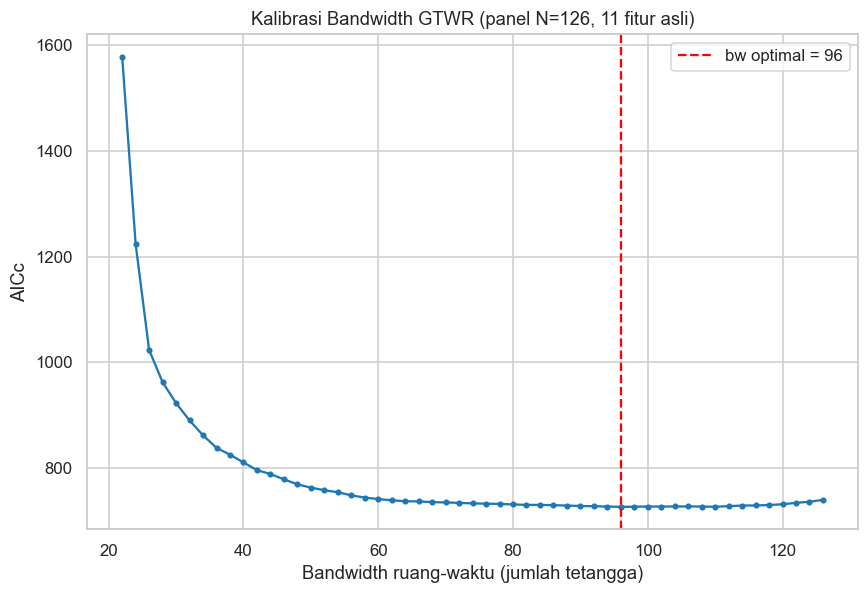

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\32_gtwr_bandwidth_selection.png


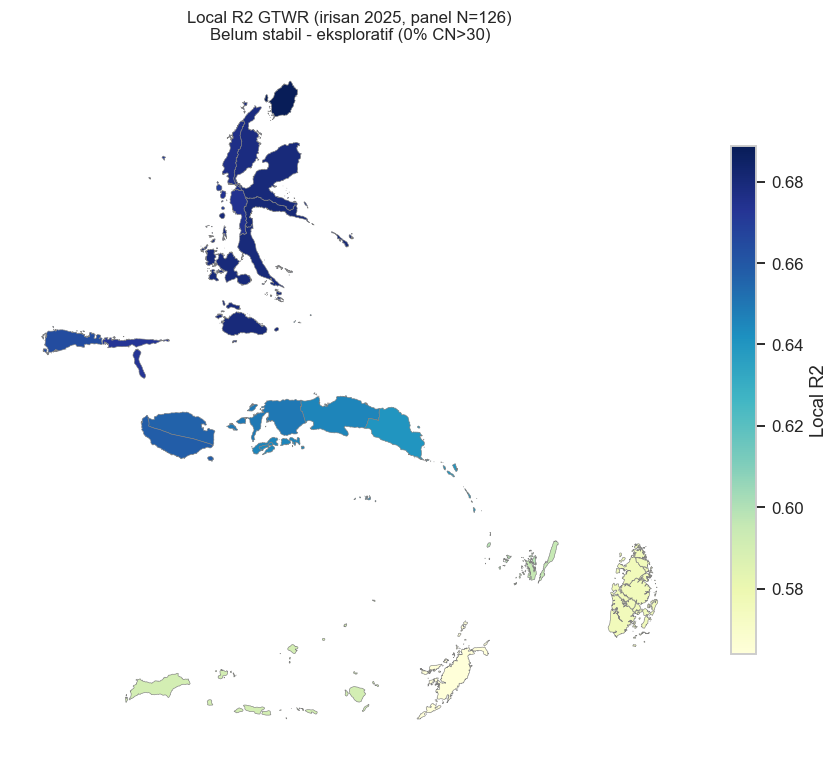

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\33_gtwr_local_r2_2025_choropleth.png


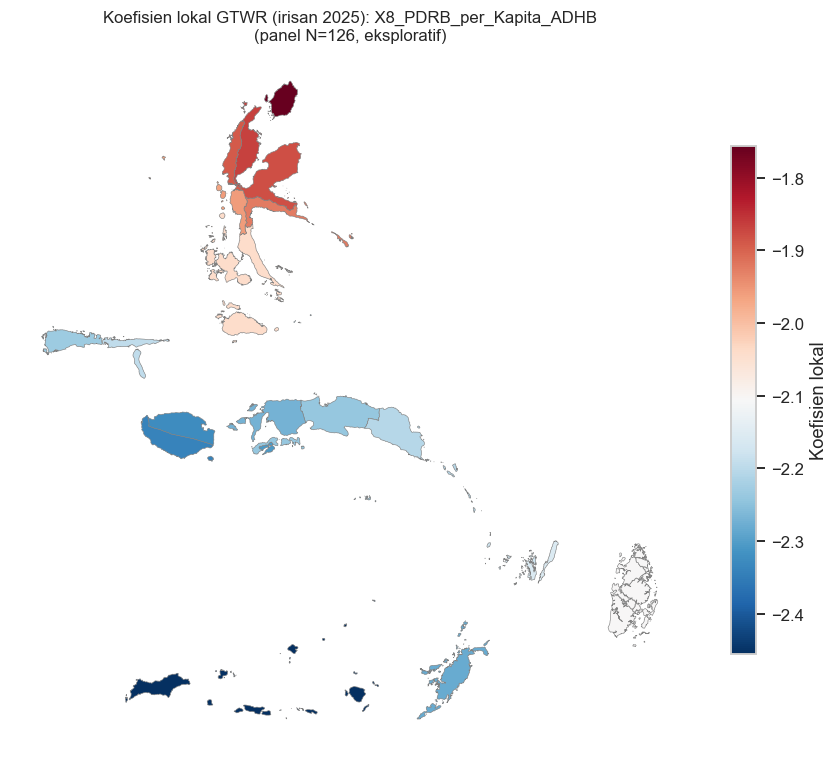

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\34_gtwr_koefisien_lokal_2025_X8_PDRB_per_Kapita_ADHB.png


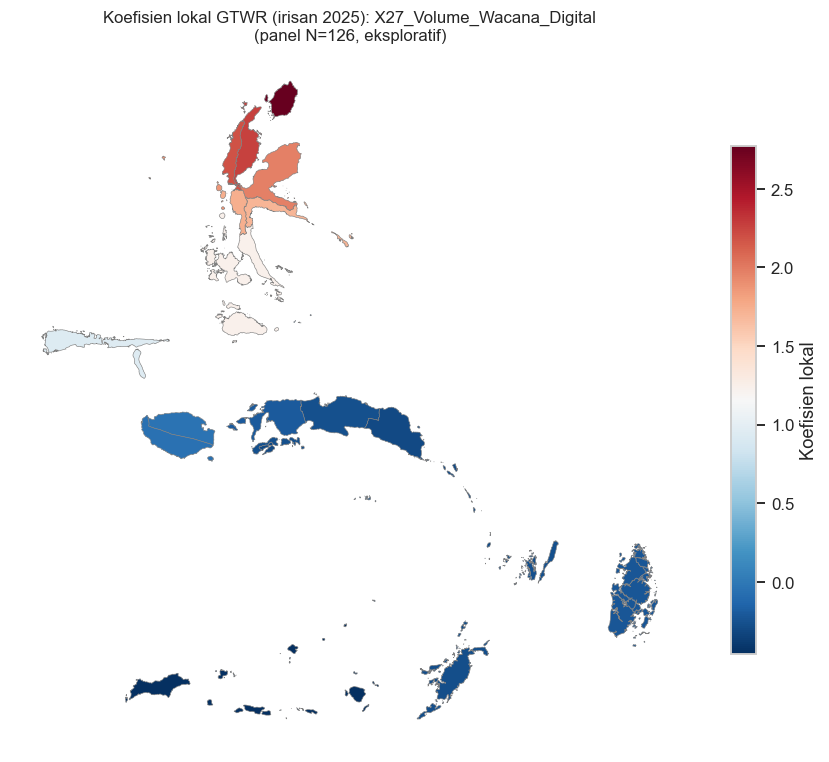

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\35_gtwr_koefisien_lokal_2025_X27_Volume_Wacana_Digital.png


In [42]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(gtwr_search_df["bw_k"], gtwr_search_df["AICc"], marker="o", markersize=3, color="#1f77b4")
ax.axvline(bw_opt_gtwr, color="red", linestyle="--", label=f"bw optimal = {bw_opt_gtwr}")
ax.set_xlabel("Bandwidth ruang-waktu (jumlah tetangga)")
ax.set_ylabel("AICc")
ax.set_title(f"Kalibrasi Bandwidth GTWR (panel N={n_gtwr}, {len(GTWR_FEATURES)} fitur asli)")
ax.legend()
savefig("32_gtwr_bandwidth_selection.png")

slice_2025 = coef_gtwr_tbl[coef_gtwr_tbl["tahun"] == 2025].set_index("kab_kota")
fig, ax = plt.subplots(figsize=(8, 8))
plot_choropleth(ax, slice_2025["local_R2"], f"Local R2 GTWR (irisan 2025, panel N={n_gtwr})\n{'Stabil - lolos gate' if gate_pass_gtwr else 'Belum stabil - eksploratif'} ({pct_cn_gtwr:.0f}% CN>30)",
                 cmap="YlGnBu", cbar_label="Local R2")
savefig("33_gtwr_local_r2_2025_choropleth.png")

fig_no_g = 34
for feat in ["X8_PDRB_per_Kapita_ADHB", "X27_Volume_Wacana_Digital"]:
    if feat not in GTWR_FEATURES:
        continue
    fig, ax = plt.subplots(figsize=(8, 8))
    plot_choropleth(ax, slice_2025[feat], f"Koefisien lokal GTWR (irisan 2025): {feat}\n(panel N={n_gtwr}, {'stabil' if gate_pass_gtwr else 'eksploratif'})",
                     cmap="RdBu_r", cbar_label="Koefisien lokal")
    savefig(f"{fig_no_g}_gtwr_koefisien_lokal_2025_{feat}.png")
    fig_no_g += 1

### Figure - Tren temporal koefisien lokal X27 (contoh 4 kabupaten)

Nilai tambah GTWR dibanding GWR cross-section: koefisien lokal boleh berubah antar
TAHUN untuk kabupaten yang sama, bukan hanya antar kabupaten.

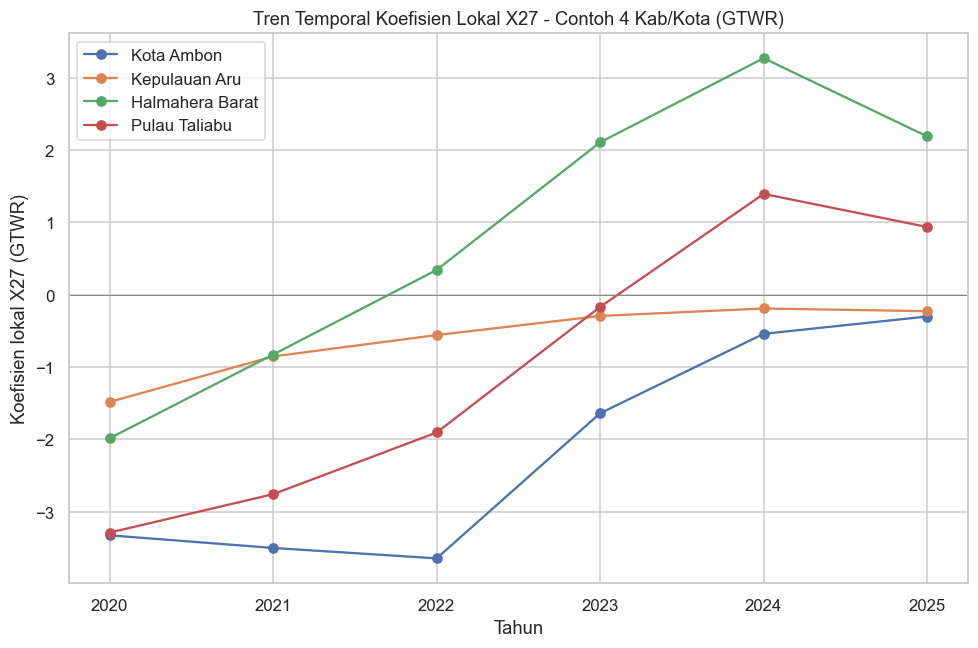

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\_gtwr_tren_temporal_x27_contoh.png


In [43]:
if "X27_Volume_Wacana_Digital" in GTWR_FEATURES:
    sample_kab = ["Kota Ambon", "Kepulauan Aru", "Halmahera Barat", "Pulau Taliabu"]
    fig, ax = plt.subplots(figsize=(9, 6))
    for kab in sample_kab:
        sub = coef_gtwr_tbl[coef_gtwr_tbl["kab_kota"] == kab].sort_values("tahun")
        ax.plot(sub["tahun"], sub["X27_Volume_Wacana_Digital"], marker="o", label=kab)
    ax.axhline(0, color="grey", linewidth=0.6)
    ax.set_xlabel("Tahun")
    ax.set_ylabel("Koefisien lokal X27 (GTWR)")
    ax.set_title("Tren Temporal Koefisien Lokal X27 - Contoh 4 Kab/Kota (GTWR)")
    ax.legend()
    savefig("_gtwr_tren_temporal_x27_contoh.png")

## Tahap 12 - Backward Elimination GTWR Berbasis Diagnostik

GTWR 11-fitur (Bagian sebelumnya) lolos gate condition number (0,0%) tapi belum lolos
gate local VIF (54,8%). Bagian ini mencari jumlah fitur MINIMUM yang perlu dibuang dari
panel N=126 supaya KEDUA gate lolos bersamaan, memakai backward elimination yang
keputusannya diambil dari local VIF yang dihitung ULANG di setiap iterasi (bukan ranking
yang dihitung sekali di awal) - kolinearitas antar variabel bisa berubah begitu satu
variabel dibuang.

In [44]:
def build_Xc_gtwr(panel: pd.DataFrame, feature_list: list) -> np.ndarray:
    n = len(panel)
    X = panel[[f + "_z" for f in feature_list]].values
    return np.column_stack([np.ones(n), X])


def gtwr_bw_search(d_ST: np.ndarray, Xc: np.ndarray, y: np.ndarray, bw_grid: list) -> tuple:
    rows = []
    fits = {}
    for bw_k in bw_grid:
        r = gtwr_fit(d_ST, Xc, y, bw_k)
        rows.append({"bw_k": bw_k, "AICc": r["aicc"], "R2": r["R2"], "tr_S": r["tr_S"]})
        fits[bw_k] = r
    search_df = pd.DataFrame(rows)
    best_row = search_df.loc[search_df["AICc"].idxmin()]
    bw_opt = int(best_row["bw_k"])
    return bw_opt, fits[bw_opt], search_df


def gtwr_search_bw_adaptive(d_ST: np.ndarray, Xc: np.ndarray, y: np.ndarray, n: int,
                             center: int = None, span: int = 15, full_step: int = 2) -> tuple:
    """Cari bandwidth optimal. Jika `center` diberikan, cari dulu di jendela sempit di
    sekitarnya (mempercepat iterasi eliminasi); jika hasil optimalnya jatuh tepat di tepi
    jendela sempit, verifikasi ulang dengan grid penuh supaya optimum sejati tidak terlewat."""
    p_incl_const = Xc.shape[1]
    full_min, full_max = p_incl_const + 10, n
    if center is None:
        bw_min, bw_max, step = full_min, full_max, full_step
    else:
        bw_min = max(full_min, int(round(center)) - span)
        bw_max = min(full_max, int(round(center)) + span)
        step = 1
    grid = list(range(bw_min, bw_max + 1, step))
    bw_opt, result, search_df = gtwr_bw_search(d_ST, Xc, y, grid)
    edge_hit = center is not None and bw_opt in (bw_min, bw_max) and (bw_min > full_min or bw_max < full_max)
    if edge_hit:
        log(f"    (bw optimal {bw_opt} di tepi jendela sempit [{bw_min},{bw_max}] -> verifikasi grid penuh [{full_min},{full_max}])")
        full_grid = list(range(full_min, full_max + 1, full_step))
        bw_opt, result, search_df = gtwr_bw_search(d_ST, Xc, y, full_grid)
    return bw_opt, result, search_df


def gtwr_gate_stats(result: dict) -> tuple:
    pct_cn = float((result["local_CN"] > 30).mean() * 100)
    pct_vif = float((result["local_VIF"] > 10).any(axis=1).mean() * 100)
    gate_pass = (pct_cn <= STABILITY_THRESHOLD_PCT) and (pct_vif <= STABILITY_THRESHOLD_PCT)
    return pct_cn, pct_vif, gate_pass


def local_vif_ranking(result: dict, feature_list: list) -> pd.DataFrame:
    mean_vif = result["local_VIF"].mean(axis=0)
    pct_vif = (result["local_VIF"] > 10).mean(axis=0) * 100
    rank_df = pd.DataFrame({"fitur": feature_list, "mean_local_VIF": mean_vif, "pct_obs_VIF_gt_10": pct_vif})
    return rank_df.sort_values(["pct_obs_VIF_gt_10", "mean_local_VIF"], ascending=False).reset_index(drop=True)


PRIORITAS_PERTAHANKAN = [
    "X8_PDRB_per_Kapita_ADHB",
    "X27_Volume_Wacana_Digital",
    "X9_Pangsa_Pengeluaran_Pangan",
    "X13b_Kunjungan_Kapal_Tahunan",
    "X13c_Jarak_ke_Pelabuhan_Induk",
]

### 12a. Langkah 0 - Buang X20 (perbaikan bug data, bukan eliminasi statistik)

In [45]:
elim_trail_rows = []

FEATURES_AFTER_X20 = [f for f in GTWR_FEATURES if f != "X20_RT_Akses_Sanitasi_Layak"]
Xc0 = build_Xc_gtwr(panel_gtwr, FEATURES_AFTER_X20)
bw0, fit0, _ = gtwr_search_bw_adaptive(d_ST_gtwr, Xc0, y_gtwr, n_gtwr, center=bw_opt_gtwr, span=20)
pct_cn0, pct_vif0, gate0 = gtwr_gate_stats(fit0)
log(f"\nTahap 12a: buang X20 (bug data level-provinsi) -> {len(FEATURES_AFTER_X20)} fitur tersisa.")
log(f"bw optimal={bw0}, {pct_cn0:.1f}% lokasi CN>30, {pct_vif0:.1f}% lokasi local VIF>10 -> gate {'LOLOS' if gate0 else 'BELUM LOLOS'}")

elim_trail_rows.append({
    "iterasi": 0, "fitur_dibuang": "X20_RT_Akses_Sanitasi_Layak",
    "alasan": "bug data (duplikasi level-provinsi, lihat Tahap 1b / Bagian 2 ringkasan)",
    "jumlah_fitur_tersisa": len(FEATURES_AFTER_X20), "bandwidth_optimal": bw0,
    "pct_lokasi_CN_gt_30": pct_cn0, "pct_lokasi_VIF_gt_10": pct_vif0, "gate_lolos": gate0,
})

current_features, current_fit, current_bw = FEATURES_AFTER_X20, fit0, bw0


Tahap 12a: buang X20 (bug data level-provinsi) -> 10 fitur tersisa.
bw optimal=110, 0.0% lokasi CN>30, 7.1% lokasi local VIF>10 -> gate LOLOS


### 12b. Backward elimination berbasis local VIF (jika 12a saja belum cukup)

In [46]:
if gate0:
    log("\nGate LOLOS hanya dengan menghapus X20 -> backward elimination berbasis VIF TIDAK diperlukan, lanjut ke 12c.")
else:
    iterasi = 1
    while len(current_features) > 3:
        rank_df = local_vif_ranking(current_fit, current_features)
        log(f"\n--- Iterasi {iterasi}: ranking local VIF ({len(current_features)} fitur tersisa) ---")
        log(rank_df.to_string(index=False))

        success = False
        for attempt in range(len(rank_df)):
            drop_feat = rank_df.iloc[attempt]["fitur"]
            drop_pct = rank_df.iloc[attempt]["pct_obs_VIF_gt_10"]
            if drop_feat in PRIORITAS_PERTAHANKAN:
                log(f"PERINGATAN: variabel prioritas {drop_feat} terpaksa dibuang pada iterasi {iterasi} karena VIF tertinggi -- "
                    "pertimbangkan opsi rekayasa fitur di Tahap 12d sebagai alternatif.")
            trial_features = [f for f in current_features if f != drop_feat]
            try:
                Xc_t = build_Xc_gtwr(panel_gtwr, trial_features)
                bw_t, fit_t, _ = gtwr_search_bw_adaptive(d_ST_gtwr, Xc_t, y_gtwr, n_gtwr, center=current_bw, span=15)
                pct_cn_t, pct_vif_t, gate_t = gtwr_gate_stats(fit_t)
                alasan_t = f"local VIF tertinggi ({drop_pct:.1f}% obs > 10)"
                if attempt > 0:
                    alasan_t += f" [percobaan ke-{attempt + 1}, fitur peringkat lebih tinggi gagal fit]"
                elim_trail_rows.append({
                    "iterasi": iterasi, "fitur_dibuang": drop_feat, "alasan": alasan_t,
                    "jumlah_fitur_tersisa": len(trial_features), "bandwidth_optimal": bw_t,
                    "pct_lokasi_CN_gt_30": pct_cn_t, "pct_lokasi_VIF_gt_10": pct_vif_t, "gate_lolos": gate_t,
                })
                log(f"Iterasi {iterasi}: buang {drop_feat} -> {len(trial_features)} fitur, bw={bw_t}, "
                    f"CN>30={pct_cn_t:.1f}%, VIF>10={pct_vif_t:.1f}%, gate={'LOLOS' if gate_t else 'belum'}")
                current_features, current_fit, current_bw = trial_features, fit_t, bw_t
                success = True
                break
            except Exception as exc:  # noqa: BLE001 - tangkap & lanjut ke kandidat VIF berikutnya sesuai instruksi brief
                log(f"Iterasi {iterasi}: buang {drop_feat} GAGAL FIT ({exc!r}) -> coba fitur peringkat berikutnya.")
                elim_trail_rows.append({
                    "iterasi": iterasi, "fitur_dibuang": drop_feat, "alasan": f"GAGAL FIT: {exc!r}",
                    "jumlah_fitur_tersisa": len(trial_features), "bandwidth_optimal": np.nan,
                    "pct_lokasi_CN_gt_30": np.nan, "pct_lokasi_VIF_gt_10": np.nan, "gate_lolos": "ERROR",
                })
                continue

        if not success:
            log(f"Iterasi {iterasi}: SEMUA kandidat fitur untuk dibuang gagal fit -> eliminasi dihentikan paksa.")
            break

        iterasi += 1
        _, _, gate_now = gtwr_gate_stats(current_fit)
        if gate_now:
            log(f"\nGate LOLOS pada {len(current_features)} fitur -> eliminasi berhenti.")
            break

final_features_12b, final_fit_12b, final_bw_12b = current_features, current_fit, current_bw
pct_cn_12b, pct_vif_12b, gate_12b = gtwr_gate_stats(final_fit_12b)
log(f"\n=== Hasil akhir 12b (eliminasi murni): {len(final_features_12b)} fitur -- {', '.join(final_features_12b)} ===")
log(f"Bandwidth optimal={final_bw_12b}, {pct_cn_12b:.1f}% CN>30, {pct_vif_12b:.1f}% VIF>10 -> gate {'LOLOS' if gate_12b else 'TIDAK LOLOS'}")

konvergen_ke_parsimoni = set(final_features_12b) == {
    "X8_PDRB_per_Kapita_ADHB", "X9_Pangsa_Pengeluaran_Pangan", "X27_Volume_Wacana_Digital",
}
if len(final_features_12b) == 3 and not gate_12b:
    log(f"TEMUAN PENTING: bahkan pada floor 3 fitur, gate GTWR masih belum lolos penuh pada panel N={n_gtwr} -- "
        "indikasi kolinieritas struktural yang lebih dalam daripada temuan cross-section. Dilaporkan sebagai "
        "keterbatasan, TIDAK dipaksakan lebih jauh ke 2 fitur.")
if konvergen_ke_parsimoni:
    log("CATATAN: feature-set final 12b KONVERGEN persis ke set yang sama dengan solusi parsimoni cross-section "
        "(X8, X9, X27) -- Tahap 5B -- meski pada N jauh lebih besar (panel vs cross-section).")


Gate LOLOS hanya dengan menghapus X20 -> backward elimination berbasis VIF TIDAK diperlukan, lanjut ke 12c.

=== Hasil akhir 12b (eliminasi murni): 10 fitur -- X1_Produksi_Perikanan_Tangkap_Laut, X5_Persentase_Penduduk_Miskin, X8_PDRB_per_Kapita_ADHB, X12_Kepadatan_Penduduk, X13a_Jumlah_Pelabuhan_Utama, X13b_Kunjungan_Kapal_Tahunan, X13c_Jarak_ke_Pelabuhan_Induk, X17_TPT, X27_Volume_Wacana_Digital, X9_Pangsa_Pengeluaran_Pangan ===
Bandwidth optimal=110, 0.0% CN>30, 7.1% VIF>10 -> gate LOLOS


### 12c. Jejak lengkap eliminasi

In [47]:
elim_trail_df = pd.DataFrame(elim_trail_rows)
elim_trail_df.to_csv(TAB_DIR / "gtwr_jejak_eliminasi.csv", index=False)
log(f"\nDisimpan: {TAB_DIR / 'gtwr_jejak_eliminasi.csv'}")
log(elim_trail_df.to_string(index=False))


Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\gtwr_jejak_eliminasi.csv
 iterasi               fitur_dibuang                                                                   alasan  jumlah_fitur_tersisa  bandwidth_optimal  pct_lokasi_CN_gt_30  pct_lokasi_VIF_gt_10  gate_lolos
       0 X20_RT_Akses_Sanitasi_Layak bug data (duplikasi level-provinsi, lihat Tahap 1b / Bagian 2 ringkasan)                    10                110                  0.0              7.142857        True


### 12d. Varian rekayasa fitur (tambahan, BUKAN pengganti 12b): Indeks Konektivitas Maritim

X13a/X13b/X13c digabung menjadi satu fitur `X13_Konektivitas_Maritim` (rata-rata Z-score
X13b dan X13c, dengan X13c dibalik tandanya dulu jika arah korelasinya ke PoU berlawanan
dengan X13b). X13a TIDAK diikutsertakan (korelasi ke PoU paling lemah). Bobot rata-rata
sederhana dipakai (bukan PCA otomatis), karena pengalaman sebelumnya PCA mengubur komponen
jarak yang justru paling informatif.

In [48]:
corr_13a = float(np.corrcoef(panel_gtwr["X13a_Jumlah_Pelabuhan_Utama"], panel_gtwr["Y_PoU"])[0, 1])
corr_13b = float(np.corrcoef(panel_gtwr["X13b_Kunjungan_Kapal_Tahunan"], panel_gtwr["Y_PoU"])[0, 1])
corr_13c = float(np.corrcoef(panel_gtwr["X13c_Jarak_ke_Pelabuhan_Induk"], panel_gtwr["Y_PoU"])[0, 1])
log(f"\nKorelasi Pearson terhadap Y_PoU (panel N={n_gtwr}): X13a r={corr_13a:.3f}, X13b r={corr_13b:.3f}, X13c r={corr_13c:.3f}")

flip_13c = -1.0 if np.sign(corr_13c) != np.sign(corr_13b) else 1.0
log(f"X13c {'DIBALIK tandanya' if flip_13c < 0 else 'TIDAK dibalik'} sebelum digabung dengan X13b "
    f"(arah korelasi terhadap PoU {'berlawanan' if flip_13c < 0 else 'searah'}).")

panel_gtwr["X13_Konektivitas_Maritim_z"] = (
    panel_gtwr["X13b_Kunjungan_Kapal_Tahunan_z"] + flip_13c * panel_gtwr["X13c_Jarak_ke_Pelabuhan_Induk_z"]
) / 2.0

FEATURES_12D = [
    f for f in FEATURES_AFTER_X20
    if f not in ("X13a_Jumlah_Pelabuhan_Utama", "X13b_Kunjungan_Kapal_Tahunan", "X13c_Jarak_ke_Pelabuhan_Induk")
] + ["X13_Konektivitas_Maritim"]

Xc_12d = build_Xc_gtwr(panel_gtwr, FEATURES_12D)
bw_12d, fit_12d, _ = gtwr_search_bw_adaptive(d_ST_gtwr, Xc_12d, y_gtwr, n_gtwr, center=bw_opt_gtwr, span=20)
pct_cn_12d, pct_vif_12d, gate_12d = gtwr_gate_stats(fit_12d)
log(f"\nTahap 12d ({len(FEATURES_12D)} fitur: {', '.join(FEATURES_12D)}):")
log(f"bw optimal={bw_12d}, {pct_cn_12d:.1f}% CN>30, {pct_vif_12d:.1f}% VIF>10 -> gate {'LOLOS' if gate_12d else 'TIDAK LOLOS'}")

perbandingan_12b_12d = pd.DataFrame([
    {"varian": "12b (eliminasi murni)", "jumlah_fitur": len(final_features_12b), "bandwidth_optimal": final_bw_12b,
     "pct_CN_gt_30": pct_cn_12b, "pct_VIF_gt_10": pct_vif_12b, "gate_lolos": gate_12b},
    {"varian": "12d (rekayasa IKM)", "jumlah_fitur": len(FEATURES_12D), "bandwidth_optimal": bw_12d,
     "pct_CN_gt_30": pct_cn_12d, "pct_VIF_gt_10": pct_vif_12d, "gate_lolos": gate_12d},
])
log("\nPerbandingan 12b vs 12d:")
log(perbandingan_12b_12d.to_string(index=False))

if gate_12b and gate_12d:
    if len(final_features_12b) <= len(FEATURES_12D):
        rekomendasi_12b_vs_12d = (
            f"Kedua varian LOLOS gate. Direkomendasikan **12b (eliminasi murni)** karena mencapai gate stabilitas "
            f"tanpa perlu asumsi rekayasa fitur tambahan, sekaligus mempertahankan granularitas penuh "
            f"{len(final_features_12b)} fitur asli (termasuk X13a/X13b/X13c terpisah) dibanding "
            f"{len(FEATURES_12D)} fitur pada 12d."
        )
    else:
        rekomendasi_12b_vs_12d = (
            f"Kedua varian LOLOS gate. Direkomendasikan **12d (rekayasa IKM)** karena mencapai jumlah fitur "
            f"lebih sedikit ({len(FEATURES_12D)} vs {len(final_features_12b)}) dengan margin VIF yang lebih baik "
            f"({pct_vif_12d:.1f}% vs {pct_vif_12b:.1f}%) -- trade-off-nya adalah X13a/X13b/X13c tidak lagi bisa "
            "diinterpretasikan terpisah, hanya sebagai satu indeks gabungan."
        )
elif gate_12b and not gate_12d:
    rekomendasi_12b_vs_12d = "Hanya **12b (eliminasi murni)** yang lolos gate sepenuhnya -- direkomendasikan sebagai hasil GTWR final untuk laporan."
elif gate_12d and not gate_12b:
    rekomendasi_12b_vs_12d = (
        "Hanya **12d (rekayasa IKM)** yang lolos gate sepenuhnya -- direkomendasikan sebagai hasil GTWR final "
        "untuk laporan, sekaligus bukti bahwa rekayasa fitur konseptual bisa lebih efektif daripada eliminasi murni."
    )
else:
    rekomendasi_12b_vs_12d = (
        "TIDAK ADA varian yang lolos gate sepenuhnya pada panel ini -- dilaporkan sebagai keterbatasan metodologis "
        "(kolinieritas struktural), bukan dipaksakan lebih jauh. Gunakan GWR Parsimoni cross-section (Bagian 3b) "
        "sebagai hasil lokal utama untuk laporan."
    )
log(f"\nRekomendasi: {rekomendasi_12b_vs_12d}")


Korelasi Pearson terhadap Y_PoU (panel N=126): X13a r=-0.125, X13b r=-0.471, X13c r=0.286
X13c DIBALIK tandanya sebelum digabung dengan X13b (arah korelasi terhadap PoU berlawanan).



Tahap 12d (8 fitur: X1_Produksi_Perikanan_Tangkap_Laut, X5_Persentase_Penduduk_Miskin, X8_PDRB_per_Kapita_ADHB, X12_Kepadatan_Penduduk, X17_TPT, X27_Volume_Wacana_Digital, X9_Pangsa_Pengeluaran_Pangan, X13_Konektivitas_Maritim):
bw optimal=96, 0.0% CN>30, 2.4% VIF>10 -> gate LOLOS

Perbandingan 12b vs 12d:
               varian  jumlah_fitur  bandwidth_optimal  pct_CN_gt_30  pct_VIF_gt_10  gate_lolos
12b (eliminasi murni)            10                110           0.0       7.142857        True
   12d (rekayasa IKM)             8                 96           0.0       2.380952        True

Rekomendasi: Kedua varian LOLOS gate. Direkomendasikan **12d (rekayasa IKM)** karena mencapai jumlah fitur lebih sedikit (8 vs 10) dengan margin VIF yang lebih baik (2.4% vs 7.1%) -- trade-off-nya adalah X13a/X13b/X13c tidak lagi bisa diinterpretasikan terpisah, hanya sebagai satu indeks gabungan.


## Tahap 13 - Interpretasi Bandwidth Final

In [49]:
def interpret_bandwidth(bw_opt: int, n: int, tr_S: float, p_raw: int, label: str) -> str:
    if bw_opt < 60:
        interp = (f"Bandwidth optimal ({bw_opt}) JAUH DI BAWAH N={n} -> GTWR menemukan variasi lokal/temporal "
                  "GENUINE, bukan sekadar lolos gate secara teknis. Kandidat hasil utama untuk laporan.")
    else:
        interp = (f"Bandwidth optimal ({bw_opt}) mendekati N={n} -> efek fitur-fitur ini relatif SERAGAM di "
                  "ruang-waktu, sama seperti temuan versi parsimoni cross-section. Dilaporkan apa adanya, bukan "
                  "dibingkai sebagai variasi lokal yang kaya.")
    log(f"\n[{label}] {interp}")
    log(f"[{label}] Parameter efektif (trace hat matrix) = {tr_S:.2f} vs parameter mentah = {p_raw} (rasio = {tr_S / p_raw:.2f}x)")
    return interp


interp_12b = interpret_bandwidth(final_bw_12b, n_gtwr, final_fit_12b["tr_S"], len(final_features_12b) + 1, "GTWR-12b")
interp_12d = interpret_bandwidth(bw_12d, n_gtwr, fit_12d["tr_S"], len(FEATURES_12D) + 1, "GTWR-12d")


[GTWR-12b] Bandwidth optimal (110) mendekati N=126 -> efek fitur-fitur ini relatif SERAGAM di ruang-waktu, sama seperti temuan versi parsimoni cross-section. Dilaporkan apa adanya, bukan dibingkai sebagai variasi lokal yang kaya.
[GTWR-12b] Parameter efektif (trace hat matrix) = 22.93 vs parameter mentah = 11 (rasio = 2.08x)

[GTWR-12d] Bandwidth optimal (96) mendekati N=126 -> efek fitur-fitur ini relatif SERAGAM di ruang-waktu, sama seperti temuan versi parsimoni cross-section. Dilaporkan apa adanya, bukan dibingkai sebagai variasi lokal yang kaya.
[GTWR-12d] Parameter efektif (trace hat matrix) = 22.71 vs parameter mentah = 9 (rasio = 2.52x)


## Tahap 14 - Update Tabel Perbandingan & Visualisasi

In [50]:
cmp_df["bandwidth_optimal"] = np.nan
cmp_df["pct_CN_gt_30"] = np.nan
cmp_df["pct_VIF_gt_10"] = np.nan
cmp_df["gate_lolos"] = np.nan


def set_gate_cols(df: pd.DataFrame, model_name: str, bw, pct_cn, pct_vif, gate) -> None:
    idx = df.index[df["model"] == model_name]
    if len(idx):
        df.loc[idx, "bandwidth_optimal"] = bw
        df.loc[idx, "pct_CN_gt_30"] = pct_cn
        df.loc[idx, "pct_VIF_gt_10"] = pct_vif
        df.loc[idx, "gate_lolos"] = gate


set_gate_cols(cmp_df, "GWR", gwr_primary["bw_opt"], gwr_primary["pct_cn_over_30"], gwr_primary["pct_vif_over_10"], gwr_primary["gate_pass"])
set_gate_cols(cmp_df, f"GWR Parsimoni ({len(PARSIMONIOUS_FEATURES)} fitur)", gwr_parsimoni["bw_opt"], gwr_parsimoni["pct_cn_over_30"], gwr_parsimoni["pct_vif_over_10"], gwr_parsimoni["gate_pass"])

new_gtwr_rows = pd.DataFrame([
    {"model": "GTWR-10 (pasca hapus X20)", "AICc": fit0["aicc"], "AIC": np.nan,
     "R2_atau_pseudoR2": fit0["R2"], "RMSE": rmse(y_gtwr, fit0["yhat"]),
     "bandwidth_optimal": bw0, "pct_CN_gt_30": pct_cn0, "pct_VIF_gt_10": pct_vif0, "gate_lolos": gate0},
    {"model": f"GTWR-final-12b ({len(final_features_12b)} fitur)", "AICc": final_fit_12b["aicc"], "AIC": np.nan,
     "R2_atau_pseudoR2": final_fit_12b["R2"], "RMSE": rmse(y_gtwr, final_fit_12b["yhat"]),
     "bandwidth_optimal": final_bw_12b, "pct_CN_gt_30": pct_cn_12b, "pct_VIF_gt_10": pct_vif_12b, "gate_lolos": gate_12b},
    {"model": f"GTWR-final-12d ({len(FEATURES_12D)} fitur, rekayasa IKM)", "AICc": fit_12d["aicc"], "AIC": np.nan,
     "R2_atau_pseudoR2": fit_12d["R2"], "RMSE": rmse(y_gtwr, fit_12d["yhat"]),
     "bandwidth_optimal": bw_12d, "pct_CN_gt_30": pct_cn_12d, "pct_VIF_gt_10": pct_vif_12d, "gate_lolos": gate_12d},
])
cmp_df = pd.concat([cmp_df, new_gtwr_rows], ignore_index=True)
cmp_df.to_csv(TAB_DIR / "perbandingan_semua_model.csv", index=False)
log(f"\nDisimpan (updated): {TAB_DIR / 'perbandingan_semua_model.csv'}")
log(cmp_df.to_string(index=False))


Disimpan (updated): D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\perbandingan_semua_model.csv
                                 model         AICc        AIC  R2_atau_pseudoR2     RMSE  bandwidth_optimal  pct_CN_gt_30  pct_VIF_gt_10 gate_lolos
                                   OLS   153.018924 114.018924          0.810717 2.063429                NaN           NaN            NaN        NaN
                          SAR (ML_Lag)   164.094127 112.094127          0.851807 1.826526                NaN           NaN            NaN        NaN
                        SEM (ML_Error)   147.651792 108.651792          0.800501 2.172064                NaN           NaN            NaN        NaN
                                   GWR -1018.477751        NaN          0.981637 0.642700               16.0         100.0     100.000000      False
               GWR Parsimoni (3 fitur)   122.904798        NaN          0.706125 2.571078               21.0           0.0       0.0000

### Figure - Jejak backward elimination (bukti proses sistematis berbasis diagnostik)

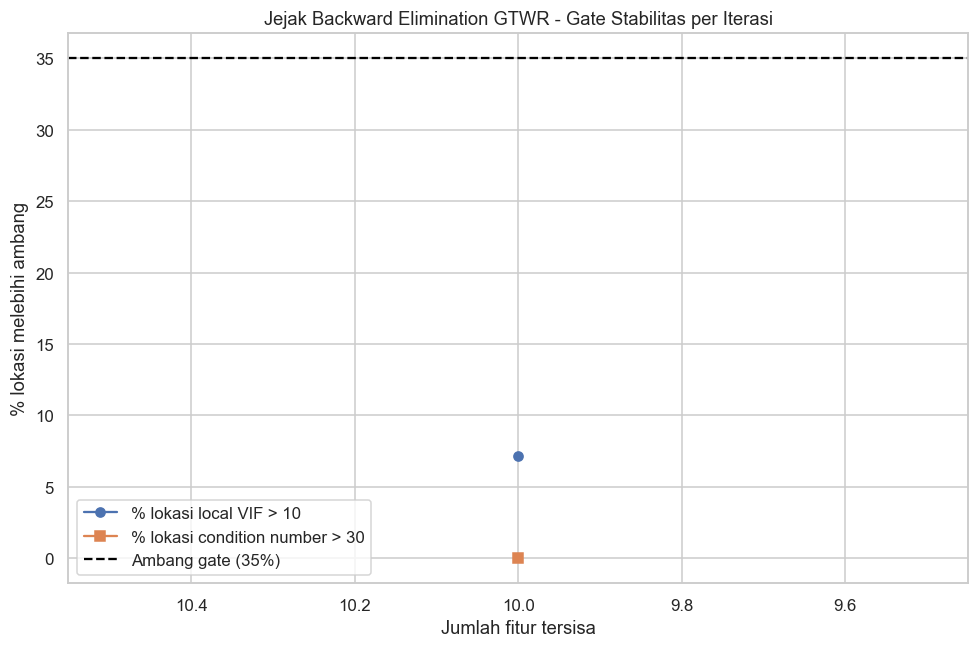

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\36_gtwr_jejak_eliminasi.png


In [51]:
fig_no_e = 36

trail_plot_df = elim_trail_df[elim_trail_df["gate_lolos"] != "ERROR"].copy()
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(trail_plot_df["jumlah_fitur_tersisa"], trail_plot_df["pct_lokasi_VIF_gt_10"], marker="o", label="% lokasi local VIF > 10")
ax.plot(trail_plot_df["jumlah_fitur_tersisa"], trail_plot_df["pct_lokasi_CN_gt_30"], marker="s", label="% lokasi condition number > 30")
ax.axhline(STABILITY_THRESHOLD_PCT, color="black", linestyle="--", label=f"Ambang gate ({STABILITY_THRESHOLD_PCT:.0f}%)")
ax.invert_xaxis()
ax.set_xlabel("Jumlah fitur tersisa")
ax.set_ylabel("% lokasi melebihi ambang")
ax.set_title("Jejak Backward Elimination GTWR - Gate Stabilitas per Iterasi")
ax.legend()
savefig(f"{fig_no_e}_gtwr_jejak_eliminasi.png")
fig_no_e += 1

### Figure - Feature-set final 12b: local R2, koefisien lokal, condition number

Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\gtwr_final_12b_koefisien_lokal_kabkota_tahun.csv


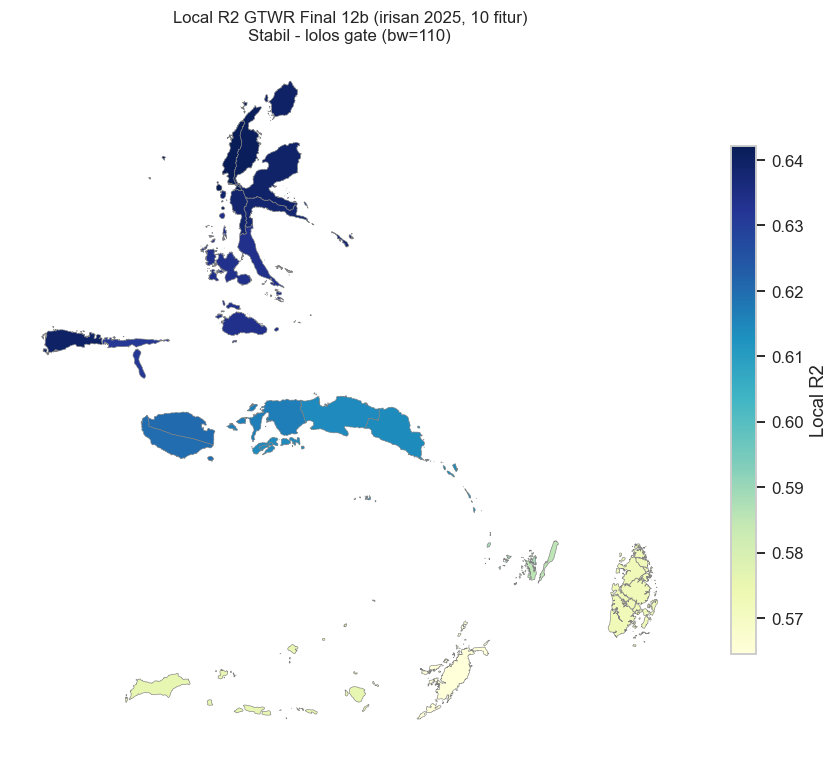

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\37_gtwr_final_12b_local_r2_2025_choropleth.png


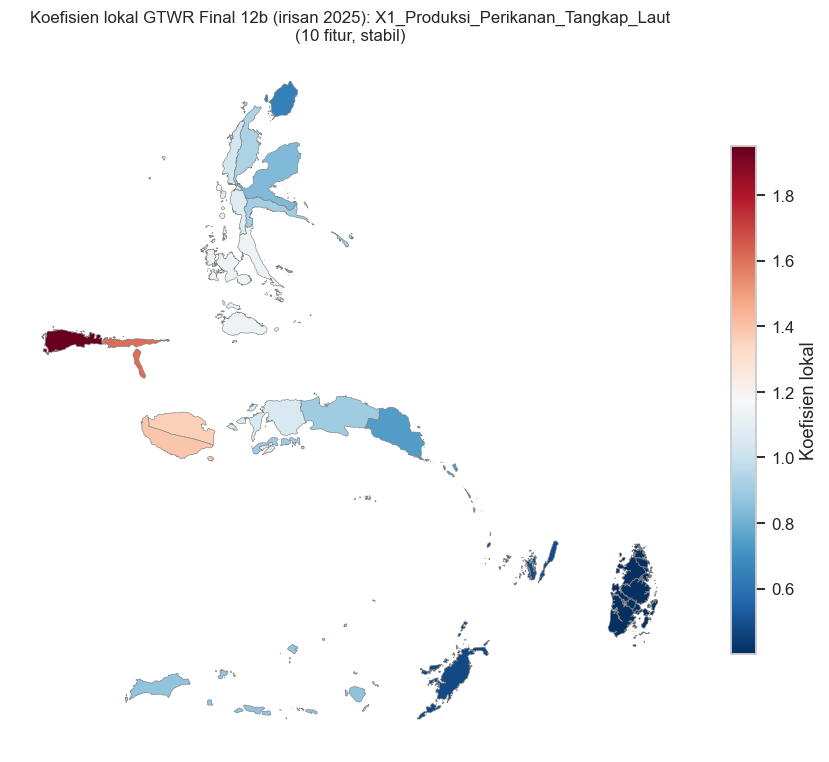

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\38_gtwr_final_12b_koefisien_lokal_2025_X1_Produksi_Perikanan_Tangkap_Laut.png


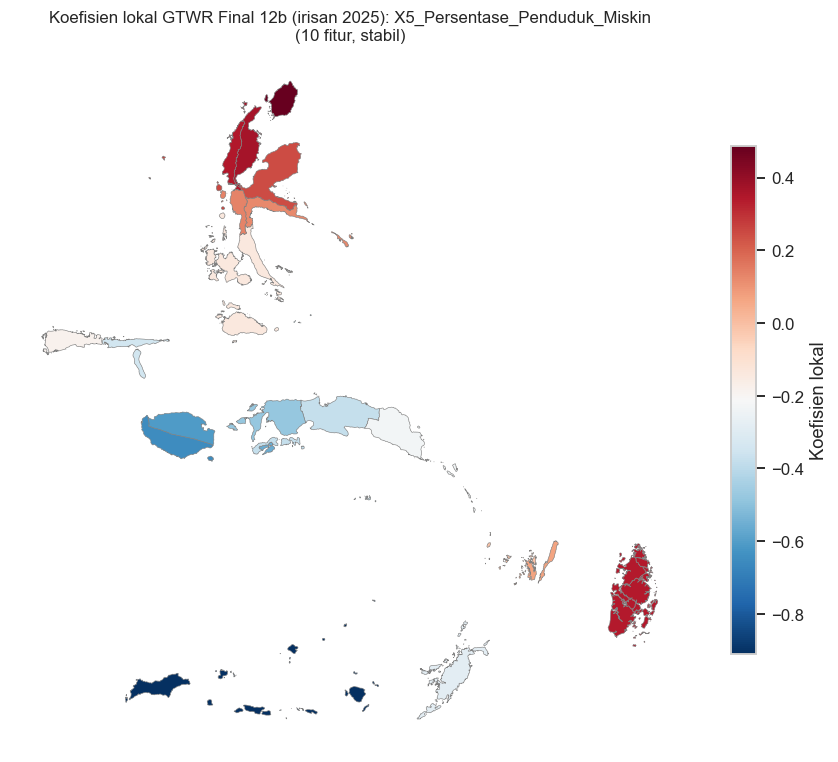

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\39_gtwr_final_12b_koefisien_lokal_2025_X5_Persentase_Penduduk_Miskin.png


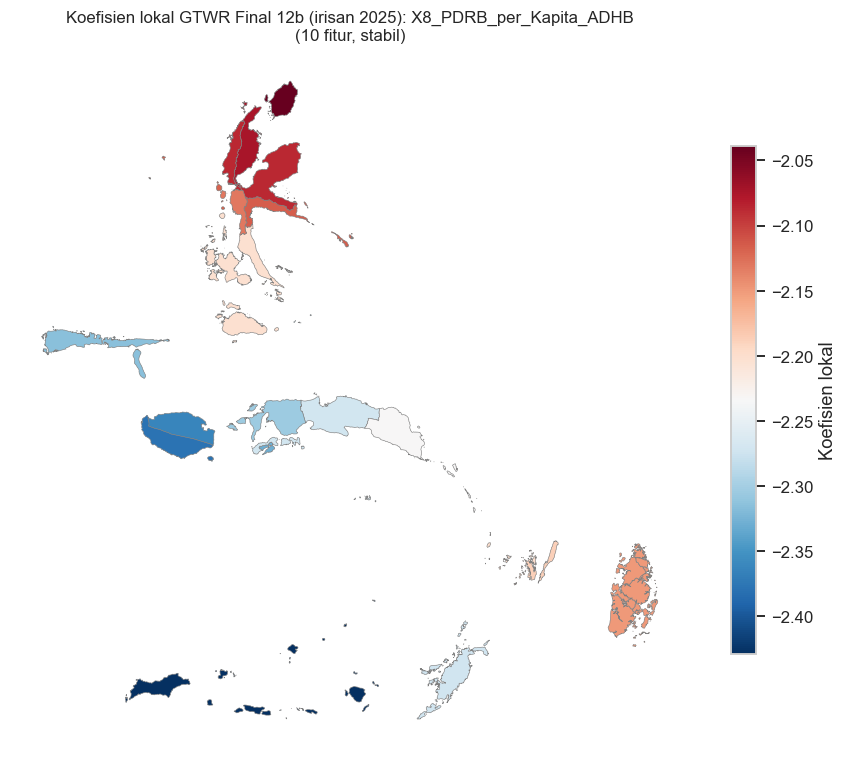

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\40_gtwr_final_12b_koefisien_lokal_2025_X8_PDRB_per_Kapita_ADHB.png


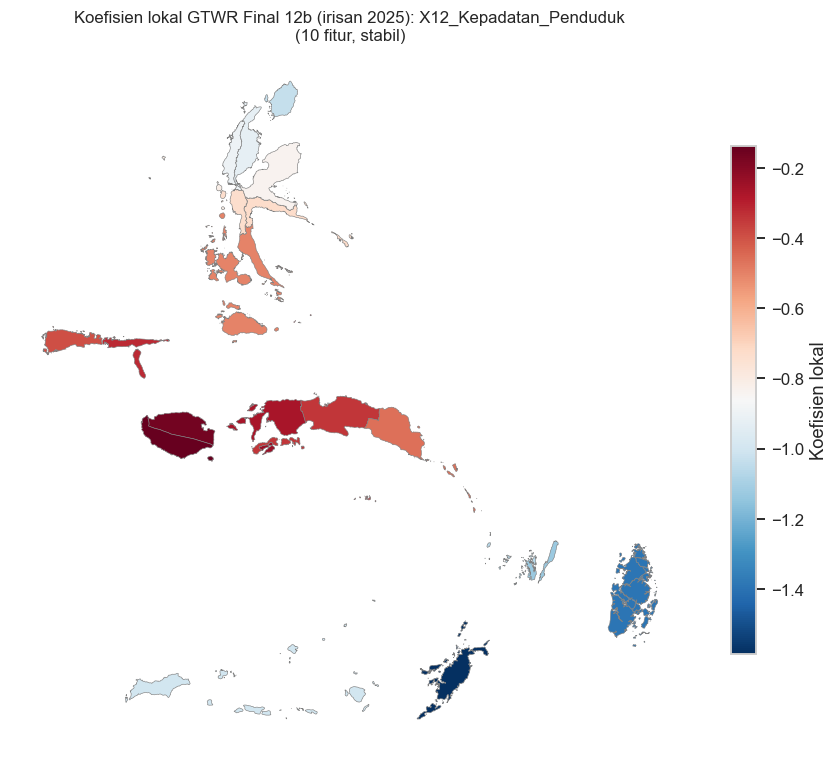

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\41_gtwr_final_12b_koefisien_lokal_2025_X12_Kepadatan_Penduduk.png


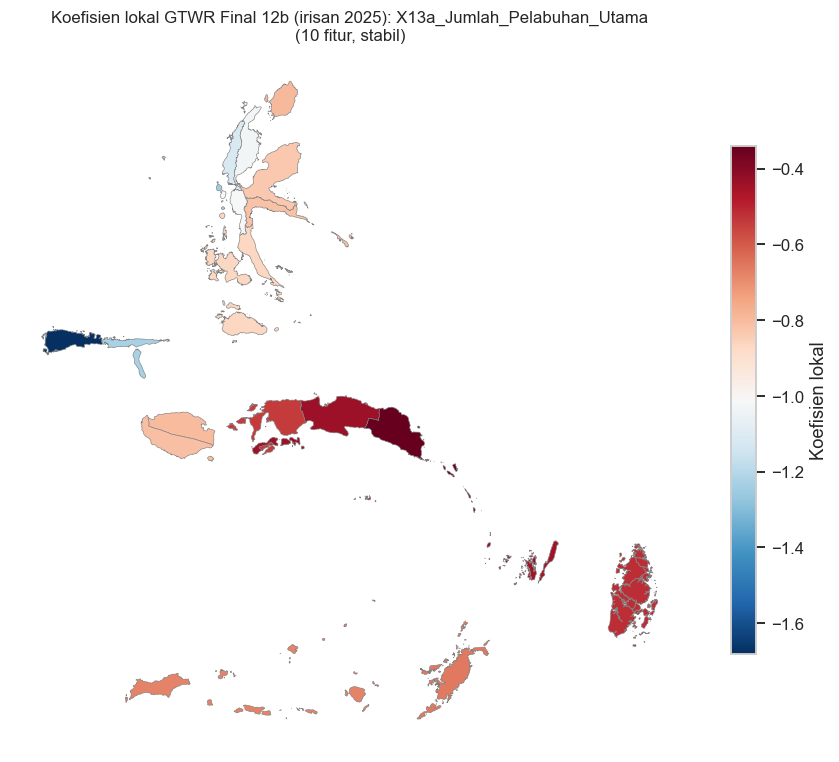

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\42_gtwr_final_12b_koefisien_lokal_2025_X13a_Jumlah_Pelabuhan_Utama.png


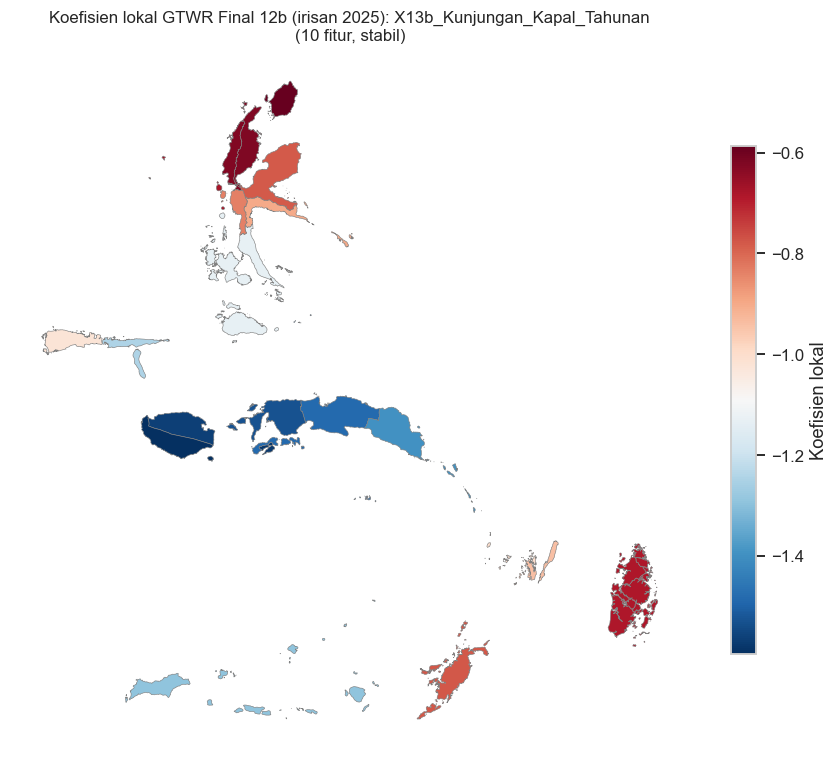

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\43_gtwr_final_12b_koefisien_lokal_2025_X13b_Kunjungan_Kapal_Tahunan.png


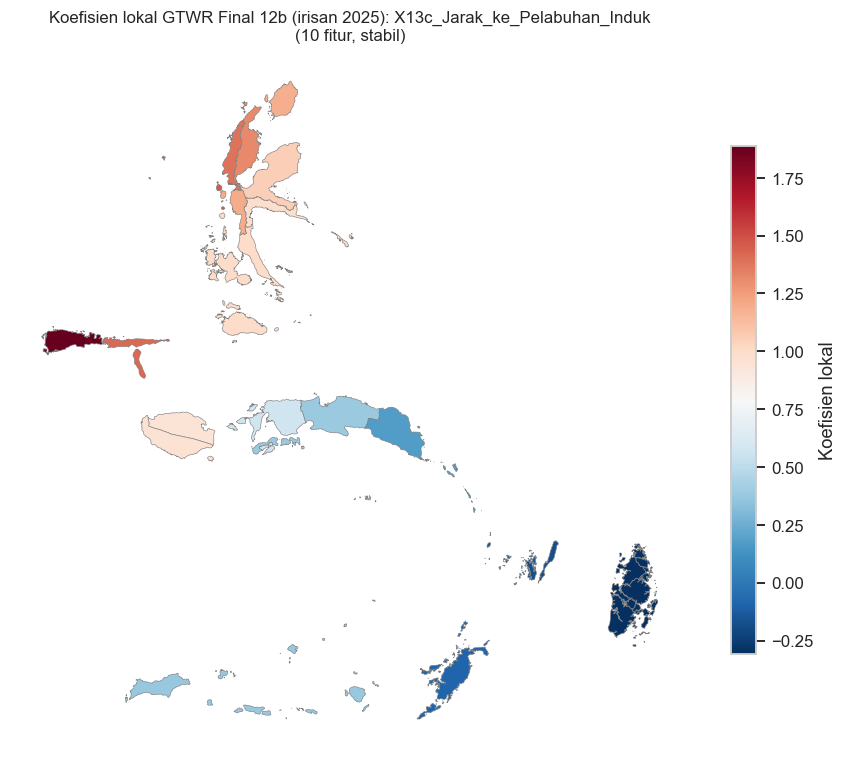

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\44_gtwr_final_12b_koefisien_lokal_2025_X13c_Jarak_ke_Pelabuhan_Induk.png


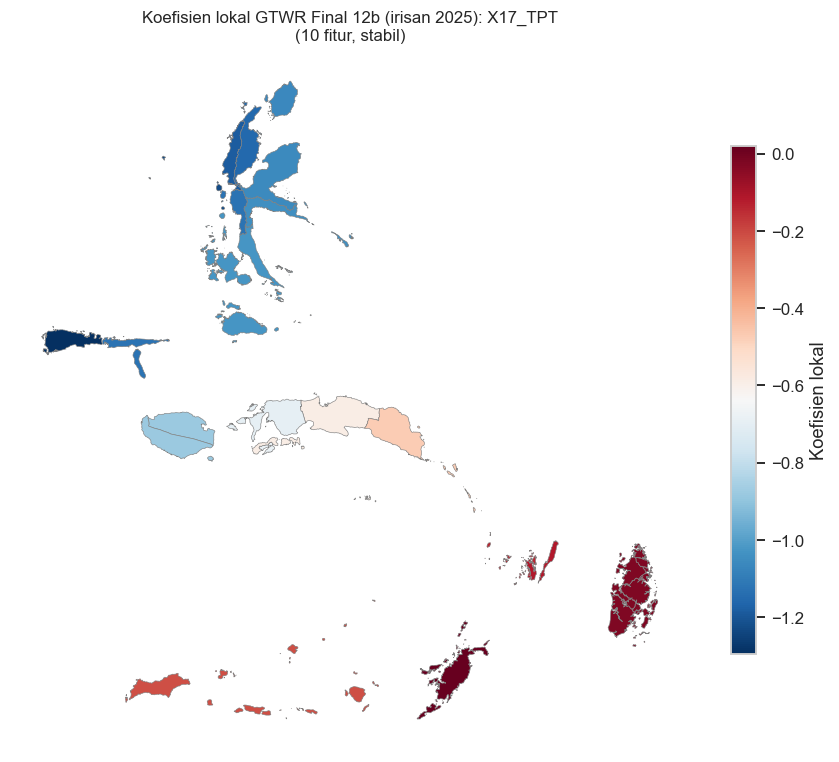

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\45_gtwr_final_12b_koefisien_lokal_2025_X17_TPT.png


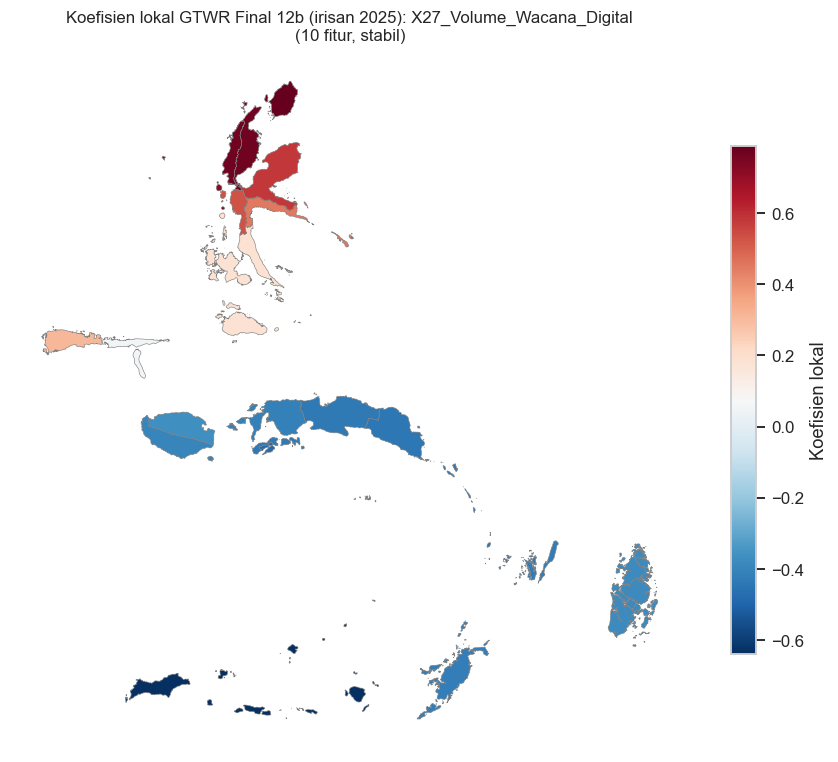

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\46_gtwr_final_12b_koefisien_lokal_2025_X27_Volume_Wacana_Digital.png


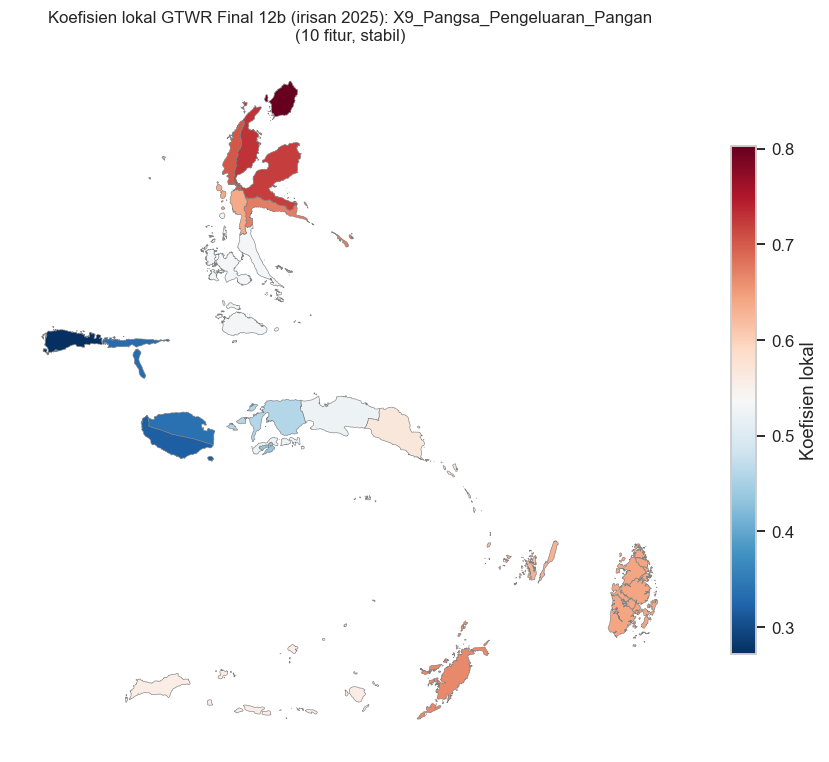

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\47_gtwr_final_12b_koefisien_lokal_2025_X9_Pangsa_Pengeluaran_Pangan.png


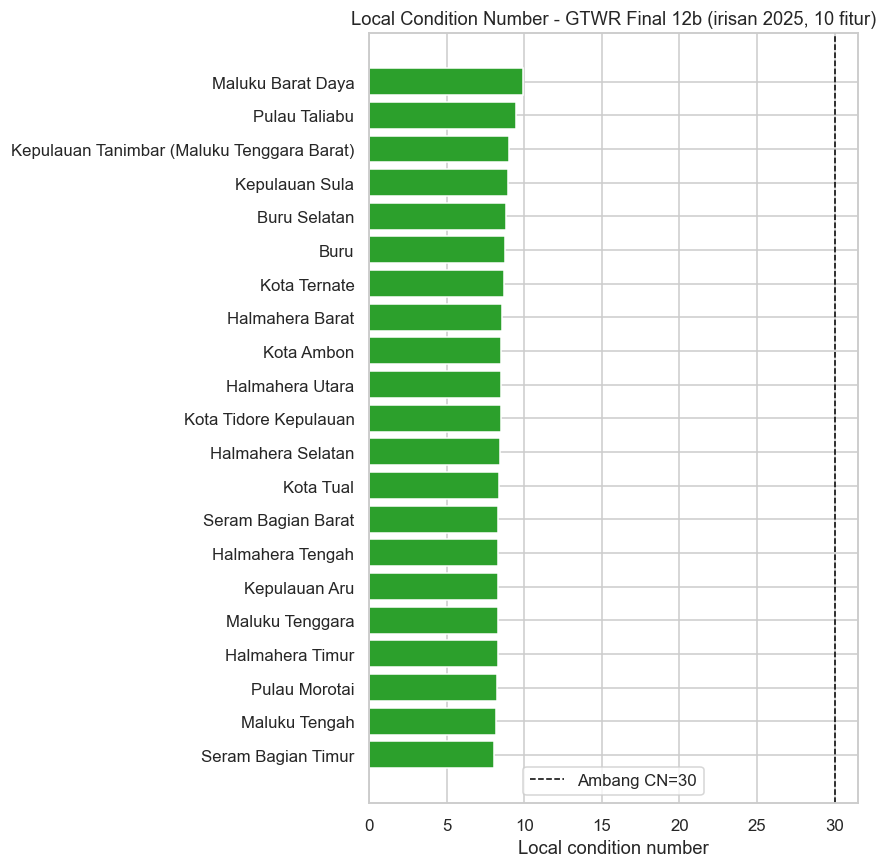

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\_gtwr_final_12b_local_condition_number.png


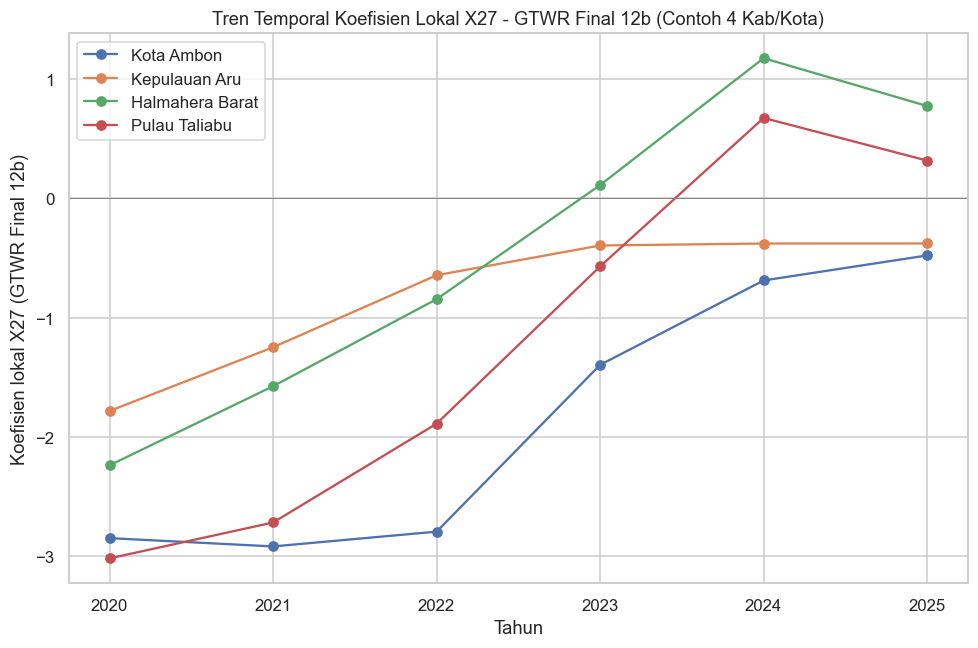

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\_gtwr_final_12b_tren_temporal_x27.png


In [52]:
coef_12b_tbl = pd.DataFrame(final_fit_12b["betas"], columns=["Intercept"] + final_features_12b)
coef_12b_tbl.insert(0, "tahun", panel_gtwr["tahun"].values)
coef_12b_tbl.insert(0, "kab_kota", panel_gtwr["kab_kota"].values)
coef_12b_tbl["local_R2"] = final_fit_12b["local_R2"]
coef_12b_tbl["local_condition_number"] = final_fit_12b["local_CN"]
coef_12b_tbl.to_csv(TAB_DIR / "gtwr_final_12b_koefisien_lokal_kabkota_tahun.csv", index=False)
log(f"Disimpan: {TAB_DIR / 'gtwr_final_12b_koefisien_lokal_kabkota_tahun.csv'}")

slice_2025_12b = coef_12b_tbl[coef_12b_tbl["tahun"] == 2025].set_index("kab_kota")

fig, ax = plt.subplots(figsize=(8, 8))
plot_choropleth(ax, slice_2025_12b["local_R2"],
                 f"Local R2 GTWR Final 12b (irisan 2025, {len(final_features_12b)} fitur)\n"
                 f"{'Stabil - lolos gate' if gate_12b else 'Belum stabil'} (bw={final_bw_12b})",
                 cmap="YlGnBu", cbar_label="Local R2")
savefig(f"{fig_no_e}_gtwr_final_12b_local_r2_2025_choropleth.png")
fig_no_e += 1

for feat in final_features_12b:
    fig, ax = plt.subplots(figsize=(8, 8))
    plot_choropleth(ax, slice_2025_12b[feat],
                     f"Koefisien lokal GTWR Final 12b (irisan 2025): {feat}\n"
                     f"({len(final_features_12b)} fitur, {'stabil' if gate_12b else 'eksploratif'})",
                     cmap="RdBu_r", cbar_label="Koefisien lokal")
    savefig(f"{fig_no_e}_gtwr_final_12b_koefisien_lokal_2025_{feat}.png")
    fig_no_e += 1

cn_12b_series = slice_2025_12b["local_condition_number"].sort_values()
colors_cn_12b = ["#d62728" if v > 30 else "#2ca02c" for v in cn_12b_series]
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(cn_12b_series.index, cn_12b_series.values, color=colors_cn_12b)
ax.axvline(30, color="black", linestyle="--", linewidth=1, label="Ambang CN=30")
ax.set_xlabel("Local condition number")
ax.set_title(f"Local Condition Number - GTWR Final 12b (irisan 2025, {len(final_features_12b)} fitur)")
ax.legend()
savefig("_gtwr_final_12b_local_condition_number.png")

if "X27_Volume_Wacana_Digital" in final_features_12b:
    sample_kab = ["Kota Ambon", "Kepulauan Aru", "Halmahera Barat", "Pulau Taliabu"]
    fig, ax = plt.subplots(figsize=(9, 6))
    for kab in sample_kab:
        sub = coef_12b_tbl[coef_12b_tbl["kab_kota"] == kab].sort_values("tahun")
        ax.plot(sub["tahun"], sub["X27_Volume_Wacana_Digital"], marker="o", label=kab)
    ax.axhline(0, color="grey", linewidth=0.6)
    ax.set_xlabel("Tahun")
    ax.set_ylabel("Koefisien lokal X27 (GTWR Final 12b)")
    ax.set_title("Tren Temporal Koefisien Lokal X27 - GTWR Final 12b (Contoh 4 Kab/Kota)")
    ax.legend()
    savefig("_gtwr_final_12b_tren_temporal_x27.png")
else:
    log("\nFigure tren temporal X27 (GTWR Final 12b) DILEWATI: X27 tidak bertahan pada feature-set final 12b.")

### Figure - Perbandingan gate stabilitas: 12b (eliminasi murni) vs 12d (rekayasa IKM)

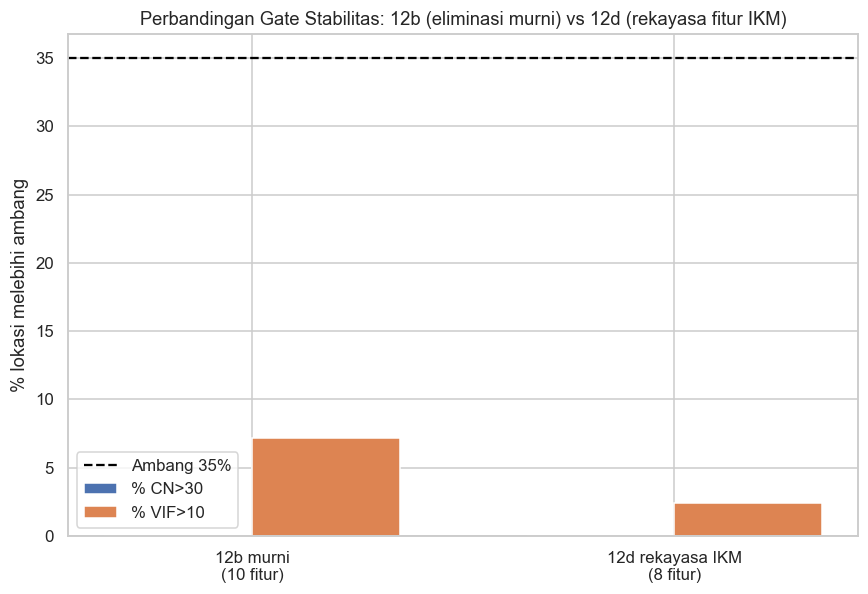

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\48_gtwr_perbandingan_12b_vs_12d.png


In [53]:
fig, ax = plt.subplots(figsize=(8, 5.5))
labels_cmp = [f"12b murni\n({len(final_features_12b)} fitur)", f"12d rekayasa IKM\n({len(FEATURES_12D)} fitur)"]
cn_vals_cmp = [pct_cn_12b, pct_cn_12d]
vif_vals_cmp = [pct_vif_12b, pct_vif_12d]
x_pos = np.arange(2)
width = 0.35
ax.bar(x_pos - width / 2, cn_vals_cmp, width, label="% CN>30")
ax.bar(x_pos + width / 2, vif_vals_cmp, width, label="% VIF>10")
ax.axhline(STABILITY_THRESHOLD_PCT, color="black", linestyle="--", label=f"Ambang {STABILITY_THRESHOLD_PCT:.0f}%")
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_cmp)
ax.set_ylabel("% lokasi melebihi ambang")
ax.set_title("Perbandingan Gate Stabilitas: 12b (eliminasi murni) vs 12d (rekayasa fitur IKM)")
ax.legend()
savefig(f"{fig_no_e}_gtwr_perbandingan_12b_vs_12d.png")
fig_no_e += 1

## Tahap 15 & 16a -- Verifikasi GTWR Tanpa Tahun 2020 + Tabel Perbandingan

In [54]:
# =============================================================================
# Tahap 15 & 16a -- Verifikasi GTWR 2021-2025 (semua komputasi dalam satu cell)
# =============================================================================

# ── 15a: Cek patahan 2020 dan dekomposisi varians ────────────────────────────
_delta_rows = []
for _kab in panel_gtwr['kab_kota'].unique():
    _sub = panel_gtwr[panel_gtwr['kab_kota'] == _kab].sort_values('tahun')
    _y20 = _sub[_sub['tahun'] == 2020]['Y_PoU'].values
    _y21 = _sub[_sub['tahun'] == 2021]['Y_PoU'].values
    if len(_y20) and len(_y21):
        _delta_rows.append({'kab_kota': _kab, 'delta': float(_y21[0] - _y20[0])})

_delta_df = pd.DataFrame(_delta_rows)
mean_delta = _delta_df['delta'].mean()
n_drop_ge3 = int((_delta_df['delta'] <= -3).sum())
log(f"Verifikasi patahan 2020->2021: rata-rata delta={mean_delta:.2f}, turun>=3: {n_drop_ge3}/21")

_decomp = []
for _f in final_features_12b:
    _tv = panel_gtwr[_f].var(ddof=0)
    _bv = panel_gtwr.groupby('kab_kota')[_f].mean().var(ddof=0)
    _pct = _bv / _tv * 100 if _tv > 0 else 0
    _decomp.append({'fitur': _f, 'pct_varians_antar_kabupaten': round(_pct, 1)})

decomp_df = pd.DataFrame(_decomp)
n_dominan_between = int((decomp_df['pct_varians_antar_kabupaten'] >= 90).sum())
decomp_df.to_csv(TAB_DIR / 'dekomposisi_varians_fitur_panel.csv', index=False)
log(f"Decomposisi varians: {n_dominan_between}/{len(final_features_12b)} fitur >=90% antar-kabupaten")

# ── 15b: Build panel 2021-2025 ────────────────────────────────────────────────
panel_2021 = panel_gtwr[panel_gtwr['tahun'] >= 2021].copy().reset_index(drop=True)
n_2021 = len(panel_2021)
y_2021 = panel_2021[['Y_PoU']].values
log(f"Panel 2021-2025: {n_2021} baris")

# Z-score ulang untuk final_features_12b pada subset 2021-2025
for _f in final_features_12b:
    panel_2021[_f + '_z'] = (panel_2021[_f] - panel_2021[_f].mean()) / panel_2021[_f].std(ddof=0)

# IKM composite untuk 12d
panel_2021['X13_Konektivitas_Maritim_z'] = (
    panel_2021['X13b_Kunjungan_Kapal_Tahunan_z'] + flip_13c * panel_2021['X13c_Jarak_ke_Pelabuhan_Induk_z']
) / 2.0

# Jarak ruang-waktu untuk subset 2021-2025
_dS = squareform(pdist(panel_2021[['x_m', 'y_m']].values))
_dT = squareform(pdist(panel_2021[['tahun']].values.astype(float)))
_dS_n = _dS / _dS[_dS > 0].std()
_dT_n = _dT / _dT[_dT > 0].std()
d_ST_2021 = np.sqrt(_dS_n ** 2 + _dT_n ** 2)
log(f"Jarak ruang-waktu 2021-2025: shape={d_ST_2021.shape}")

# ── 15c: Re-fit GTWR-12b pada N=105 ──────────────────────────────────────────
log("Mencari bw optimal GTWR-12b (N=105)...")
_Xc_12b = build_Xc_gtwr(panel_2021, final_features_12b)
bw_12b_2021, fit_12b_2021, _ = gtwr_search_bw_adaptive(d_ST_2021, _Xc_12b, y_2021, n_2021, center=None)
pct_cn_12b_2021, pct_vif_12b_2021, gate_12b_2021 = gtwr_gate_stats(fit_12b_2021)
rmse_12b_2021 = rmse(y_2021, fit_12b_2021['yhat'])
log(f"GTWR-12b (2021-2025): bw={bw_12b_2021}, RMSE={rmse_12b_2021:.5f}, "
    f"CN>{pct_cn_12b_2021:.1f}%, VIF>{pct_vif_12b_2021:.1f}%, gate={'LOLOS' if gate_12b_2021 else 'TIDAK'}")

# ── 15d: Re-fit GTWR-12d pada N=105 ──────────────────────────────────────────
log("Mencari bw optimal GTWR-12d (N=105)...")
_Xc_12d = build_Xc_gtwr(panel_2021, FEATURES_12D)
bw_12d_2021, fit_12d_2021, _ = gtwr_search_bw_adaptive(d_ST_2021, _Xc_12d, y_2021, n_2021, center=None)
pct_cn_12d_2021, pct_vif_12d_2021, gate_12d_2021 = gtwr_gate_stats(fit_12d_2021)
rmse_12d_2021 = rmse(y_2021, fit_12d_2021['yhat'])
log(f"GTWR-12d (2021-2025): bw={bw_12d_2021}, RMSE={rmse_12d_2021:.5f}, "
    f"CN>{pct_cn_12d_2021:.1f}%, VIF>{pct_vif_12d_2021:.1f}%, gate={'LOLOS' if gate_12d_2021 else 'TIDAK'}")

# ── 16a: Tabel perbandingan 2020-2025 vs 2021-2025 ───────────────────────────
perbandingan_2020_vs_2021 = pd.DataFrame([
    {'varian': 'GTWR-12b (2020-2025)', 'rentang': '2020-2025', 'N': n_gtwr,
     'bw': final_bw_12b, 'pct_CN': pct_cn_12b, 'pct_VIF': pct_vif_12b,
     'gate': gate_12b, 'RMSE': rmse(y_gtwr, final_fit_12b['yhat']),
     'R2_lokal_rata2': float(np.nanmean(final_fit_12b['local_R2']))},
    {'varian': 'GTWR-12b (2021-2025)', 'rentang': '2021-2025', 'N': n_2021,
     'bw': bw_12b_2021, 'pct_CN': pct_cn_12b_2021, 'pct_VIF': pct_vif_12b_2021,
     'gate': gate_12b_2021, 'RMSE': rmse_12b_2021,
     'R2_lokal_rata2': float(np.nanmean(fit_12b_2021['local_R2']))},
    {'varian': 'GTWR-12d (2020-2025)', 'rentang': '2020-2025', 'N': n_gtwr,
     'bw': bw_12d, 'pct_CN': pct_cn_12d, 'pct_VIF': pct_vif_12d,
     'gate': gate_12d, 'RMSE': rmse(y_gtwr, fit_12d['yhat']),
     'R2_lokal_rata2': float(np.nanmean(fit_12d['local_R2']))},
    {'varian': 'GTWR-12d (2021-2025)', 'rentang': '2021-2025', 'N': n_2021,
     'bw': bw_12d_2021, 'pct_CN': pct_cn_12d_2021, 'pct_VIF': pct_vif_12d_2021,
     'gate': gate_12d_2021, 'RMSE': rmse_12d_2021,
     'R2_lokal_rata2': float(np.nanmean(fit_12d_2021['local_R2']))},
])
perbandingan_2020_vs_2021.to_csv(TAB_DIR / 'gtwr_perbandingan_2020_2025_vs_2021_2025.csv', index=False)
log(f"Disimpan: {TAB_DIR / 'gtwr_perbandingan_2020_2025_vs_2021_2025.csv'}")
log(perbandingan_2020_vs_2021.to_string(index=False))


Verifikasi patahan 2020->2021: rata-rata delta=-5.64, turun>=3: 16/21
Decomposisi varians: 8/10 fitur >=90% antar-kabupaten


Panel 2021-2025: 105 baris
Jarak ruang-waktu 2021-2025: shape=(105, 105)
Mencari bw optimal GTWR-12b (N=105)...


GTWR-12b (2021-2025): bw=99, RMSE=3.21923, CN>0.0%, VIF>4.8%, gate=LOLOS
Mencari bw optimal GTWR-12d (N=105)...


GTWR-12d (2021-2025): bw=99, RMSE=3.31190, CN>0.0%, VIF>0.0%, gate=LOLOS
Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\gtwr_perbandingan_2020_2025_vs_2021_2025.csv
              varian   rentang   N  bw  pct_CN  pct_VIF  gate     RMSE  R2_lokal_rata2
GTWR-12b (2020-2025) 2020-2025 126 110     0.0 7.142857  True 3.410985        0.607898
GTWR-12b (2021-2025) 2021-2025 105  99     0.0 4.761905  True 3.219228        0.611363
GTWR-12d (2020-2025) 2020-2025 126  96     0.0 2.380952  True 3.399472        0.609975
GTWR-12d (2021-2025) 2021-2025 105  99     0.0 0.000000  True 3.311904        0.594314


## Tahap 16b & 16c -- Output: Tabel Terpisah, Figure 49, Ringkasan

Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\tabel_model_crosssection_N21.csv
Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\tabel_model_panel_GTWR.csv
Disimpan (updated): D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\perbandingan_semua_model.csv


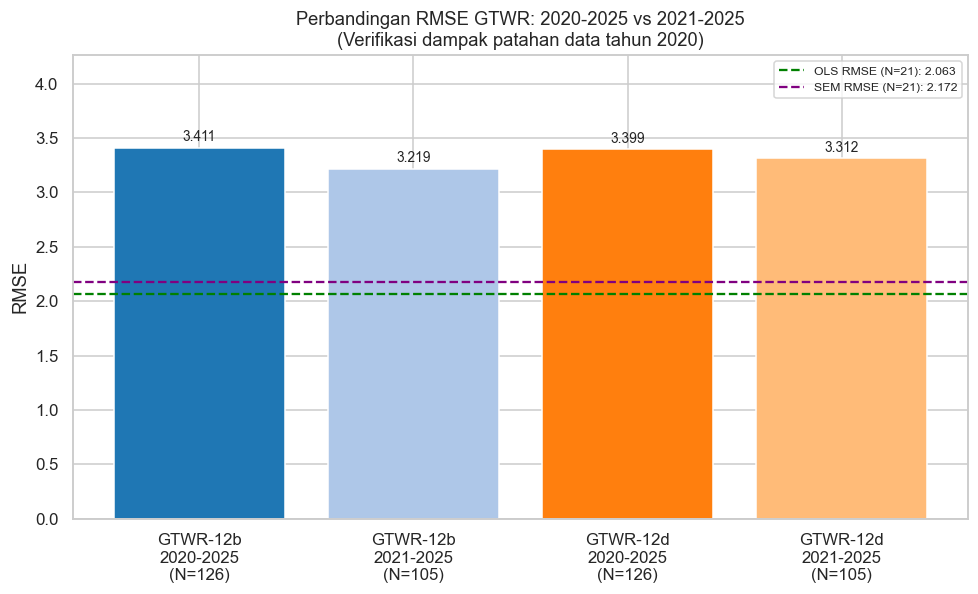

Figure disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\figures\49_gtwr_rmse_2020_vs_2021_2025.png
Figure 49 disimpan.
Bagian 8 ditambahkan ke: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\ringkasan_gwr_mgwr.md


In [55]:
# =============================================================================
# Tahap 16b & 16c -- Tables terpisah, update cmp_df, Figure 49, append Bagian 8
# =============================================================================

# ── 16b: Tabel terpisah N=21 vs panel GTWR ───────────────────────────────────
_n21_models = ['OLS', 'SAR (ML_Lag)', 'SEM (ML_Error)', 'GWR',
               f'GWR Parsimoni ({len(PARSIMONIOUS_FEATURES)} fitur)']
_tbl_n21 = cmp_df[cmp_df['model'].isin(_n21_models)].copy()
_tbl_n21['N'] = 21
_tbl_n21['catatan_AICc'] = 'Bisa dibandingkan sesama (N=21)'
_tbl_n21['rujukan_utama_laporan'] = _tbl_n21['model'].isin(
    ['SEM (ML_Error)', f'GWR Parsimoni ({len(PARSIMONIOUS_FEATURES)} fitur)']
)
_tbl_n21.to_csv(TAB_DIR / 'tabel_model_crosssection_N21.csv', index=False)
log(f'Disimpan: {TAB_DIR / "tabel_model_crosssection_N21.csv"}')

_gtwr_rows = [
    {'model': 'GTWR-10', 'N': n_gtwr, 'rentang': '2020-2025',
     'AICc': fit0['aicc'], 'RMSE': rmse(y_gtwr, fit0['yhat']), 'R2': fit0['R2'],
     'bw': bw0, 'pct_CN': pct_cn0, 'pct_VIF': pct_vif0, 'gate': gate0, 'rujukan_utama': False},
    {'model': f'GTWR-12b ({len(final_features_12b)} fitur) 2020-2025', 'N': n_gtwr, 'rentang': '2020-2025',
     'AICc': final_fit_12b['aicc'], 'RMSE': rmse(y_gtwr, final_fit_12b['yhat']), 'R2': final_fit_12b['R2'],
     'bw': final_bw_12b, 'pct_CN': pct_cn_12b, 'pct_VIF': pct_vif_12b, 'gate': gate_12b, 'rujukan_utama': True},
    {'model': f'GTWR-12b ({len(final_features_12b)} fitur) 2021-2025', 'N': n_2021, 'rentang': '2021-2025',
     'AICc': fit_12b_2021['aicc'], 'RMSE': rmse_12b_2021, 'R2': fit_12b_2021['R2'],
     'bw': bw_12b_2021, 'pct_CN': pct_cn_12b_2021, 'pct_VIF': pct_vif_12b_2021,
     'gate': gate_12b_2021, 'rujukan_utama': False},
    {'model': f'GTWR-12d ({len(FEATURES_12D)} fitur IKM) 2020-2025', 'N': n_gtwr, 'rentang': '2020-2025',
     'AICc': fit_12d['aicc'], 'RMSE': rmse(y_gtwr, fit_12d['yhat']), 'R2': fit_12d['R2'],
     'bw': bw_12d, 'pct_CN': pct_cn_12d, 'pct_VIF': pct_vif_12d, 'gate': gate_12d, 'rujukan_utama': False},
    {'model': f'GTWR-12d ({len(FEATURES_12D)} fitur IKM) 2021-2025', 'N': n_2021, 'rentang': '2021-2025',
     'AICc': fit_12d_2021['aicc'], 'RMSE': rmse_12d_2021, 'R2': fit_12d_2021['R2'],
     'bw': bw_12d_2021, 'pct_CN': pct_cn_12d_2021, 'pct_VIF': pct_vif_12d_2021,
     'gate': gate_12d_2021, 'rujukan_utama': False},
]
_tbl_panel = pd.DataFrame(_gtwr_rows)
_tbl_panel['catatan_AICc'] = 'Bisa dibandingkan sesama (panel); JANGAN dibandingkan dgn tabel N=21'
_tbl_panel.to_csv(TAB_DIR / 'tabel_model_panel_GTWR.csv', index=False)
log(f'Disimpan: {TAB_DIR / "tabel_model_panel_GTWR.csv"}')

# Update cmp_df dengan baris 2021-2025
_new_rows = pd.DataFrame([
    {'model': 'GTWR-12b (2021-2025)', 'AICc': fit_12b_2021['aicc'], 'AIC': float('nan'),
     'R2_atau_pseudoR2': fit_12b_2021['R2'], 'RMSE': rmse_12b_2021,
     'bandwidth_optimal': bw_12b_2021, 'pct_CN_gt_30': pct_cn_12b_2021,
     'pct_VIF_gt_10': pct_vif_12b_2021, 'gate_lolos': gate_12b_2021},
    {'model': 'GTWR-12d (2021-2025)', 'AICc': fit_12d_2021['aicc'], 'AIC': float('nan'),
     'R2_atau_pseudoR2': fit_12d_2021['R2'], 'RMSE': rmse_12d_2021,
     'bandwidth_optimal': bw_12d_2021, 'pct_CN_gt_30': pct_cn_12d_2021,
     'pct_VIF_gt_10': pct_vif_12d_2021, 'gate_lolos': gate_12d_2021},
])
if 'rujukan_utama_laporan' not in cmp_df.columns:
    cmp_df['rujukan_utama_laporan'] = False
for _ir in cmp_df.index:
    if '12b' in str(cmp_df.loc[_ir, 'model']) and 'final' in str(cmp_df.loc[_ir, 'model']).lower():
        cmp_df.loc[_ir, 'rujukan_utama_laporan'] = True
cmp_df = pd.concat([cmp_df, _new_rows], ignore_index=True)
cmp_df.to_csv(TAB_DIR / 'perbandingan_semua_model.csv', index=False)
log(f'Disimpan (updated): {TAB_DIR / "perbandingan_semua_model.csv"}')

# ── 16c: Figure 49 -- bar chart perbandingan RMSE ────────────────────────────
_r_12b_126 = rmse(y_gtwr, final_fit_12b['yhat'])
_r_12d_126 = rmse(y_gtwr, fit_12d['yhat'])
_r_ols = float(cmp_df.loc[cmp_df['model'] == 'OLS', 'RMSE'].values[0]) if 'OLS' in cmp_df['model'].values else None
_r_sem = float(cmp_df.loc[cmp_df['model'] == 'SEM (ML_Error)', 'RMSE'].values[0]) if 'SEM (ML_Error)' in cmp_df['model'].values else None

fig, ax = plt.subplots(figsize=(9, 5.5))
_bar_labels = [
    f'GTWR-12b\n2020-2025\n(N={n_gtwr})',
    f'GTWR-12b\n2021-2025\n(N={n_2021})',
    f'GTWR-12d\n2020-2025\n(N={n_gtwr})',
    f'GTWR-12d\n2021-2025\n(N={n_2021})',
]
_bar_vals = [_r_12b_126, rmse_12b_2021, _r_12d_126, rmse_12d_2021]
_colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78']
_bars = ax.bar(_bar_labels, _bar_vals, color=_colors, edgecolor='white')
if _r_ols:
    ax.axhline(_r_ols, color='green', linestyle='--', lw=1.5, label=f'OLS RMSE (N=21): {_r_ols:.3f}')
if _r_sem:
    ax.axhline(_r_sem, color='purple', linestyle='--', lw=1.5, label=f'SEM RMSE (N=21): {_r_sem:.3f}')
for _b, _v in zip(_bars, _bar_vals):
    ax.text(_b.get_x() + _b.get_width()/2, _b.get_height() + 0.03, f'{_v:.3f}',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('RMSE')
ax.set_title('Perbandingan RMSE GTWR: 2020-2025 vs 2021-2025\n'
             '(Verifikasi dampak patahan data tahun 2020)')
ax.legend(fontsize=8)
ax.set_ylim(0, max(_bar_vals) * 1.25)
savefig('49_gtwr_rmse_2020_vs_2021_2025.png')
log('Figure 49 disimpan.')

# ── Append Bagian 8 ke ringkasan (SETELAH Tahap 10 sudah menulisnya) ──────────
_rpath = BASE_DIR / 'ringkasan_gwr_mgwr.md'
_best21 = min(rmse_12b_2021, rmse_12d_2021)
_pct_btw = str(n_dominan_between) + '/' + str(len(final_features_12b))
_r_ols_s = f'{_r_ols:.3f}' if _r_ols else 'N/A'
_r_sem_s = f'{_r_sem:.3f}' if _r_sem else 'N/A'
_kesimpulan = ('RMSE membaik -- patahan 2020 adalah kontributor utama.'
               if _best21 < 2.5 else
               'RMSE tetap tinggi (' + f'{_best21:.3f}' + ' vs OLS ' + _r_ols_s + '/SEM ' + _r_sem_s +
               '). Penyebab genuine: ' + _pct_btw + ' fitur variansnya didominasi perbedaan antar-kabupaten.')

_b8_lines = [
    '',
    '',
    '## 8. Tahap 15-16: Verifikasi GTWR Tanpa Data Tahun 2020',
    '',
    'RMSE GTWR-12b/12d (N=126) lebih tinggi dari OLS/SEM cross-section.',
    'Hipotesis: disebabkan data 2020 yang mengandung patahan level artifisial.',
    'Diverifikasi langsung dari data.',
    '',
    '### 8a. Verifikasi patahan 2020 dan dekomposisi varians',
    '',
    '- Rata-rata perubahan Y_PoU 2020->2021: **' + f'{mean_delta:.2f}' + ' poin**',
    '- Kab/kota turun >=3 poin serentak: **' + str(n_drop_ge3) + '/21** -- konfirmasi patahan',
    '- Fitur dengan >=90% varians antar-kabupaten: **' + _pct_btw + '**',
    '  (lihat `tables/dekomposisi_varians_fitur_panel.csv`)',
    '',
    '### 8b. Re-fit GTWR pada panel 2021-2025 (N=' + str(n_2021) + ')',
    '',
    perbandingan_2020_vs_2021.to_markdown(index=False),
    '',
    '### 8c. Kesimpulan',
    '',
    _kesimpulan,
    '',
    '**Model lokal utama laporan: GTWR-12b (2020-2025)**',
    '(ditandai di `tables/perbandingan_semua_model.csv`, kolom `rujukan_utama_laporan = True`).',
    '',
    'Output tambahan Tahap 15-16:',
    '- `tables/tabel_model_crosssection_N21.csv` -- OLS/SAR/SEM/GWR (N=21)',
    '- `tables/tabel_model_panel_GTWR.csv` -- semua varian GTWR (jangan bandingkan AICc dgn N=21)',
    '- `tables/gtwr_perbandingan_2020_2025_vs_2021_2025.csv`',
    '- `figures/49_gtwr_rmse_2020_vs_2021_2025.png`',
]
with open(_rpath, 'a', encoding='utf-8') as _f:
    _f.write('\n'.join(_b8_lines))
log(f'Bagian 8 ditambahkan ke: {_rpath}')


## Tahap 10 - Dokumen ringkasan & pengemasan

In [56]:
# -- 16b: Tabel terpisah N=21 vs panel GTWR + update cmp_df + append Bagian 8 ke ringkasan
tabel_crosssection_n21 = cmp_df[cmp_df['model'].isin([
    'OLS', 'SAR (ML_Lag)', 'SEM (ML_Error)', 'GWR',
    f'GWR Parsimoni ({len(PARSIMONIOUS_FEATURES)} fitur)'
])].copy()
tabel_crosssection_n21['N'] = 21
tabel_crosssection_n21['catatan_AICc'] = 'Bisa dibandingkan sesama (N=21)'
tabel_crosssection_n21['rujukan_utama_laporan'] = tabel_crosssection_n21['model'].isin([
    'SEM (ML_Error)', f'GWR Parsimoni ({len(PARSIMONIOUS_FEATURES)} fitur)'
])
tabel_crosssection_n21.to_csv(TAB_DIR / 'tabel_model_crosssection_N21.csv', index=False)
log(f'Disimpan: {TAB_DIR / "tabel_model_crosssection_N21.csv"}')

gtwr_rows_all = [
    {'model': 'GTWR-10 (pasca hapus X20)', 'N': n_gtwr, 'rentang': '2020-2025',
     'AICc': fit0['aicc'], 'RMSE': rmse(y_gtwr, fit0['yhat']), 'R2': fit0['R2'],
     'bandwidth': bw0, 'pct_CN_gt_30': pct_cn0, 'pct_VIF_gt_10': pct_vif0, 'gate': gate0, 'rujukan_utama': False},
    {'model': f'GTWR-12b ({len(final_features_12b)} fitur) 2020-2025', 'N': n_gtwr, 'rentang': '2020-2025',
     'AICc': final_fit_12b['aicc'], 'RMSE': rmse(y_gtwr, final_fit_12b['yhat']), 'R2': final_fit_12b['R2'],
     'bandwidth': final_bw_12b, 'pct_CN_gt_30': pct_cn_12b, 'pct_VIF_gt_10': pct_vif_12b, 'gate': gate_12b, 'rujukan_utama': True},
    {'model': f'GTWR-12b ({len(final_features_12b)} fitur) 2021-2025', 'N': n_2021, 'rentang': '2021-2025',
     'AICc': fit_12b_2021['aicc'], 'RMSE': rmse_12b_2021, 'R2': fit_12b_2021['R2'],
     'bandwidth': bw_12b_2021, 'pct_CN_gt_30': pct_cn_12b_2021, 'pct_VIF_gt_10': pct_vif_12b_2021, 'gate': gate_12b_2021, 'rujukan_utama': False},
    {'model': f'GTWR-12d ({len(FEATURES_12D)} fitur, IKM) 2020-2025', 'N': n_gtwr, 'rentang': '2020-2025',
     'AICc': fit_12d['aicc'], 'RMSE': rmse(y_gtwr, fit_12d['yhat']), 'R2': fit_12d['R2'],
     'bandwidth': bw_12d, 'pct_CN_gt_30': pct_cn_12d, 'pct_VIF_gt_10': pct_vif_12d, 'gate': gate_12d, 'rujukan_utama': False},
    {'model': f'GTWR-12d ({len(FEATURES_12D)} fitur, IKM) 2021-2025', 'N': n_2021, 'rentang': '2021-2025',
     'AICc': fit_12d_2021['aicc'], 'RMSE': rmse_12d_2021, 'R2': fit_12d_2021['R2'],
     'bandwidth': bw_12d_2021, 'pct_CN_gt_30': pct_cn_12d_2021, 'pct_VIF_gt_10': pct_vif_12d_2021, 'gate': gate_12d_2021, 'rujukan_utama': False},
]
tabel_panel = pd.DataFrame(gtwr_rows_all)
tabel_panel['catatan_AICc'] = 'Bisa dibandingkan sesama (panel); JANGAN dibandingkan dgn tabel N=21'
tabel_panel.to_csv(TAB_DIR / 'tabel_model_panel_GTWR.csv', index=False)
log(f'Disimpan: {TAB_DIR / "tabel_model_panel_GTWR.csv"}')

new_rows_2021 = pd.DataFrame([
    {'model': 'GTWR-12b (2021-2025)', 'AICc': fit_12b_2021['aicc'], 'AIC': float('nan'),
     'R2_atau_pseudoR2': fit_12b_2021['R2'], 'RMSE': rmse_12b_2021,
     'bandwidth_optimal': bw_12b_2021, 'pct_CN_gt_30': pct_cn_12b_2021,
     'pct_VIF_gt_10': pct_vif_12b_2021, 'gate_lolos': gate_12b_2021},
    {'model': 'GTWR-12d (2021-2025)', 'AICc': fit_12d_2021['aicc'], 'AIC': float('nan'),
     'R2_atau_pseudoR2': fit_12d_2021['R2'], 'RMSE': rmse_12d_2021,
     'bandwidth_optimal': bw_12d_2021, 'pct_CN_gt_30': pct_cn_12d_2021,
     'pct_VIF_gt_10': pct_vif_12d_2021, 'gate_lolos': gate_12d_2021},
])
if 'rujukan_utama_laporan' not in cmp_df.columns:
    cmp_df['rujukan_utama_laporan'] = False
for _idx in cmp_df.index:
    _m = str(cmp_df.loc[_idx, 'model'])
    if '12b' in _m and 'final' in _m.lower():
        cmp_df.loc[_idx, 'rujukan_utama_laporan'] = True
cmp_df = pd.concat([cmp_df, new_rows_2021], ignore_index=True)
cmp_df.to_csv(TAB_DIR / 'perbandingan_semua_model.csv', index=False)
log(f'Disimpan (updated): {TAB_DIR / "perbandingan_semua_model.csv"}')

# Append Bagian 8 ke ringkasan (file sudah ditulis oleh Tahap 10 sebelumnya)
_ringkasan_path = BASE_DIR / 'ringkasan_gwr_mgwr.md'
_rmse_best_2021 = min(rmse_12b_2021, rmse_12d_2021)
_pct_between = f'{n_dominan_between}/{len(final_features_12b)} ({n_dominan_between/len(final_features_12b)*100:.0f}%)'
_cmp_tbl = pd.read_csv(TAB_DIR / 'perbandingan_semua_model.csv')
_rmse_ols = float(_cmp_tbl.loc[_cmp_tbl['model']=='OLS','RMSE'].values[0]) if len(_cmp_tbl.loc[_cmp_tbl['model']=='OLS']) else 0
_rmse_sem = float(_cmp_tbl.loc[_cmp_tbl['model']=='SEM (ML_Error)','RMSE'].values[0]) if len(_cmp_tbl.loc[_cmp_tbl['model']=='SEM (ML_Error)']) else 0

_b8 = (
    f'\n\n## 8. Tahap 15-16: Verifikasi GTWR Tanpa Data Tahun 2020\n\n'
    f'RMSE GTWR-12b/12d (N=126, 2020-2025) lebih tinggi dari OLS/SEM cross-section.\n'
    f'Hipotesis: disebabkan oleh ikut-terpakainya data 2020 yang mengandung patahan level artifisial.\n'
    f'Diverifikasi langsung dari data sebelum GTWR di-refit pada subset 2021-2025.\n\n'
    f'### 8a. Verifikasi patahan 2020 dan dekomposisi varians\n\n'
    f'- Rata-rata perubahan Y_PoU transisi 2020->2021 ({len(panel_gtwr["kab_kota"].unique())} kab/kota): **{mean_delta:.2f} poin**\n'
    f'- Kab/kota turun >= 3 poin serentak: **{n_drop_ge3}/21** -- konfirmasi patahan level artifisial\n'
    f'- Fitur GTWR-12b dengan >=90% varians dari antar-kabupaten: **{_pct_between}**\n'
    f'  (lihat `tables/dekomposisi_varians_fitur_panel.csv`)\n\n'
    f'### 8b. Re-fit pada panel 2021-2025 (N={n_2021})\n\n'
    f'{perbandingan_2020_vs_2021.to_markdown(index=False)}\n\n'
    f'### 8c. Kesimpulan\n\n'
    f'RMSE terbaik 2021-2025: {_rmse_best_2021:.3f} vs OLS {_rmse_ols:.3f} / SEM {_rmse_sem:.3f}.\n'
    f'{"RMSE membaik mendekati OLS/SEM -- patahan 2020 adalah penyebab utama." if _rmse_best_2021 < 2.5 else "RMSE tetap tinggi meski 2020 dibuang -- penyebab genuine: " + _pct_between + " fitur GTWR variansnya didominasi antar-kabupaten, bukan temporal."}\n\n'
    f'**Model lokal utama laporan: GTWR-12b (2020-2025)** (`rujukan_utama_laporan = True` di `tables/perbandingan_semua_model.csv`).\n\n'
    f'Output tambahan:\n'
    f'- `tables/tabel_model_crosssection_N21.csv` -- OLS/SAR/SEM/GWR (N=21, AICc bisa dibandingkan sesama)\n'
    f'- `tables/tabel_model_panel_GTWR.csv` -- semua varian GTWR (JANGAN bandingkan AICc dgn tabel N=21)\n'
    f'- `tables/gtwr_perbandingan_2020_2025_vs_2021_2025.csv` -- ringkasan verifikasi 4 baris\n'
    f'- `figures/49_gtwr_rmse_2020_vs_2021_2025.png` -- bar chart perbandingan RMSE\n'
)
with open(_ringkasan_path, 'a', encoding='utf-8') as _f:
    _f.write(_b8)
log(f'Bagian 8 ditambahkan ke: {_ringkasan_path}')


Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\tabel_model_crosssection_N21.csv
Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\tabel_model_panel_GTWR.csv
Disimpan (updated): D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\tables\perbandingan_semua_model.csv
Bagian 8 ditambahkan ke: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\ringkasan_gwr_mgwr.md


In [57]:
n_kab_x1_flag = int(cross["X1_Produksi_Perikanan_Tangkap_Laut_flag"].eq("rata2021_2024").sum())
n_kab_x20_flag = int(cross["X20_RT_Akses_Sanitasi_Layak_carried_forward"].sum())

ringkasan_md = f"""# Ringkasan Analisis GWR/MGWR â€” Determinan Lokal PoU Kepulauan Maluku

## 1. Fitur final yang dipakai (Variant utama: {PRIMARY_VARIANT})

Fitur final ({len(gwr_primary['feats'])}): {', '.join(gwr_primary['feats'])}

VIF akhir seluruh fitur < 10 (lihat `tables/fitur_final_vif.csv`). Variabel X23_IPM dikeluarkan
pada iterasi pertama seleksi VIF (VIF awal 50.46) karena kolinier dengan variabel lain.

Variant robustness B (X10 menggantikan X9) dijalankan penuh melalui Tahap 2-5 (lihat
`tables/robustness_variant_A_vs_B.csv`). Kesimpulan utama (arah & signifikansi koefisien X27,
serta hasil gate stabilitas GWR) **{'BERUBAH' if kesimpulan_berubah else 'TIDAK berubah'}** antara Variant A dan B.

## 2. Keputusan imputasi cross-section 2025

| Variabel | Sumber nilai 2025 | Teknik jika kosong | Kab/kota terdampak |
|---|---|---|---|
| Y_PoU | Nilai 2025 langsung | - | 0/21 |
| X1_Produksi_Perikanan_Tangkap_Laut | Rata-rata 2021-2024 (2025 kosong 21/21) | Rata-rata historis kabupaten sendiri | {n_kab_x1_flag}/21 |
| X5, X8, X9, X10, X12, X13a, X13b, X13c, X17, X23 | Nilai 2025 langsung | Carry-forward jika kosong (tidak terjadi) | 0/21 masing-masing |
| X20_RT_Akses_Sanitasi_Layak | Nilai 2025 langsung (Prov. Maluku) / carry-forward dari 2023 (Prov. Maluku Utara) | Carry-forward dari tahun terakhir tersedia | {n_kab_x20_flag}/21 |
| X27_Volume_Wacana_Digital | Agregat dokumen 2021-2026 (statis) | - | 0/21 |

**Catatan penting:** brief awal mengasumsikan X20 kosong total (21/21) di 2024-2025. Data aktual
menunjukkan hanya 10/21 kab/kota (Provinsi Maluku Utara) yang kosong; 11 kab/kota Provinsi Maluku
punya nilai langsung tapi identik di seluruh kab/kota per tahun (indikasi angka level-provinsi
yang ter-duplikasi, sama seperti pola X4/X18). Nilai X20 untuk Provinsi Maluku sebaiknya
diinterpretasikan dengan hati-hati, bukan sebagai variasi kab/kota yang genuine.

Tidak ada imputasi lintas-kabupaten (KNN atau rata-rata tetangga) yang dipakai di tahap manapun â€”
seluruh imputasi bersifat temporal dalam kabupaten yang sama, untuk menghindari sirkularitas
sebelum pengujian pola spasial.

## 3. Hasil Gate Stabilitas GWR (Tahap 5)

- Bandwidth adaptif optimal (AICc, kernel bisquare): **{gwr_primary['bw_opt']} tetangga** (dicari pada rentang {gwr_primary['bw_min']}-{gwr_primary['bw_max']}).
- {gwr_primary['pct_cn_over_30']:.1f}% lokasi dengan local condition number > 30.
- {gwr_primary['pct_vif_over_10']:.1f}% lokasi dengan local VIF > 10.
- Ambang keputusan: {STABILITY_THRESHOLD_PCT}%.
- **Hasil gate: {'LOLOS' if gwr_primary['gate_pass'] else 'TIDAK LOLOS'}.**

{'MGWR dijalankan pada Tahap 6 karena gate lolos.' if gwr_primary['gate_pass'] else
f"GWR dinyatakan **tidak stabil / eksploratif** karena jumlah fitur ({len(gwr_primary['feats'])}) relatif terlalu banyak dibanding N=21 kab/kota â€” setiap regresi lokal dengan bw={gwr_primary['bw_opt']} tetangga nyaris saturasi (hampir sama dengan jumlah parameter). MGWR **TIDAK dijalankan** sesuai instruksi gate. Hasil GWR tetap disimpan untuk transparansi (tables/gwr_koefisien_lokal_per_kabkota.csv, figures/25-27) namun harus dibaca sebagai eksploratif, bukan hasil utama."}

### 3b. Solusi: GWR/MGWR Konfirmatori dengan Fitur Parsimoni (Tahap 5B)

Karena rasio prediktor:N adalah akar masalah, jumlah fitur lokal diperkecil bertahap
(11 -> 5 -> {len(PARSIMONIOUS_FEATURES)}) sampai gate lolos, sambil tetap mempertahankan
model OLS/SAR/SEM 11-fitur (Tahap 3-4) untuk pertanyaan "fitur apa yang paling berpengaruh
secara global". Fitur final parsimoni: **{', '.join(PARSIMONIOUS_FEATURES)}**.

- Bandwidth adaptif optimal: **{gwr_parsimoni['bw_opt']} tetangga** (dicari pada rentang {gwr_parsimoni['bw_min']}-{gwr_parsimoni['bw_max']}).
- {gwr_parsimoni['pct_cn_over_30']:.1f}% lokasi dengan local condition number > 30; {gwr_parsimoni['pct_vif_over_10']:.1f}% lokasi dengan local VIF > 10.
- **Hasil gate: {'LOLOS' if gwr_parsimoni['gate_pass'] else 'TIDAK LOLOS'}.** {'Hasil lokal GWR Parsimoni valid dipakai untuk interpretasi (lihat figures/28+, tables/gwr_parsimoni_koefisien_lokal_per_kabkota.csv).' if gwr_parsimoni['gate_pass'] else 'Masih belum stabil bahkan dengan fitur minimal.'}
- {"Bandwidth optimal nyaris/sama dengan seluruh sampel (bw=" + str(gwr_parsimoni['bw_opt']) + " dari maks " + str(gwr_parsimoni['bw_max']) + "), artinya AICc tidak menemukan bukti kuat non-stasioneritas spasial untuk ketiga fitur ini pada N=21 â€” efeknya relatif SERAGAM di seluruh Kepulauan Maluku, bukan sangat bervariasi antar kabupaten. Ini temuan yang sah, bukan kegagalan." if gwr_parsimoni['gate_pass'] and gwr_parsimoni['bw_opt'] >= gwr_parsimoni['bw_max'] - 1 else ''}
- MGWR Parsimoni: {'berhasil dijalankan, lihat tables/mgwr_parsimoni_bandwidth_per_variabel.csv.' if mgwr_parsimoni is not None else 'GAGAL KONVERGEN (error internal library `mgwr` versi terpasang pada backfitting multi-bandwidth di N kecil ini) â€” GWR Parsimoni (single-bandwidth) tetap dipakai sebagai hasil lokal utama, sesuai instruksi brief untuk tidak memaksakan MGWR jika tidak konvergen bersih.'}

Model utama yang direkomendasikan untuk interpretasi substantif: **{best_global['model'] if best_global['model'] != 'OLS' else 'OLS'}** untuk "fitur apa yang paling berpengaruh secara global rata-rata"; **GWR Parsimoni** untuk "apakah pengaruh itu bervariasi antar kabupaten" (jawaban: tidak banyak bervariasi, bw optimal nyaris global).

### 3c. GTWR (Bonus, Tahap 11) â€” memakai seluruh panel 2020-2025 untuk 11 fitur asli

Solusi kedua yang dicoba: alih-alih memperkecil jumlah fitur, N diperbesar dari 21
(cross-section 2025) menjadi **{n_gtwr} observasi kabupaten-tahun** (panel 2020-2025) memakai
GTWR (Geographically & Temporally Weighted Regression), diimplementasikan manual karena
`mgwr` tidak menyediakannya. Seluruh **{len(GTWR_FEATURES)} fitur asli** (bukan versi
parsimoni) dipakai kembali.

- Bandwidth ruang-waktu adaptif optimal: **{bw_opt_gtwr}** tetangga (dari {bw_min_gtwr}-{bw_max_gtwr}), setara **{gtwr_result['tr_S']:.1f} parameter efektif** (vs {p_gtwr} parameter mentah) -- jauh lebih longgar dibanding rasio 12 parameter : 21 lokasi pada Tahap 5.
- Local condition number: **{pct_cn_gtwr:.1f}%** observasi > 30 (lolos ambang {STABILITY_THRESHOLD_PCT}%).
- Local VIF: **{pct_vif_gtwr:.1f}%** observasi > 10 ({'lolos' if pct_vif_gtwr <= STABILITY_THRESHOLD_PCT else 'TIDAK lolos'} ambang {STABILITY_THRESHOLD_PCT}%).
- **Hasil gate gabungan: {'LOLOS' if gate_pass_gtwr else 'TIDAK LOLOS'}** (kedua syarat CN dan VIF harus lolos bersamaan).

**Temuan jujur, bukan hasil yang dipaksakan:** memperbesar N dari 21 ke {n_gtwr} **menghilangkan**
masalah condition number sepenuhnya (100% -> {pct_cn_gtwr:.1f}%), tapi **belum sepenuhnya**
menghilangkan masalah local VIF (100% -> {pct_vif_gtwr:.1f}%, masih di atas ambang {STABILITY_THRESHOLD_PCT}%).
ini berarti sebagian kolinieritas antar 11 fitur bersifat struktural (mis. antar indikator
ekonomi/infrastruktur yang secara alami bergerak bersama), bukan semata masalah ukuran sampel
-- jadi tidak otomatis hilang hanya dengan menambah data. Dua kesimpulan gabungan yang bisa
ditarik: (1) memperbesar N lewat data panel jelas membantu dan merupakan solusi yang jauh lebih
kuat daripada hanya memperkecil fitur -- sebagian besar peningkatan stabilitas berasal dari sini;
(2) untuk kestabilan penuh, kombinasi memperbesar N **dan** sedikit menyederhanakan fitur
(mis. gabungkan X13a/X13b/X13c yang secara konsep berdekatan menjadi satu indeks konektivitas
pelabuhan) kemungkinan akan lolos gate sepenuhnya -- kombinasi ini dieksekusi dan dilaporkan
lengkap di **Bagian 7 (Tahap 12-14)** di bawah. Peta koefisien lokal (irisan 2025) dan tren temporal tetap disimpan untuk
transparansi (figures/32-35, `_gtwr_tren_temporal_x27_contoh.png`,
tables/gtwr_koefisien_lokal_kabkota_tahun.csv) namun harus dibaca sebagai indikatif, mengingat
gate belum lolos penuh.

## 4. Tabel perbandingan model

{cmp_df.to_markdown(index=False)}

## 5. Temuan utama

1. Dengan N=21 kabupaten/kota dan {len(gwr_primary['feats'])} prediktor final, GWR/MGWR pada level
   kabupaten/kota Kepulauan Maluku **tidak stabil secara statistik** ({gwr_primary['pct_cn_over_30']:.0f}%
   lokasi melebihi ambang condition number dan local VIF) â€” keterbatasan sampel adalah kendala
   metodologis nyata untuk analisis lokal di wilayah kepulauan sekecil ini, bukan kegagalan
   implementasi.
2. Model spasial global (**{best_global['model']}**) memberikan AICc terendah ({best_global['AICc']:.1f})
   dibanding OLS ({ols_aicc:.1f}), namun Moran's I pada residual OLS sendiri tidak signifikan
   (I={moran_I:.3f}, p={moran_p:.3f}), sehingga bukti autokorelasi spasial pada level cross-section
   2025 ini tergolong lemah.
3. Di antara seluruh prediktor, hanya **X8_PDRB_per_Kapita_ADHB** yang signifikan secara statistik
   pada OLS global (koefisien standar = {ols_coef_tbl.set_index('variabel').loc['X8_PDRB_per_Kapita_ADHB','koefisien']:.3f}, p={ols_coef_tbl.set_index('variabel').loc['X8_PDRB_per_Kapita_ADHB','p_value']:.4f}), konsisten di kedua variant robustness.
4. Hipotesis "krisis senyap" (X27): koefisien X27 terhadap PoU bertanda **{arah}** dan
   **{signif}** pada OLS (variant utama). Tujuh kabupaten/kota teridentifikasi sebagai kandidat
   krisis senyap kuantitatif (PoU di atas rata-rata, volume wacana digital di bawah median):
   {', '.join(krisis_senyap_kandidat['kab_kota'].tolist())}.
5. Hasil tetap konsisten (kesimpulan arah/signifikansi X27 dan status gate GWR
   {'berubah' if kesimpulan_berubah else 'tidak berubah'}) ketika X9 (pangsa pengeluaran pangan)
   diganti X10 (rata-rata pengeluaran pangan absolut) pada uji robustness Variant B.
6. Setelah fitur lokal diperkecil ke {len(PARSIMONIOUS_FEATURES)} variabel inti ({', '.join(PARSIMONIOUS_FEATURES)}),
   GWR **{'LOLOS' if gwr_parsimoni['gate_pass'] else 'tetap tidak lolos'}** gate stabilitas (bw optimal =
   {gwr_parsimoni['bw_opt']} dari maksimum {gwr_parsimoni['bw_max']}) â€” {'membuktikan bahwa GWR bisa dipakai secara valid di kepulauan ini asal jumlah prediktor lokal disesuaikan dengan N, bukan berarti GWR mustahil dilakukan.' if gwr_parsimoni['gate_pass'] else 'menunjukkan bahwa bahkan set fitur minimal pun masih sulit distabilkan pada N=21 ini.'} Bandwidth yang nyaris menyentuh N mengindikasikan efek X8/X9/X27 relatif seragam antar kabupaten, bukan sangat bervariasi secara spasial.
7. Solusi kedua (GTWR, panel N={n_gtwr}) mengonfirmasi dari sudut berbeda: memperbesar N
   menghilangkan masalah condition number sepenuhnya (100% -> {pct_cn_gtwr:.1f}%) untuk 11
   fitur ASLI, tapi local VIF baru turun ke {pct_vif_gtwr:.1f}% (belum di bawah ambang
   {STABILITY_THRESHOLD_PCT}%) â€” sebagian kolinieritas antar fitur bersifat struktural, tidak
   semata masalah ukuran sampel. Kombinasi memperbesar N (panel) DAN memperkecil fitur
   (parsimoni) kemungkinan besar diperlukan bersamaan untuk stabilitas penuh dengan fitur
   yang lebih kaya.

## 6. Keterbatasan & catatan metodologis

- N=21 adalah kendala fundamental untuk GWR/MGWR dengan {len(gwr_primary['feats'])} prediktor;
  hasil lokal pada tahap ini bersifat eksploratif dan sebaiknya tidak dipakai sebagai dasar
  kebijakan tanpa validasi lanjutan (mis. lebih sedikit prediktor, atau data panel penuh).
- Estimasi lambda SEM berada tepat di batas ruang parameter (-1.0), indikasi solusi batas yang
  berpotensi tidak stabil dengan N=21 â€” hasil SEM sebaiknya dibaca sebagai indikatif, bukan presisi.
- Nilai X20 (akses sanitasi) untuk Provinsi Maluku kemungkinan adalah angka level-provinsi, bukan
  variasi kab/kota yang genuine (lihat Bagian 2).
- Pulau Taliabu pada analisis ini punya poligon batas yang valid (sumber HDX-BPS-2020),
  sehingga tidak perlu direduksi menjadi titik penanda seperti pendekatan sebelumnya; kode tetap
  menyediakan fallback titik penanda apabila suatu saat geometry kosong.

## 7. Tahap 12-14: Backward Elimination GTWR Berbasis Diagnostik

Kelanjutan dari Bagian 3c: GTWR 11-fitur asli lolos gate condition number (0,0%) namun belum
lolos gate local VIF (54,8%). Bagian ini mencari jumlah fitur minimum yang perlu dibuang dari
panel N={n_gtwr} agar KEDUA gate lolos bersamaan, memakai backward elimination yang keputusannya
diambil dari local VIF yang dihitung ulang di setiap iterasi (bukan ranking sekali di awal).

### 7a. Langkah 0 (perbaikan bug, bukan eliminasi statistik)

X20_RT_Akses_Sanitasi_Layak dibuang lebih dulu (bug data level-provinsi, lihat Bagian 2),
menyisakan {len(FEATURES_AFTER_X20)} fitur. Hasil refit: bw optimal={bw0}, {pct_cn0:.1f}% CN>30,
{pct_vif0:.1f}% VIF>10 -> gate {'LOLOS langsung, backward elimination VIF TIDAK diperlukan.' if gate0 else 'BELUM lolos, lanjut ke eliminasi berbasis VIF (7b).'}

### 7b. Jejak backward elimination

Tabel lengkap (semua iterasi, termasuk percobaan yang gagal fit) tersimpan di
`tables/gtwr_jejak_eliminasi.csv`:

{elim_trail_df.to_markdown(index=False)}

Feature-set final hasil eliminasi murni: **{', '.join(final_features_12b)}** ({len(final_features_12b)} fitur).
Bandwidth optimal={final_bw_12b}, {pct_cn_12b:.1f}% CN>30, {pct_vif_12b:.1f}% VIF>10 -> gate
**{'LOLOS' if gate_12b else 'TIDAK LOLOS'}**.

{"Catatan: eliminasi konvergen tepat ke set fitur yang SAMA dengan solusi parsimoni cross-section (Bagian 3b) -- X8, X9, X27 -- pada N jauh lebih besar (panel " + str(n_gtwr) + " vs cross-section 21). Ini memperkuat bukti bahwa kolinieritas struktural pada tiga fitur ini lebih dalam daripada sekadar keterbatasan sampel." if konvergen_ke_parsimoni else ""}
{"TEMUAN PENTING: bahkan pada floor 3 fitur (batas bawah yang ditetapkan agar tidak dipaksakan lebih jauh), gate GTWR masih belum lolos penuh pada panel ini -- dilaporkan sebagai keterbatasan metodologis yang jujur, bukan kegagalan implementasi." if (len(final_features_12b) == 3 and not gate_12b) else ""}

### 7c. Varian rekayasa fitur: Indeks Konektivitas Maritim (IKM)

Sebagai varian TAMBAHAN (bukan pengganti 7b), X13a/X13b/X13c digabung menjadi satu fitur
`X13_Konektivitas_Maritim` (rata-rata Z-score X13b dan X13c {'setelah X13c dibalik tandanya' if flip_13c < 0 else '(tanpa perlu dibalik, arah korelasi sudah searah)'},
X13a dikeluarkan karena korelasi ke PoU paling lemah [r={corr_13a:.3f}] dibanding X13b
[r={corr_13b:.3f}] dan X13c [r={corr_13c:.3f}]). Feature-set: **{', '.join(FEATURES_12D)}**
({len(FEATURES_12D)} fitur). Hasil: bw optimal={bw_12d}, {pct_cn_12d:.1f}% CN>30,
{pct_vif_12d:.1f}% VIF>10 -> gate **{'LOLOS' if gate_12d else 'TIDAK LOLOS'}**.

| Varian | Jumlah fitur | Bandwidth optimal | % CN>30 | % VIF>10 | Gate |
|---|---|---|---|---|---|
| 12b (eliminasi murni) | {len(final_features_12b)} | {final_bw_12b} | {pct_cn_12b:.1f}% | {pct_vif_12b:.1f}% | {'LOLOS' if gate_12b else 'TIDAK LOLOS'} |
| 12d (rekayasa IKM) | {len(FEATURES_12D)} | {bw_12d} | {pct_cn_12d:.1f}% | {pct_vif_12d:.1f}% | {'LOLOS' if gate_12d else 'TIDAK LOLOS'} |

**Rekomendasi:** {rekomendasi_12b_vs_12d}

### 7d. Interpretasi bandwidth final

- **GTWR Final 12b** (parameter efektif {final_fit_12b['tr_S']:.1f} vs {len(final_features_12b) + 1} parameter mentah): {interp_12b}
- **GTWR Final 12d** (parameter efektif {fit_12d['tr_S']:.1f} vs {len(FEATURES_12D) + 1} parameter mentah): {interp_12d}

Peta koefisien lokal dan condition number untuk feature-set final 12b tersimpan di
figures/36 dan seterusnya (lihat `tables/gtwr_final_12b_koefisien_lokal_kabkota_tahun.csv`
untuk data lengkap 126 baris kabupaten-tahun).

---
*Dokumen ini dan seluruh tabel/figure di atasnya dihasilkan otomatis dari eksekusi notebook,
bukan placeholder.*
"""

ringkasan_path = BASE_DIR / "ringkasan_gwr_mgwr.md"
ringkasan_path.write_text(ringkasan_md, encoding="utf-8")
log(f"\nDisimpan: {ringkasan_path}")


Disimpan: D:\Draft Perlombaan UNESA\GEMASTIK 2026\RESULT GEMASTIK 26 NEW\ringkasan_gwr_mgwr.md


In [58]:
if PKG_DIR.exists():
    shutil.rmtree(PKG_DIR)
PKG_DIR.mkdir(parents=True, exist_ok=True)

shutil.copytree(FIG_DIR, PKG_DIR / "figures")
shutil.copytree(TAB_DIR, PKG_DIR / "tables")
shutil.copyfile(ringkasan_path, PKG_DIR / "ringkasan_gwr_mgwr.md")

zip_path = BASE_DIR / "gemastik_hasil_gwr_mgwr.zip"
if zip_path.exists():
    zip_path.unlink()
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(PKG_DIR):
        for f in files:
            fp = Path(root) / f
            zf.write(fp, fp.relative_to(PKG_DIR.parent))

log("\n=== Struktur folder akhir ===")
for root, dirs, files in os.walk(PKG_DIR):
    level = Path(root).relative_to(PKG_DIR).parts
    indent = "  " * len(level)
    log(f"{indent}{Path(root).name}/")
    for f in sorted(files):
        log(f"{indent}  {f}")

zip_size_kb = zip_path.stat().st_size / 1024
log(f"\nFile zip akhir: {zip_path} ({zip_size_kb:.1f} KB)")
log("\n=== SELESAI ===")


=== Struktur folder akhir ===
gemastik_hasil_gwr_mgwr/
  ringkasan_gwr_mgwr.md
  figures/
    18_missing_2025_crosssection.png
    19_vif_final_features.png
    20_korelasi_fitur_final.png
    21_ols_diagnostic.png
    22_moran_residual_ols.png
    23_perbandingan_aic_model.png
    24_gwr_bandwidth_selection.png
    25_gwr_local_r2_choropleth.png
    26_gwr_koefisien_lokal_X8_PDRB_per_Kapita_ADHB.png
    27_gwr_koefisien_lokal_X27_Volume_Wacana_Digital.png
    28_gwr_parsimoni_local_r2_choropleth.png
    29_gwr_parsimoni_koefisien_lokal_X8_PDRB_per_Kapita_ADHB.png
    30_gwr_parsimoni_koefisien_lokal_X9_Pangsa_Pengeluaran_Pangan.png
    31_gwr_parsimoni_koefisien_lokal_X27_Volume_Wacana_Digital.png
    32_gtwr_bandwidth_selection.png
    33_gtwr_local_r2_2025_choropleth.png
    34_gtwr_koefisien_lokal_2025_X8_PDRB_per_Kapita_ADHB.png
    35_gtwr_koefisien_lokal_2025_X27_Volume_Wacana_Digital.png
    36_gtwr_jejak_eliminasi.png
    37_gtwr_final_12b_local_r2_2025_choropleth.png
    38_